In [5]:
# ============================================================
# 1. LOAD THE OFFICIAL PORTO SEGURO DATASET FROM OPENML
# ============================================================

from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np
import os

print("=" * 70)
print("LOADING PORTO SEGURO DATASET FROM OPENML")
print("=" * 70)

# Load the dataset specified in the project description
porto = fetch_openml(
    data_id=42742,
    as_frame=True,
    parser="auto"
)

# Create a clean DataFrame copy
df = porto.frame.copy()

print("\nDataset successfully loaded.")

print("\nDataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nTarget information:")
print(porto.target_names)

print("\nDataset description:")
print(porto.details)

LOADING PORTO SEGURO DATASET FROM OPENML

Dataset successfully loaded.

Dataset shape:
(595212, 58)

First 5 rows:


,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,0,2.0,2,5.0,1,0,0,1,0,0,...,9.0,1.0,5.0,8.0,0,1,1,0,0,1
1,0,1.0,1,7.0,0,0,0,0,1,0,...,3.0,1.0,1.0,9.0,0,1,1,0,1,0
2,0,5.0,4,9.0,1,0,0,0,1,0,...,4.0,2.0,7.0,7.0,0,1,1,0,1,0
3,0,0.0,1,2.0,0,0,1,0,0,0,...,2.0,2.0,4.0,9.0,0,0,0,0,0,0
4,0,0.0,2,0.0,1,0,1,0,0,0,...,3.0,1.0,1.0,3.0,0,0,0,1,1,0



Column names:
['target', 'ps_ind_01', 'ps_ind_02_cat', 'ps_ind_03', 'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_ind_06_bin', 'ps_ind_07_bin', 'ps_ind_08_bin', 'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin', 'ps_ind_12_bin', 'ps_ind_13_bin', 'ps_ind_14', 'ps_ind_15', 'ps_ind_16_bin', 'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_reg_01', 'ps_reg_02', 'ps_reg_03', 'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat', 'ps_car_11_cat', 'ps_car_11', 'ps_car_12', 'ps_car_13', 'ps_car_14', 'ps_car_15', 'ps_calc_01', 'ps_calc_02', 'ps_calc_03', 'ps_calc_04', 'ps_calc_05', 'ps_calc_06', 'ps_calc_07', 'ps_calc_08', 'ps_calc_09', 'ps_calc_10', 'ps_calc_11', 'ps_calc_12', 'ps_calc_13', 'ps_calc_14', 'ps_calc_15_bin', 'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin', 'ps_calc_19_bin', 'ps_calc_20_bin']

Data types:


target            category
ps_ind_01          float64
ps_ind_02_cat     category
ps_ind_03          float64
ps_ind_04_cat     category
ps_ind_05_cat     category
ps_ind_06_bin     category
ps_ind_07_bin     category
ps_ind_08_bin     category
ps_ind_09_bin     category
ps_ind_10_bin     category
ps_ind_11_bin     category
ps_ind_12_bin     category
ps_ind_13_bin     category
ps_ind_14          float64
ps_ind_15          float64
ps_ind_16_bin     category
ps_ind_17_bin     category
ps_ind_18_bin     category
ps_reg_01          float64
ps_reg_02          float64
ps_reg_03          float64
ps_car_01_cat     category
ps_car_02_cat     category
ps_car_03_cat     category
ps_car_04_cat     category
ps_car_05_cat     category
ps_car_06_cat     category
ps_car_07_cat     category
ps_car_08_cat     category
ps_car_09_cat     category
ps_car_10_cat     category
ps_car_11_cat     category
ps_car_11          float64
ps_car_12          float64
ps_car_13          float64
ps_car_14          float64
p


Target information:
['target']

Dataset description:
{'id': '42742', 'name': 'porto-seguro', 'version': '3', 'description_version': '1', 'format': 'arff', 'upload_date': '2020-12-03T01:10:51', 'language': 'English', 'licence': 'Public', 'url': 'https://openml.org/data/v1/download/22044816/porto-seguro.arff', 'parquet_url': 'https://data.openml.org/datasets/0004/42742/dataset_42742.pq', 'file_id': '22044816', 'default_target_attribute': 'target', 'tag': ['Data Science', 'Research', 'study_271'], 'visibility': 'public', 'original_data_url': 'https://www.kaggle.com/c/porto-seguro-safe-driver-prediction/data', 'status': 'active', 'processing_date': '2020-12-03 01:11:27', 'md5_checksum': '566f4952b65d0e6899d114f61b6210b9'}


In [6]:
# ------------------------------------------------------------
# Create output directory
# ------------------------------------------------------------

output_dir = "EDA_OpenML_42742"

os.makedirs(output_dir, exist_ok=True)

In [7]:
# ============================================================
# 2. BASIC DATASET CHECK
# ============================================================

print("\n" + "=" * 70)
print("BASIC DATASET CHECK")
print("=" * 70)


# ------------------------------------------------------------
# Basic dimensions
# ------------------------------------------------------------

print(f"\nNumber of observations: {df.shape[0]:,}")
print(f"Number of variables:   {df.shape[1]:,}")


# ------------------------------------------------------------
# Duplicate rows
# ------------------------------------------------------------

duplicate_count = df.duplicated().sum()

print(f"\nNumber of duplicate rows: {duplicate_count:,}")


# ------------------------------------------------------------
# Variable overview
# ------------------------------------------------------------
#
# IMPORTANT:
# This does NOT modify the original dataset.
# We only create a separate table for the data check.
# Variables are displayed in descending order according
# to their number of missing values.
# ------------------------------------------------------------

variable_overview = pd.DataFrame({
    "Variable": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing_Count": df.isna().sum().values,
    "Missing_Percentage": (
        df.isna().mean().values * 100
    ),
    "Unique_Values": df.nunique(dropna=True).values
})


# ------------------------------------------------------------
# Identify variable types
# ------------------------------------------------------------
#
# Variables ending with "_cat" or "_bin" are treated as
# categorical variables in the Porto Seguro dataset.
#
# The target variable is also categorical/binary.
# ------------------------------------------------------------

variable_overview["Variable_Type"] = np.where(
    variable_overview["Variable"].str.endswith(("_cat", "_bin"))
    | (variable_overview["Variable"] == "target"),
    "Categorical",
    "Numerical"
)


# ------------------------------------------------------------
# Sort ONLY the displayed overview table
# ------------------------------------------------------------
#
# The original dataframe 'df' is NOT changed.
# ------------------------------------------------------------

variable_overview = variable_overview.sort_values(
    by="Missing_Count",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# Display variable overview
# ------------------------------------------------------------

print("\nVariable overview:")
display(variable_overview)


# ------------------------------------------------------------
# Variables containing missing values
# ------------------------------------------------------------

missing_variables = variable_overview[
    variable_overview["Missing_Count"] > 0
].copy()


print("\nVariables containing missing values:")

if len(missing_variables) > 0:
    display(missing_variables)
else:
    print("No missing values found.")


# ------------------------------------------------------------
# Target distribution
# ------------------------------------------------------------

if "target" in df.columns:

    target_distribution = (
        df["target"]
        .value_counts(dropna=False)
        .sort_index()
        .to_frame(name="Count")
    )

    target_distribution["Percentage"] = (
        target_distribution["Count"]
        / len(df)
        * 100
    )

    target_distribution.index.name = "target"

    print("\nTarget distribution:")
    display(target_distribution)


# ------------------------------------------------------------
# Save data check results
# ------------------------------------------------------------

output_dir = "EDA_OpenML_42742"

os.makedirs(output_dir, exist_ok=True)

variable_overview.to_csv(
    os.path.join(output_dir, "variable_overview.csv"),
    index=False
)

missing_variables.to_csv(
    os.path.join(output_dir, "missing_variables.csv"),
    index=False
)

if "target" in df.columns:
    target_distribution.to_csv(
        os.path.join(output_dir, "target_distribution.csv")
    )


print(f"\nData check results saved in: {output_dir}")


BASIC DATASET CHECK

Number of observations: 595,212
Number of variables:   58

Number of duplicate rows: 0

Variable overview:


,Variable,Data_Type,Missing_Count,Missing_Percentage,Unique_Values,Variable_Type
0,ps_car_03_cat,category,411231,69.089837,2,Categorical
1,ps_car_05_cat,category,266551,44.782531,2,Categorical
2,ps_reg_03,float64,107772,18.106490,5012,Numerical
3,ps_car_14,float64,42620,7.160474,849,Numerical
4,ps_car_07_cat,category,11489,1.930237,2,Categorical
5,ps_ind_05_cat,category,5809,0.975955,7,Categorical
6,ps_car_09_cat,category,569,0.095596,5,Categorical
7,ps_ind_02_cat,category,216,0.036290,4,Categorical
8,ps_car_01_cat,category,107,0.017977,12,Categorical
9,ps_ind_04_cat,category,83,0.013945,2,Categorical



Variables containing missing values:


,Variable,Data_Type,Missing_Count,Missing_Percentage,Unique_Values,Variable_Type
0,ps_car_03_cat,category,411231,69.089837,2,Categorical
1,ps_car_05_cat,category,266551,44.782531,2,Categorical
2,ps_reg_03,float64,107772,18.106490,5012,Numerical
3,ps_car_14,float64,42620,7.160474,849,Numerical
4,ps_car_07_cat,category,11489,1.930237,2,Categorical
5,ps_ind_05_cat,category,5809,0.975955,7,Categorical
6,ps_car_09_cat,category,569,0.095596,5,Categorical
7,ps_ind_02_cat,category,216,0.036290,4,Categorical
8,ps_car_01_cat,category,107,0.017977,12,Categorical
9,ps_ind_04_cat,category,83,0.013945,2,Categorical



Target distribution:


,Count,Percentage
target,,
0,573518,96.355248
1,21694,3.644752



Data check results saved in: EDA_OpenML_42742


EXPLORATORY DATA ANALYSIS

Target distribution:


,Count,Percentage
target,,
0,573518,96.355248
1,21694,3.644752


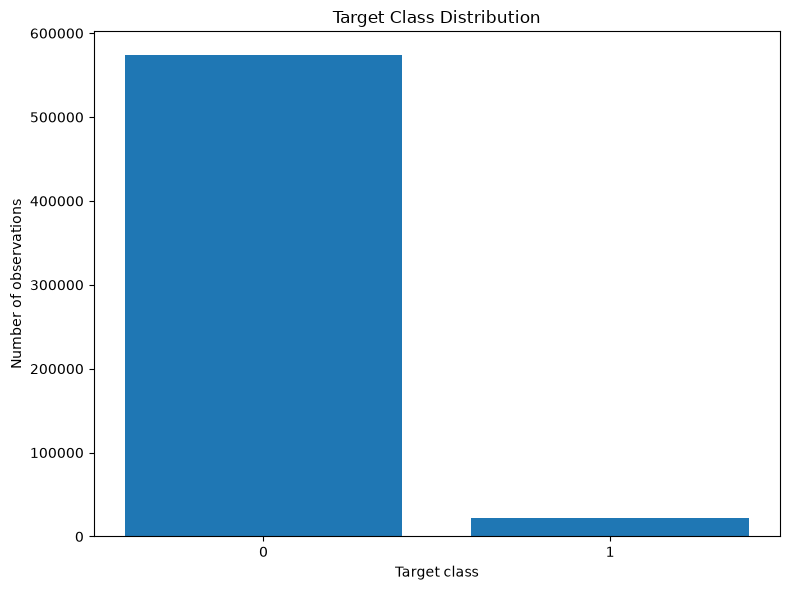

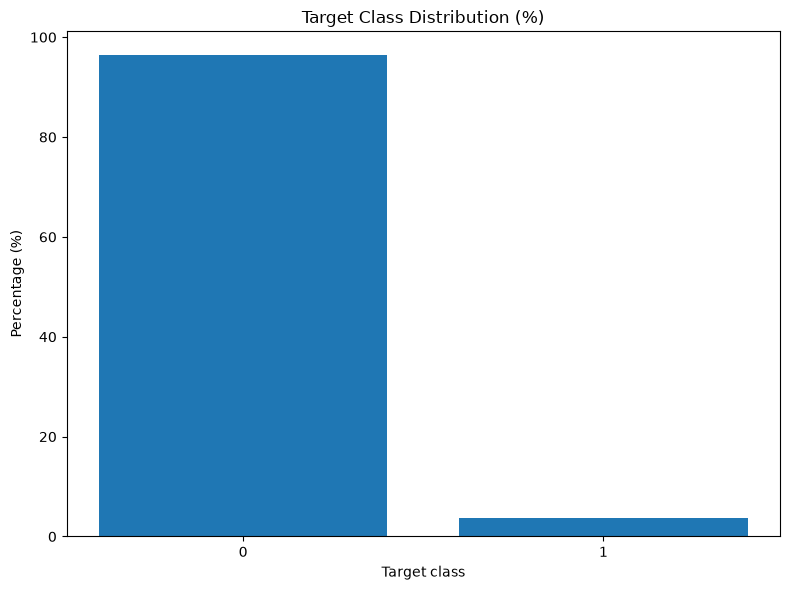


Variables containing missing values:


,Missing_Count,Missing_Percentage
ps_car_03_cat,411231,69.089837
ps_car_05_cat,266551,44.782531
ps_reg_03,107772,18.106490
ps_car_14,42620,7.160474
ps_car_07_cat,11489,1.930237
ps_ind_05_cat,5809,0.975955
ps_car_09_cat,569,0.095596
ps_ind_02_cat,216,0.036290
ps_car_01_cat,107,0.017977
ps_ind_04_cat,83,0.013945


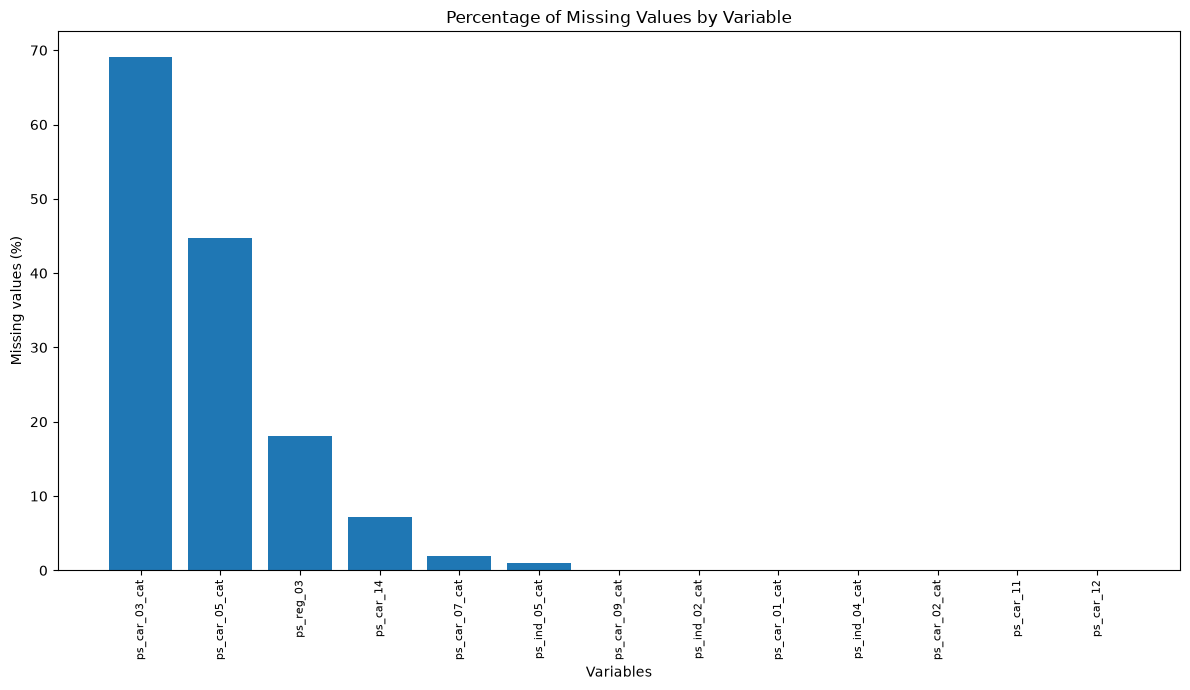


Number of numerical variables: 26
Numerical distributions saved.
Boxplots saved.
Number of categorical variables: 31
Categorical distributions saved.

Creating correlation matrix...
Correlation matrix created.


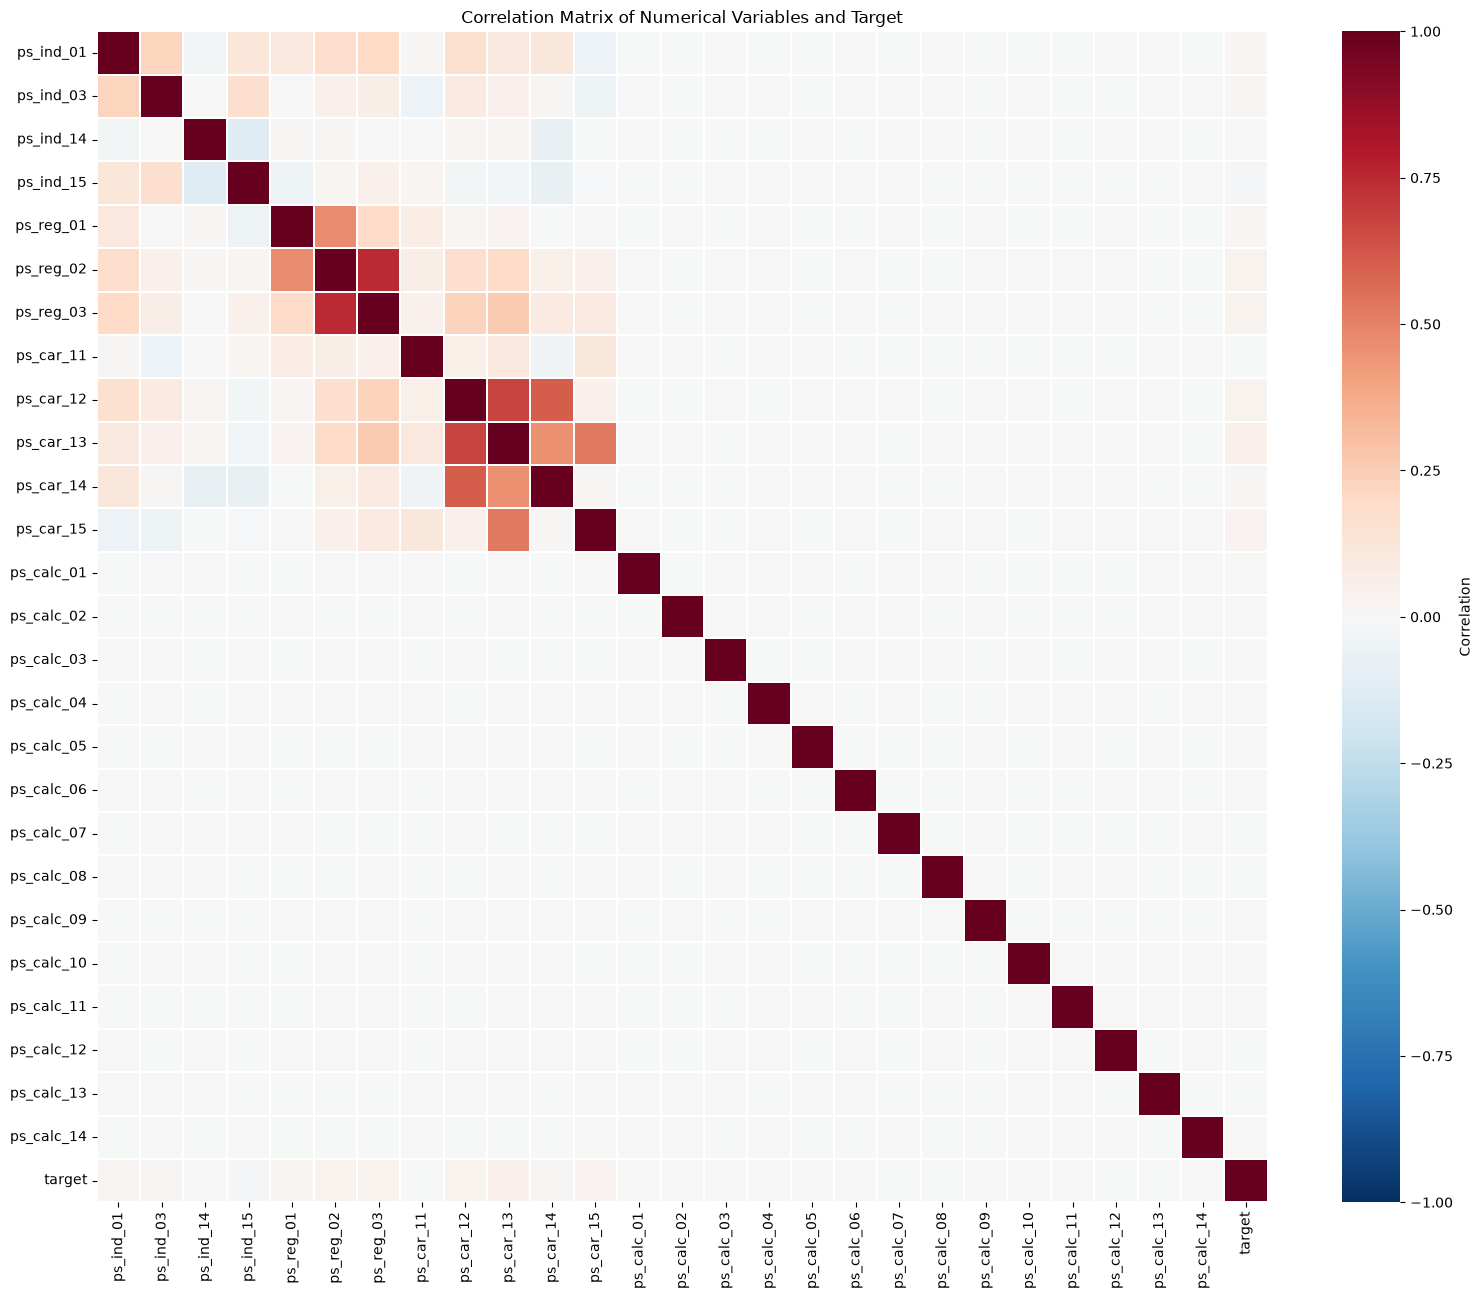


Top 10 numerical variables associated with target:
ps_car_13    0.053899
ps_car_12    0.038800
ps_reg_02    0.034800
ps_reg_03    0.033758
ps_car_15    0.027667
ps_reg_01    0.022888
ps_ind_15    0.021506
ps_ind_01    0.018570
ps_car_14    0.011674
ps_ind_03    0.008360
Name: target, dtype: float64


<Figure size 800x500 with 0 Axes>

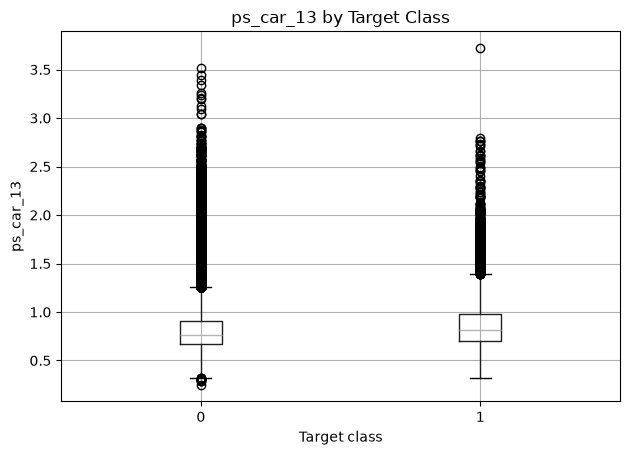

<Figure size 800x500 with 0 Axes>

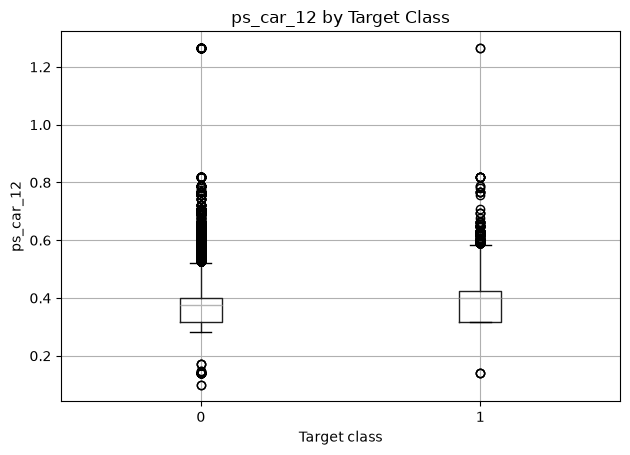

<Figure size 800x500 with 0 Axes>

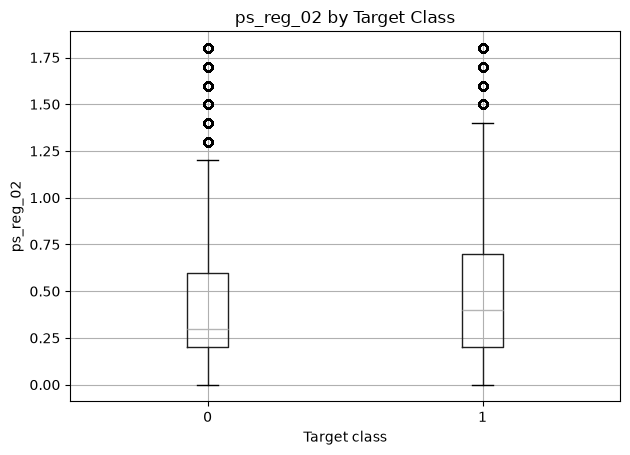

<Figure size 800x500 with 0 Axes>

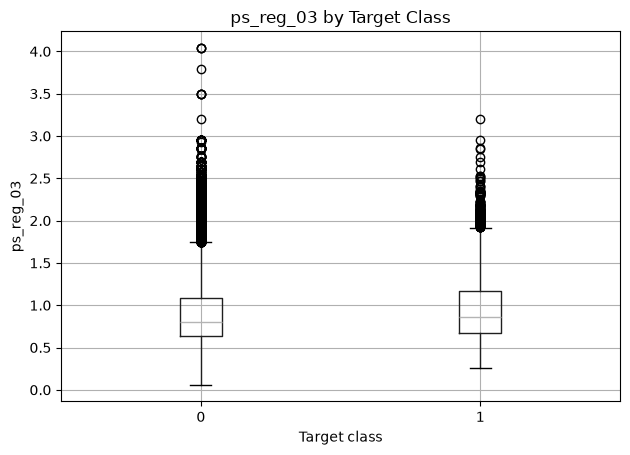

<Figure size 800x500 with 0 Axes>

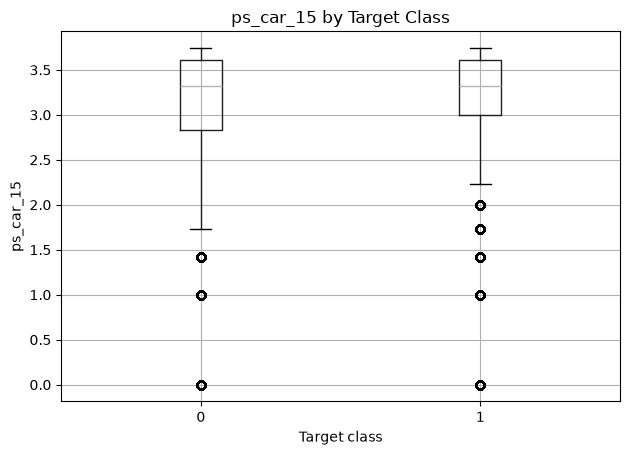

<Figure size 800x500 with 0 Axes>

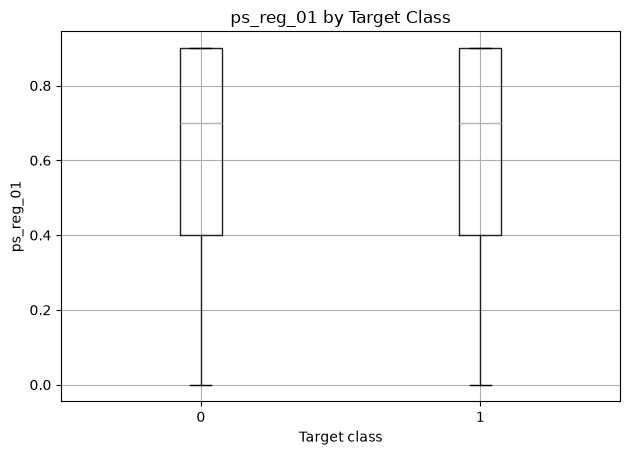

<Figure size 800x500 with 0 Axes>

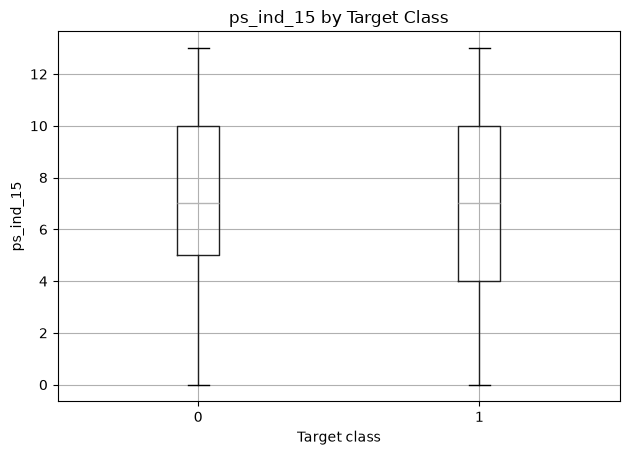

<Figure size 800x500 with 0 Axes>

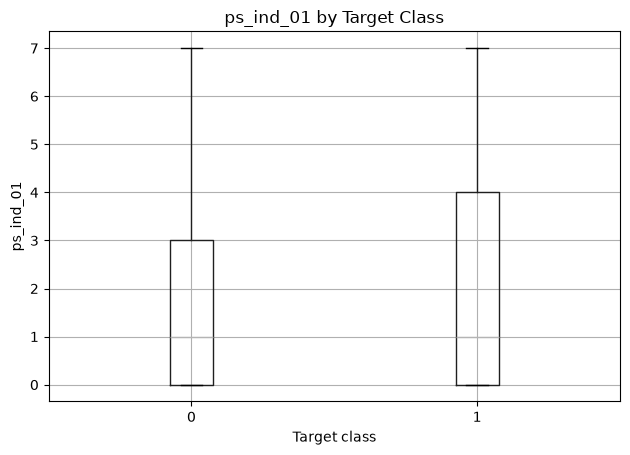

<Figure size 800x500 with 0 Axes>

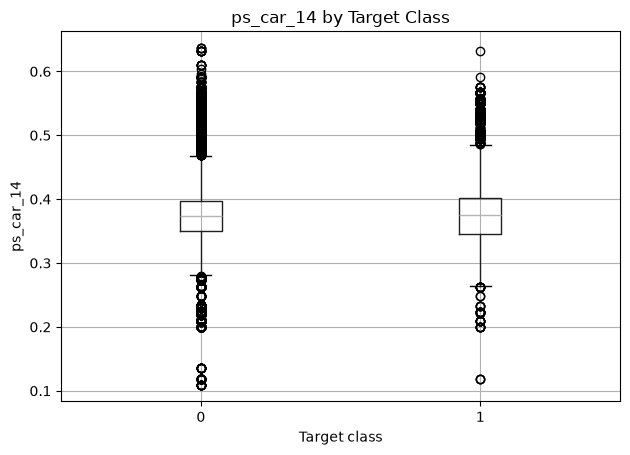

<Figure size 800x500 with 0 Axes>

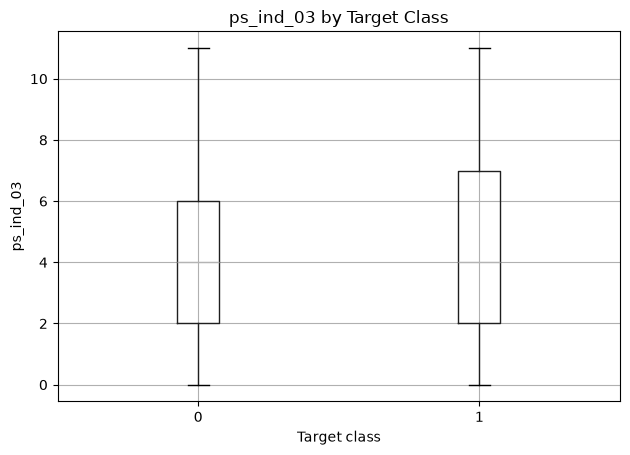

Target comparison plots saved.

EDA COMPLETED

All EDA results have been saved in:
c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\EDA_OpenML_42742


In [8]:
# ============================================================
# 3. EXPLORATORY DATA ANALYSIS
#    All figures and summary tables are automatically saved
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import pandas as pd


# ============================================================
# Create output directory
# ============================================================

eda_dir = "EDA_OpenML_42742"
os.makedirs(eda_dir, exist_ok=True)

print("=" * 70)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 70)


# ============================================================
# 3.1 Target distribution
# ============================================================

target_counts = (
    df["target"]
    .value_counts(dropna=False)
    .sort_index()
)

target_table = target_counts.to_frame(name="Count")

target_table["Percentage"] = (
    target_table["Count"] / len(df) * 100
)

print("\nTarget distribution:")
display(target_table)


plt.figure(figsize=(8, 6))

plt.bar(
    target_counts.index.astype(str),
    target_counts.values
)

plt.xlabel("Target class")
plt.ylabel("Number of observations")
plt.title("Target Class Distribution")

plt.tight_layout()

plt.savefig(
    os.path.join(
        eda_dir,
        "01_target_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 3.2 Target distribution in percentage
# ============================================================

plt.figure(figsize=(8, 6))

target_percentage = (
    df["target"]
    .value_counts(normalize=True, dropna=False)
    .sort_index() * 100
)

plt.bar(
    target_percentage.index.astype(str),
    target_percentage.values
)

plt.xlabel("Target class")
plt.ylabel("Percentage (%)")
plt.title("Target Class Distribution (%)")

plt.tight_layout()

plt.savefig(
    os.path.join(
        eda_dir,
        "02_target_percentage.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 3.3 Missing values
# ============================================================

missing_count = df.isna().sum()

missing_percentage = (
    df.isna().mean() * 100
)

missing_table = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percentage
})

missing_table = (
    missing_table[
        missing_table["Missing_Count"] > 0
    ]
    .sort_values(
        by="Missing_Count",
        ascending=False
    )
)

print("\nVariables containing missing values:")
display(missing_table)


# Plot only variables containing missing values

plt.figure(figsize=(12, 7))

plt.bar(
    missing_table.index,
    missing_table["Missing_Percentage"]
)

plt.xlabel("Variables")
plt.ylabel("Missing values (%)")
plt.title("Percentage of Missing Values by Variable")

plt.xticks(
    rotation=90,
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        eda_dir,
        "03_missing_values.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 3.4 Distribution of numerical variables
# ============================================================

numeric_columns = df.select_dtypes(
    include=["number"]
).columns.tolist()

# Remove target if it is represented as numerical
numeric_features = [
    col for col in numeric_columns
    if col != "target"
]

print(
    f"\nNumber of numerical variables: "
    f"{len(numeric_features)}"
)


# Save one histogram per numerical variable

for i, column in enumerate(
    numeric_features,
    start=1
):

    plt.figure(figsize=(8, 5))

    plt.hist(
        df[column].dropna(),
        bins=30
    )

    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(
        f"Distribution of {column}"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            eda_dir,
            f"04_numeric_distribution_{i:02d}_{column}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

print("Numerical distributions saved.")


# ============================================================
# 3.5 Boxplots for numerical variables
# ============================================================

for i, column in enumerate(
    numeric_features,
    start=1
):

    plt.figure(figsize=(8, 5))

    plt.boxplot(
        df[column].dropna()
    )

    plt.ylabel(column)
    plt.title(
        f"Boxplot of {column}"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            eda_dir,
            f"05_boxplot_{i:02d}_{column}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

print("Boxplots saved.")
# ------------------------------------------------------------
# 3.6 Categorical variable distributions
# ------------------------------------------------------------

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

categorical_features = [
    col for col in categorical_columns
    if col != "target"
]

print(f"Number of categorical variables: {len(categorical_features)}")


# Save distributions for categorical variables
for i, column in enumerate(categorical_features, start=1):

    # Convert temporarily to string so that both
    # categorical values and missing values can be handled safely
    series = df[column].astype("object")

    # Replace missing values after converting to object
    series = series.where(series.notna(), "Missing")

    # Convert everything to string for plotting
    series = series.astype(str)

    value_counts = (
        series
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(9, 5))

    plt.bar(
        value_counts.index.tolist(),
        value_counts.values
    )

    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(
        f"Distribution of {column} (Top 15 categories)"
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            eda_dir,
            f"06_categorical_distribution_{i:02d}_{column}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

print("Categorical distributions saved.")
# ------------------------------------------------------------
# 3.7 Correlation matrix
# ------------------------------------------------------------

print("\nCreating correlation matrix...")

# Create a temporary numerical version of the target
# WITHOUT modifying the original dataset
target_numeric = df["target"].astype(int)

# Numerical variables + temporary numerical target
correlation_data = df[numeric_features].copy()
correlation_data["target"] = target_numeric

# Calculate correlations
correlation_matrix = correlation_data.corr()

print("Correlation matrix created.")

# ------------------------------------------------------------
# Plot correlation matrix
# ------------------------------------------------------------

plt.figure(figsize=(16, 13))

sns.heatmap(
    correlation_matrix,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.2,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Matrix of Numerical Variables and Target")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    os.path.join(
        eda_dir,
        "07_correlation_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ------------------------------------------------------------
# 3.8 Numerical variables vs target
# ------------------------------------------------------------

# Calculate absolute correlations with target
target_correlations = (
    correlation_matrix["target"]
    .drop("target")
    .abs()
    .sort_values(ascending=False)
)

# Select the 10 numerical variables most strongly
# associated with the target
top_numeric_features = (
    target_correlations
    .head(10)
    .index
    .tolist()
)

print("\nTop 10 numerical variables associated with target:")
print(target_correlations.head(10))


# ------------------------------------------------------------
# Boxplots for top numerical variables
# ------------------------------------------------------------

for i, column in enumerate(top_numeric_features, start=1):

    plt.figure(figsize=(8, 5))

    # Create boxplot manually to avoid pandas plotting issues
    df.boxplot(
        column=column,
        by="target"
    )

    plt.title(
        f"{column} by Target Class"
    )

    plt.suptitle("")

    plt.xlabel("Target class")
    plt.ylabel(column)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            eda_dir,
            f"08_target_comparison_{i:02d}_{column}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

print("Target comparison plots saved.")


# ============================================================
# 3.9 Descriptive statistics
# ============================================================

descriptive_statistics = (
    df.describe(
        include="all"
    ).T
)

descriptive_statistics.to_csv(
    os.path.join(
        eda_dir,
        "descriptive_statistics.csv"
    )
)


# ============================================================
# 3.10 Save EDA summary tables
# ============================================================

missing_table.to_csv(
    os.path.join(
        eda_dir,
        "missing_values_summary.csv"
    ),
    index=True
)

target_table.to_csv(
    os.path.join(
        eda_dir,
        "target_distribution.csv"
    ),
    index=True
)


# ============================================================
# EDA COMPLETED
# ============================================================

print("\n" + "=" * 70)
print("EDA COMPLETED")
print("=" * 70)

print(
    "\nAll EDA results have been saved in:"
)

print(
    os.path.abspath(eda_dir)
)

In [ ]:
#Logistic Regression

LOGISTIC REGRESSION BASELINE

Processed training shape: (476169, 235)
Training target shape: (476169,)

Same 3 saved CV folds loaded successfully.

Baseline parameters:
C: 1.0
penalty: l2
solver: saga
class_weight: None
max_iter: 3000
random_state: 42
n_jobs: -1


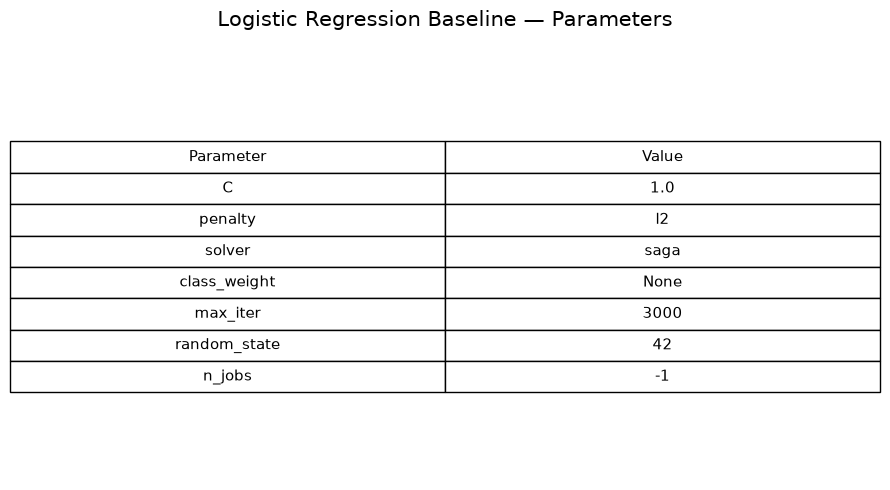


STARTING 3-FOLD CROSS-VALIDATION

Fold 1/3


c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


ROC-AUC           : 0.626756
Gini              : 0.253512
Average Precision : 0.062233

Fold 2/3


c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [ ]:
# ============================================================
# LOGISTIC REGRESSION BASELINE
# OpenML 42742
#
# Purpose:
# Establish a simple linear baseline before XGBoost and SVM.
#
# Main comparison metric:
# ROC-AUC / Gini
#
# Complementary metric:
# Average Precision
#
# IMPORTANT:
# - Same processed training data as other models
# - Same saved 3 CV folds
# - Test set is NOT used for model selection/evaluation here
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import json
import pickle
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


# ============================================================
# 1. OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = "Logistic_Regression_Baseline"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("=" * 80)
print("LOGISTIC REGRESSION BASELINE")
print("=" * 80)


# ============================================================
# 2. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "X_train_processed",
    "y_train"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:

    raise NameError(
        "Missing required variables: "
        + ", ".join(missing_variables)
        + "\nRun the common preprocessing section first."
    )


y_train_array = (
    np.asarray(y_train)
    .astype(int)
)


print(
    "\nProcessed training shape:",
    X_train_processed.shape
)

print(
    "Training target shape:",
    y_train_array.shape
)


# ============================================================
# 3. LOAD THE SAME 3 SAVED CV FOLDS
# ============================================================
#
# This keeps the validation protocol consistent with XGBoost
# and SVM.
# ============================================================

candidate_directories = [
    "XGBoost_RandomizedSearch_OpenML_42742",
    "XGBoost_RandomizedSearch"
]

folds_path = None


for directory in candidate_directories:

    candidate = os.path.join(
        directory,
        "cv_folds.pkl"
    )

    if os.path.exists(candidate):

        folds_path = candidate
        break


if folds_path is None:

    raise FileNotFoundError(
        "cv_folds.pkl could not be found."
    )


with open(
    folds_path,
    "rb"
) as f:

    cv_splits = pickle.load(f)


if len(cv_splits) != 3:

    raise ValueError(
        f"Expected 3 saved folds, found {len(cv_splits)}."
    )


print(
    "\nSame 3 saved CV folds loaded successfully."
)


# ============================================================
# 4. DEFINE BASELINE PARAMETERS
# ============================================================
#
# No tuning is performed here.
#
# L2 regularization is the standard baseline choice.
#
# C = 1.0 corresponds to the standard regularization strength.
#
# class_weight=None:
# no explicit imbalance correction in the baseline.
# ============================================================

baseline_params = {

    "C": 1.0,

    "penalty": "l2",

    "solver": "saga",

    "class_weight": None,

    "max_iter": 3000,

    "random_state": 42,

    "n_jobs": -1
}


print("\nBaseline parameters:")

for parameter, value in baseline_params.items():

    print(
        f"{parameter}: {value}"
    )


# ============================================================
# 5. SAVE PARAMETERS AS JSON
# ============================================================

with open(

    os.path.join(
        OUTPUT_DIR,
        "01_logistic_regression_parameters.json"
    ),

    "w"

) as f:

    json.dump(
        baseline_params,
        f,
        indent=4
    )


# ============================================================
# 6. SAVE PARAMETERS AS IMAGE
# ============================================================

parameter_table = pd.DataFrame({

    "Parameter":
        list(
            baseline_params.keys()
        ),

    "Value":
        [
            str(value)
            for value
            in baseline_params.values()
        ]
})


fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.axis("off")


table = ax.table(

    cellText=
        parameter_table.values,

    colLabels=
        parameter_table.columns,

    cellLoc="center",

    loc="center"
)


table.auto_set_font_size(
    False
)

table.set_fontsize(
    11
)

table.scale(
    1,
    1.7
)


ax.set_title(
    "Logistic Regression Baseline — Parameters",
    fontsize=15,
    pad=20
)


plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "01_logistic_regression_parameters.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.show()
plt.close()


# ============================================================
# 7. PREPARE OOF STORAGE
# ============================================================

oof_probability = np.zeros(
    len(y_train_array),
    dtype=float
)


fold_results = []

fit_counter = 0


# ============================================================
# 8. 3-FOLD CROSS-VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("STARTING 3-FOLD CROSS-VALIDATION")
print("=" * 80)


for fold_number, (
    train_idx,
    valid_idx
) in enumerate(
    cv_splits,
    start=1
):

    fit_counter += 1


    print(
        f"\nFold {fold_number}/3"
    )


    X_fold_train = (
        X_train_processed[
            train_idx
        ]
    )

    X_fold_valid = (
        X_train_processed[
            valid_idx
        ]
    )


    y_fold_train = (
        y_train_array[
            train_idx
        ]
    )

    y_fold_valid = (
        y_train_array[
            valid_idx
        ]
    )


    # --------------------------------------------------------
    # Logistic Regression
    # --------------------------------------------------------

    model = LogisticRegression(
        **baseline_params
    )


    model.fit(
        X_fold_train,
        y_fold_train
    )


    # --------------------------------------------------------
    # Validation probabilities
    # --------------------------------------------------------

    valid_probability = (

        model
        .predict_proba(
            X_fold_valid
        )

        [:, 1]
    )


    oof_probability[
        valid_idx
    ] = valid_probability


    # --------------------------------------------------------
    # Fold metrics
    # --------------------------------------------------------

    auc = roc_auc_score(
        y_fold_valid,
        valid_probability
    )


    gini = (
        2 * auc - 1
    )


    ap = average_precision_score(
        y_fold_valid,
        valid_probability
    )


    fold_results.append({

        "Fold":
            fold_number,

        "ROC_AUC":
            auc,

        "Gini":
            gini,

        "Average_Precision":
            ap
    })


    print(
        f"ROC-AUC           : {auc:.6f}"
    )

    print(
        f"Gini              : {gini:.6f}"
    )

    print(
        f"Average Precision : {ap:.6f}"
    )


    # --------------------------------------------------------
    # Save fold model
    # --------------------------------------------------------

    joblib.dump(

        model,

        os.path.join(
            OUTPUT_DIR,
            f"logistic_regression_fold_{fold_number}.joblib"
        )
    )


# ============================================================
# 9. FOLD RESULTS
# ============================================================

fold_results_df = pd.DataFrame(
    fold_results
)


mean_auc = (
    fold_results_df[
        "ROC_AUC"
    ]
    .mean()
)

std_auc = (
    fold_results_df[
        "ROC_AUC"
    ]
    .std(ddof=0)
)


mean_gini = (
    fold_results_df[
        "Gini"
    ]
    .mean()
)

std_gini = (
    fold_results_df[
        "Gini"
    ]
    .std(ddof=0)
)


mean_ap = (
    fold_results_df[
        "Average_Precision"
    ]
    .mean()
)

std_ap = (
    fold_results_df[
        "Average_Precision"
    ]
    .std(ddof=0)
)


# ============================================================
# 10. GLOBAL OOF METRICS
# ============================================================

oof_auc = roc_auc_score(
    y_train_array,
    oof_probability
)


oof_gini = (
    2 * oof_auc - 1
)


oof_ap = average_precision_score(
    y_train_array,
    oof_probability
)


# Default classification threshold
oof_prediction = (
    oof_probability >= 0.5
).astype(int)


oof_precision = precision_score(
    y_train_array,
    oof_prediction,
    zero_division=0
)


oof_recall = recall_score(
    y_train_array,
    oof_prediction,
    zero_division=0
)


oof_f1 = f1_score(
    y_train_array,
    oof_prediction,
    zero_division=0
)


print("\n" + "=" * 80)
print("LOGISTIC REGRESSION BASELINE RESULTS")
print("=" * 80)


print(
    f"\nCV ROC-AUC : "
    f"{mean_auc:.6f} ± {std_auc:.6f}"
)

print(
    f"CV Gini    : "
    f"{mean_gini:.6f} ± {std_gini:.6f}"
)

print(
    f"CV AP      : "
    f"{mean_ap:.6f} ± {std_ap:.6f}"
)


print(
    f"\nGlobal OOF ROC-AUC : "
    f"{oof_auc:.6f}"
)

print(
    f"Global OOF Gini    : "
    f"{oof_gini:.6f}"
)

print(
    f"Global OOF AP      : "
    f"{oof_ap:.6f}"
)


# ============================================================
# 11. SAVE SUMMARY TABLE
# ============================================================

summary_df = pd.DataFrame({

    "Metric": [

        "CV ROC-AUC",
        "CV Gini",
        "CV Average Precision",

        "OOF ROC-AUC",
        "OOF Gini",
        "OOF Average Precision",

        "OOF Precision (threshold 0.5)",
        "OOF Recall (threshold 0.5)",
        "OOF F1 (threshold 0.5)"
    ],

    "Mean / Value": [

        mean_auc,
        mean_gini,
        mean_ap,

        oof_auc,
        oof_gini,
        oof_ap,

        oof_precision,
        oof_recall,
        oof_f1
    ],

    "CV Std": [

        std_auc,
        std_gini,
        std_ap,

        np.nan,
        np.nan,
        np.nan,

        np.nan,
        np.nan,
        np.nan
    ]
})


summary_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "02_logistic_regression_metrics.csv"
    ),

    index=False
)


# ============================================================
# 12. SAVE METRIC TABLE AS IMAGE
# ============================================================

display_summary = (
    summary_df
    .copy()
)


display_summary[
    "Mean / Value"
] = (
    display_summary[
        "Mean / Value"
    ]
    .round(6)
)


display_summary[
    "CV Std"
] = (
    display_summary[
        "CV Std"
    ]
    .round(6)
)


fig, ax = plt.subplots(
    figsize=(12, 7)
)

ax.axis("off")


table = ax.table(

    cellText=
        display_summary
        .fillna("-")
        .values,

    colLabels=
        display_summary
        .columns,

    cellLoc="center",

    loc="center"
)


table.auto_set_font_size(
    False
)

table.set_fontsize(
    10
)

table.scale(
    1,
    1.6
)


ax.set_title(
    "Logistic Regression Baseline — "
    "Cross-Validation and OOF Performance",
    fontsize=16,
    pad=20
)


plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "02_logistic_regression_metrics.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.show()
plt.close()


# ============================================================
# 13. SAVE OOF PREDICTIONS
# ============================================================

oof_df = pd.DataFrame({

    "y_true":
        y_train_array,

    "predicted_probability":
        oof_probability,

    "predicted_class_0_5":
        oof_prediction
})


oof_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "03_logistic_regression_OOF_predictions.csv"
    ),

    index=False
)


# ============================================================
# 14. ROC CURVE
# ============================================================

fpr, tpr, _ = roc_curve(
    y_train_array,
    oof_probability
)


plt.figure(
    figsize=(9, 6)
)


plt.plot(

    fpr,

    tpr,

    label=(
        f"Logistic Regression "
        f"(AUC={oof_auc:.4f}, "
        f"Gini={oof_gini:.4f})"
    )
)


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Logistic Regression Baseline — OOF ROC Curve"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "04_logistic_regression_ROC_curve.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.show()
plt.close()


# ============================================================
# 15. PRECISION-RECALL CURVE
# ============================================================

precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y_train_array,
        oof_probability
    )
)


plt.figure(
    figsize=(9, 6)
)


plt.plot(

    recall_curve,

    precision_curve,

    label=(
        f"Logistic Regression "
        f"(AP={oof_ap:.4f})"
    )
)


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Logistic Regression Baseline — "
    "OOF Precision-Recall Curve"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "05_logistic_regression_precision_recall_curve.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.show()
plt.close()


# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_train_array,
    oof_prediction
)


fig, ax = plt.subplots(
    figsize=(7, 6)
)


image = ax.imshow(
    cm
)


for i in range(
    cm.shape[0]
):

    for j in range(
        cm.shape[1]
    ):

        ax.text(

            j,

            i,

            f"{cm[i, j]:,}",

            ha="center",

            va="center"
        )


ax.set_xticks(
    [0, 1]
)

ax.set_yticks(
    [0, 1]
)


ax.set_xlabel(
    "Predicted class"
)

ax.set_ylabel(
    "True class"
)


ax.set_title(
    "Logistic Regression Baseline — "
    "OOF Confusion Matrix"
)


plt.colorbar(
    image,
    ax=ax
)


plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "06_logistic_regression_confusion_matrix.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.show()
plt.close()


# ============================================================
# 17. PREDICTED PROBABILITY DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.hist(

    oof_probability[
        y_train_array == 0
    ],

    bins=50,

    alpha=0.6,

    label="Actual class 0"
)


plt.hist(

    oof_probability[
        y_train_array == 1
    ],

    bins=50,

    alpha=0.6,

    label="Actual class 1"
)


plt.xlabel(
    "Predicted probability of class 1"
)

plt.ylabel(
    "Number of observations"
)

plt.title(
    "Logistic Regression Baseline — "
    "OOF Predicted Probability Distribution"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "07_logistic_regression_probability_distribution.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.show()
plt.close()


# ============================================================
# 18. CLASSIFICATION REPORT
# ============================================================

report = classification_report(

    y_train_array,

    oof_prediction,

    output_dict=True,

    zero_division=0
)


report_df = (
    pd.DataFrame(report)
    .transpose()
)


report_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "08_logistic_regression_classification_report.csv"
    )
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.axis("off")


report_display = (
    report_df
    .round(4)
)


table = ax.table(

    cellText=
        report_display.values,

    colLabels=
        report_display.columns,

    rowLabels=
        report_display.index,

    cellLoc="center",

    loc="center"
)


table.auto_set_font_size(
    False
)

table.set_fontsize(
    9
)

table.scale(
    1,
    1.5
)


ax.set_title(
    "Logistic Regression Baseline — "
    "OOF Classification Report",
    fontsize=15,
    pad=20
)


plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "08_logistic_regression_classification_report.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.show()
plt.close()


# ============================================================
# 19. TRAIN FINAL BASELINE LR ON FULL TRAINING DATA
# ============================================================
#
# The model is trained and saved for later final comparison.
#
# The test set is STILL NOT evaluated here.
# ============================================================

final_logistic_model = LogisticRegression(
    **baseline_params
)


print(
    "\nTraining final Logistic Regression "
    "on the complete training set..."
)


final_logistic_model.fit(
    X_train_processed,
    y_train_array
)


joblib.dump(

    final_logistic_model,

    os.path.join(
        OUTPUT_DIR,
        "09_logistic_regression_final_model.joblib"
    )
)


# ============================================================
# 20. FEATURE COEFFICIENTS
# ============================================================
#
# Positive coefficient:
# pushes prediction toward target = 1
#
# Negative coefficient:
# pushes prediction toward target = 0
# ============================================================

try:

    feature_names = (
        preprocessor
        .get_feature_names_out()
    )

except Exception:

    feature_names = [
        f"Feature_{i}"
        for i in range(
            X_train_processed.shape[1]
        )
    ]


coefficients = (
    final_logistic_model
    .coef_[0]
)


coefficient_df = pd.DataFrame({

    "Feature":
        feature_names,

    "Coefficient":
        coefficients,

    "Absolute_Coefficient":
        np.abs(
            coefficients
        )
})


coefficient_df = (
    coefficient_df

    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


coefficient_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "10_logistic_regression_all_coefficients.csv"
    ),

    index=False
)


# ============================================================
# 21. TOP 20 ABSOLUTE COEFFICIENTS
# ============================================================

top20_coefficients = (
    coefficient_df
    .head(20)
    .sort_values(
        "Absolute_Coefficient",
        ascending=True
    )
)


plt.figure(
    figsize=(10, 8)
)


plt.barh(

    top20_coefficients[
        "Feature"
    ],

    top20_coefficients[
        "Coefficient"
    ]
)


plt.xlabel(
    "Logistic Regression Coefficient"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Logistic Regression Baseline — "
    "Top 20 Coefficients by Absolute Magnitude"
)

plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "10_logistic_regression_top20_coefficients.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.show()
plt.close()


# ============================================================
# 22. EXPERIMENT SUMMARY
# ============================================================

experiment_summary = {

    "model":
        "LogisticRegression",

    "role":
        "Baseline",

    "main_comparison_metric":
        "ROC-AUC",

    "secondary_metrics": [
        "Gini",
        "Average Precision"
    ],

    "number_of_cv_folds":
        3,

    "same_cv_folds_as_xgboost_and_svm":
        True,

    "cv_roc_auc_mean":
        float(mean_auc),

    "cv_roc_auc_std":
        float(std_auc),

    "cv_gini_mean":
        float(mean_gini),

    "cv_average_precision_mean":
        float(mean_ap),

    "global_oof_roc_auc":
        float(oof_auc),

    "global_oof_gini":
        float(oof_gini),

    "global_oof_average_precision":
        float(oof_ap),

    "test_set_used":
        False
}


with open(

    os.path.join(
        OUTPUT_DIR,
        "11_logistic_regression_summary.json"
    ),

    "w"
) as f:

    json.dump(
        experiment_summary,
        f,
        indent=4
    )


# ============================================================
# 23. FINAL MESSAGE
# ============================================================

print("\n" + "=" * 80)
print("LOGISTIC REGRESSION BASELINE COMPLETED")
print("=" * 80)


print(
    f"\nCV ROC-AUC : "
    f"{mean_auc:.6f} ± {std_auc:.6f}"
)

print(
    f"CV Gini    : "
    f"{mean_gini:.6f} ± {std_gini:.6f}"
)

print(
    f"CV AP      : "
    f"{mean_ap:.6f} ± {std_ap:.6f}"
)


print(
    "\n✓ Same 3 CV folds as XGBoost and SVM"
)

print(
    "✓ ROC-AUC / Gini calculated"
)

print(
    "✓ Average Precision calculated"
)

print(
    "✓ OOF predictions saved"
)

print(
    "✓ ROC curve saved"
)

print(
    "✓ Precision-Recall curve saved"
)

print(
    "✓ Confusion matrix saved"
)

print(
    "✓ Probability distribution saved"
)

print(
    "✓ Classification report saved"
)

print(
    "✓ Top coefficients saved"
)

print(
    "✓ Final LR model saved as JOBLIB"
)

print(
    "✓ Test set NOT used"
)

print(
    f"\nResults saved in:\n"
    f"{os.path.abspath(OUTPUT_DIR)}"
)

XGBOOST BASELINE - OPENML 42742

Dataset shape:
(595212, 58)

Target distribution:
target
0    573518
1     21694
Name: count, dtype: int64

Target distribution (%):
target
0    96.355
1     3.645
Name: proportion, dtype: float64

Number of observations: 595212
Number of predictors : 57

Train set: (476169, 57)
Test set : (119043, 57)

Positive class proportion:
Train: 3.6447%
Test : 3.6449%

Number of numerical variables: 26
Number of categorical variables: 31

Categorical variables:
['ps_ind_02_cat', 'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_ind_06_bin', 'ps_ind_07_bin', 'ps_ind_08_bin', 'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin', 'ps_ind_12_bin', 'ps_ind_13_bin', 'ps_ind_16_bin', 'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat', 'ps_car_11_cat', 'ps_calc_15_bin', 'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin', 'ps_calc_19_

<Figure size 700x600 with 0 Axes>

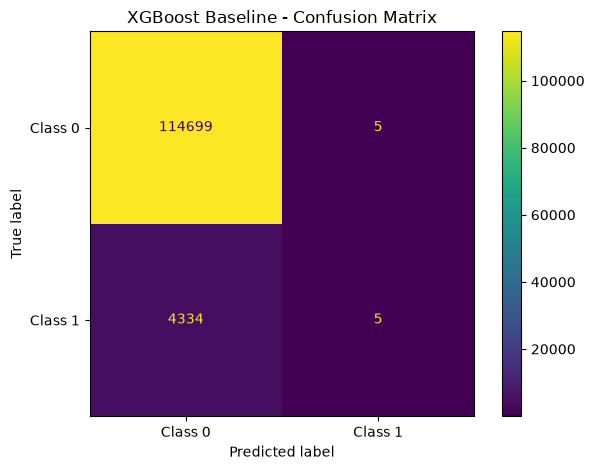

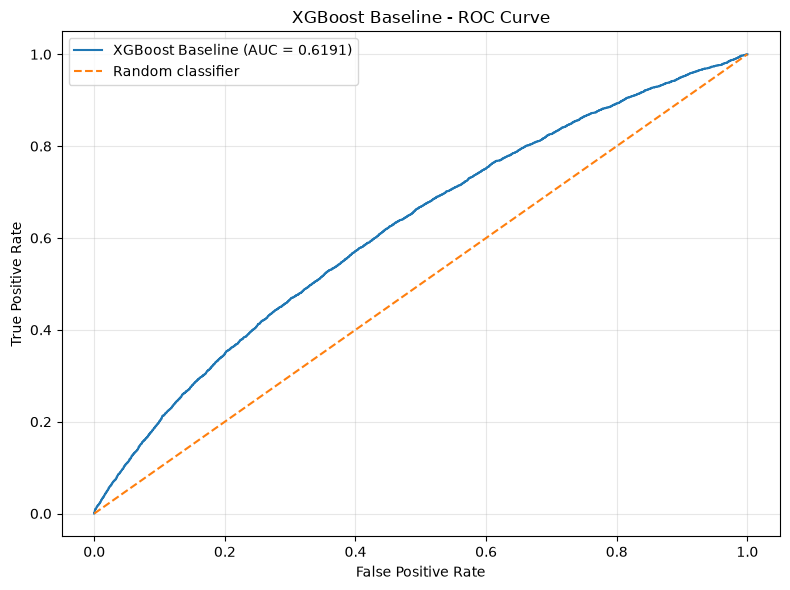

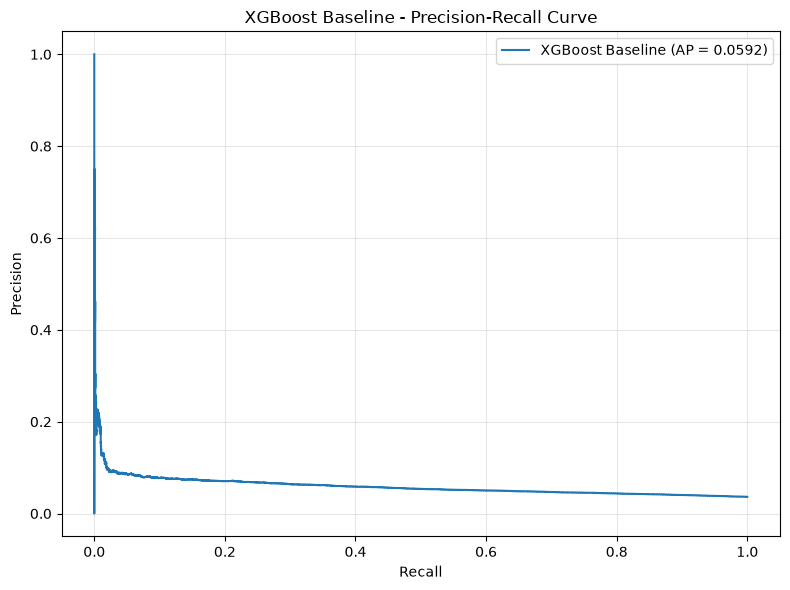

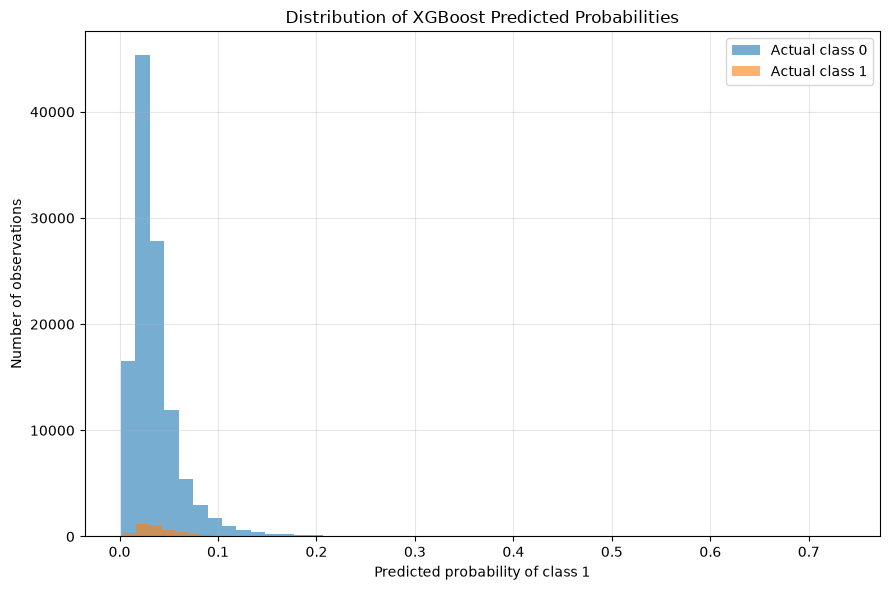

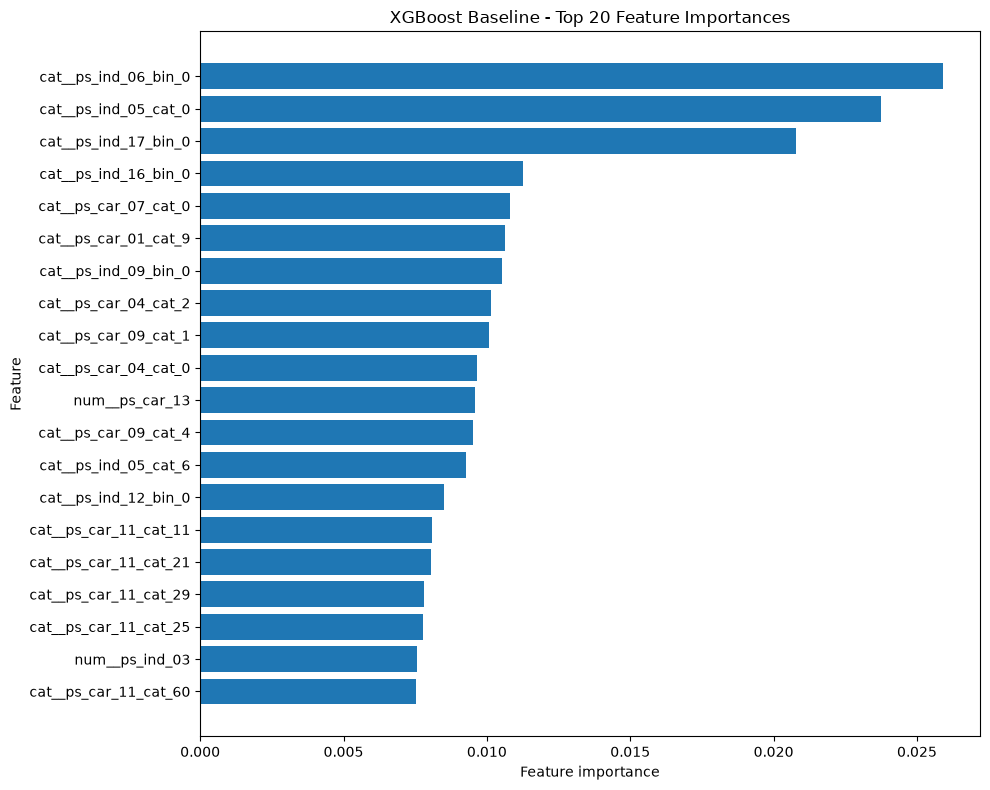


XGBOOST BASELINE COMPLETED

Main results:
Average Precision : 0.059198
ROC-AUC           : 0.619128
Precision         : 0.500000
Recall            : 0.001152
F1-score          : 0.002299

Saved files:
 - 01_confusion_matrix.png
 - 02_roc_curve.png
 - 03_precision_recall_curve.png
 - 04_predicted_probability_distribution.png
 - 05_top20_feature_importance.png
 - baseline_parameters.json
 - baseline_performance.csv
 - baseline_results.csv
 - classification_report.csv
 - confusion_matrix.csv
 - dataset_split_information.csv
 - feature_importance_all.csv
 - precision_recall_curve_data.csv
 - preprocessing_information.json
 - roc_curve_data.csv
 - test_predictions.csv
 - top20_feature_importance.csv

Output directory:
c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\XGBoost_Baseline_OpenML_42742



In [9]:
# ============================================================
# XGBOOST BASELINE - OPENML 42742
# COMPLETE VERSION WITH RESULTS AND FIGURES
# ============================================================
#
# This baseline is intentionally performed BEFORE:
# - hyperparameter tuning
# - class weighting
# - RandomizedSearchCV
# - GridSearchCV
#
# The purpose is to establish a reference performance.
#
# All important numerical results, predictions, model
# parameters and figures are automatically saved.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier


# ============================================================
# 1. CREATE OUTPUT DIRECTORY
# ============================================================

output_dir = "XGBoost_Baseline_OpenML_42742"

os.makedirs(
    output_dir,
    exist_ok=True
)

print("=" * 70)
print("XGBOOST BASELINE - OPENML 42742")
print("=" * 70)


# ============================================================
# 2. BASIC DATA CHECK
# ============================================================

print("\nDataset shape:")
print(df.shape)

print("\nTarget distribution:")
print(df["target"].value_counts())

print("\nTarget distribution (%):")
print(
    df["target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(3)
)


# ============================================================
# 3. DEFINE FEATURES AND TARGET
# ============================================================

X = df.drop(
    columns=["target"]
).copy()

y = df["target"].astype(int).copy()

print("\nNumber of observations:", len(X))
print("Number of predictors :", X.shape[1])



# ============================================================
# 4. TRAIN / TEST SPLIT
# ============================================================
#
# Stratification preserves the proportion of both classes.
#
# The test set remains completely untouched during training.
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain set:", X_train.shape)
print("Test set :", X_test.shape)

print("\nPositive class proportion:")
print(
    f"Train: {y_train.mean():.4%}"
)

print(
    f"Test : {y_test.mean():.4%}"
)




# ============================================================
# 5. IDENTIFY VARIABLE TYPES
# ============================================================

numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nNumber of numerical variables:",
      len(numeric_features))

print("Number of categorical variables:",
      len(categorical_features))

print("\nCategorical variables:")
print(categorical_features)


# ============================================================
# 6. PREPROCESSING
# ============================================================
#
# Numerical variables:
#   Missing values -> median
#
# Categorical variables:
#   Missing values -> most frequent category
#   Then -> One-Hot Encoding
#
# The preprocessing is fitted ONLY on X_train.
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)


# ============================================================
# 7. FIT PREPROCESSOR
# ============================================================

print("\nFitting preprocessing...")

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

print("Preprocessing completed.")

print(
    "\nProcessed training shape:",
    X_train_processed.shape
)

print(
    "Processed test shape    :",
    X_test_processed.shape
)


# ============================================================
# 8. XGBOOST BASELINE MODEL
# ============================================================
#
# IMPORTANT:
# No class weighting is used here.
#
# No hyperparameter tuning is performed here.
#
# These parameters represent a simple baseline.
# ============================================================

xgb_baseline = XGBClassifier(

    n_estimators=100,

    max_depth=6,

    learning_rate=0.3,

    subsample=1.0,

    colsample_bytree=1.0,

    min_child_weight=1,

    gamma=0,

    reg_alpha=0,

    reg_lambda=1,

    objective="binary:logistic",

    eval_metric="aucpr",

    tree_method="hist",

    random_state=42,

    n_jobs=-1
)


# ============================================================
# 9. SAVE MODEL PARAMETERS
# ============================================================

baseline_parameters = xgb_baseline.get_params()

with open(
    os.path.join(
        output_dir,
        "baseline_parameters.json"
    ),
    "w"
) as f:

    json.dump(
        baseline_parameters,
        f,
        indent=4,
        default=str
    )


# ============================================================
# 10. TRAIN MODEL
# ============================================================

print("\n" + "=" * 70)
print("TRAINING XGBOOST BASELINE")
print("=" * 70)

xgb_baseline.fit(
    X_train_processed,
    y_train
)

print("\nTraining completed.")


# ============================================================
# 11. PREDICTIONS
# ============================================================

# Probability of belonging to class 1
y_pred_proba = xgb_baseline.predict_proba(
    X_test_processed
)[:, 1]


# Classification using the default threshold of 0.5
y_pred = (
    y_pred_proba >= 0.5
).astype(int)


# ============================================================
# 12. CALCULATE PERFORMANCE METRICS
# ============================================================

average_precision = average_precision_score(
    y_test,
    y_pred_proba
)

roc_auc = roc_auc_score(
    y_test,
    y_pred_proba
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


# ============================================================
# 13. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 70)
print("XGBOOST BASELINE RESULTS")
print("=" * 70)

print(
    f"\nAverage Precision : {average_precision:.6f}"
)

print(
    f"ROC-AUC           : {roc_auc:.6f}"
)

print(
    f"Precision (0.5)   : {precision:.6f}"
)

print(
    f"Recall (0.5)      : {recall:.6f}"
)

print(
    f"F1-score (0.5)    : {f1:.6f}"
)


# ============================================================
# 14. SAVE PERFORMANCE TABLE
# ============================================================

baseline_results = pd.DataFrame({

    "Model": [
        "XGBoost Baseline"
    ],

    "Average_Precision": [
        average_precision
    ],

    "ROC_AUC": [
        roc_auc
    ],

    "Precision": [
        precision
    ],

    "Recall": [
        recall
    ],

    "F1": [
        f1
    ]
})


baseline_results.to_csv(
    os.path.join(
        output_dir,
        "baseline_performance.csv"
    ),
    index=False
)


# ============================================================
# 15. SAVE PREDICTIONS
# ============================================================
#
# This allows us to reuse the predictions later without
# retraining the model.
# ============================================================

predictions = pd.DataFrame({

    "y_true": y_test.to_numpy(),

    "predicted_probability": y_pred_proba,

    "predicted_class": y_pred
})


predictions.to_csv(
    os.path.join(
        output_dir,
        "test_predictions.csv"
    ),
    index=False
)


# ============================================================
# 16. CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    y_test,
    y_pred,
    digits=4,
    output_dict=True
)

classification_report_df = pd.DataFrame(
    report
).transpose()


classification_report_df.to_csv(
    os.path.join(
        output_dir,
        "classification_report.csv"
    )
)


print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)


# ============================================================
# 17. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)


cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual 0",
        "Actual 1"
    ],
    columns=[
        "Predicted 0",
        "Predicted 1"
    ]
)


cm_df.to_csv(
    os.path.join(
        output_dir,
        "confusion_matrix.csv"
    )
)


plt.figure(
    figsize=(7, 6)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"]
)

disp.plot(
    values_format="d"
)

plt.title(
    "XGBoost Baseline - Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "01_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 18. ROC CURVE
# ============================================================

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_pred_proba
)


plt.figure(
    figsize=(8, 6)
)

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost Baseline (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "XGBoost Baseline - ROC Curve"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "02_roc_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# Save ROC data
roc_data = pd.DataFrame({

    "false_positive_rate": fpr,

    "true_positive_rate": tpr,

    "threshold": roc_thresholds

})


roc_data.to_csv(
    os.path.join(
        output_dir,
        "roc_curve_data.csv"
    ),
    index=False
)


# ============================================================
# 19. PRECISION-RECALL CURVE
# ============================================================
#
# This curve is particularly important because the target
# classes are strongly imbalanced.
# ============================================================

precision_curve, recall_curve, pr_thresholds = (
    precision_recall_curve(
        y_test,
        y_pred_proba
    )
)


plt.figure(
    figsize=(8, 6)
)

plt.plot(
    recall_curve,
    precision_curve,
    label=f"XGBoost Baseline (AP = {average_precision:.4f})"
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "XGBoost Baseline - Precision-Recall Curve"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "03_precision_recall_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# Save PR curve data
pr_data = pd.DataFrame({

    "precision": precision_curve,

    "recall": recall_curve

})


pr_data.to_csv(
    os.path.join(
        output_dir,
        "precision_recall_curve_data.csv"
    ),
    index=False
)


# ============================================================
# 20. DISTRIBUTION OF PREDICTED PROBABILITIES
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.hist(
    y_pred_proba[y_test.to_numpy() == 0],
    bins=50,
    alpha=0.6,
    label="Actual class 0"
)

plt.hist(
    y_pred_proba[y_test.to_numpy() == 1],
    bins=50,
    alpha=0.6,
    label="Actual class 1"
)

plt.xlabel(
    "Predicted probability of class 1"
)

plt.ylabel(
    "Number of observations"
)

plt.title(
    "Distribution of XGBoost Predicted Probabilities"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "04_predicted_probability_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 21. FEATURE IMPORTANCE
# ============================================================
#
# XGBoost feature importance is calculated after training.
#
# Because categorical variables were one-hot encoded, the
# feature names must be retrieved from the preprocessor.
# ============================================================

feature_names = preprocessor.get_feature_names_out()

feature_importance = xgb_baseline.feature_importances_


feature_importance_df = pd.DataFrame({

    "feature": feature_names,

    "importance": feature_importance

})


feature_importance_df = (
    feature_importance_df
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)


# Save complete feature importance table
feature_importance_df.to_csv(
    os.path.join(
        output_dir,
        "feature_importance_all.csv"
    ),
    index=False
)


# ============================================================
# 22. TOP 20 FEATURE IMPORTANCES
# ============================================================

top20_features = (
    feature_importance_df
    .head(20)
    .sort_values(
        "importance",
        ascending=True
    )
)


top20_features.to_csv(
    os.path.join(
        output_dir,
        "top20_feature_importance.csv"
    ),
    index=False
)


plt.figure(
    figsize=(10, 8)
)

plt.barh(
    top20_features["feature"],
    top20_features["importance"]
)

plt.xlabel(
    "Feature importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "XGBoost Baseline - Top 20 Feature Importances"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "05_top20_feature_importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 23. SAVE TRAIN / TEST INFORMATION
# ============================================================

dataset_split_info = pd.DataFrame({

    "Dataset": [
        "Full dataset",
        "Training set",
        "Test set"
    ],

    "Observations": [
        len(df),
        len(X_train),
        len(X_test)
    ],

    "Positive_class_percentage": [
        y.mean() * 100,
        y_train.mean() * 100,
        y_test.mean() * 100
    ]
})


dataset_split_info.to_csv(
    os.path.join(
        output_dir,
        "dataset_split_information.csv"
    ),
    index=False
)


# ============================================================
# 24. SAVE PREPROCESSING INFORMATION
# ============================================================

preprocessing_info = {

    "numeric_variables": numeric_features,

    "categorical_variables": categorical_features,

    "number_numeric_variables": len(
        numeric_features
    ),

    "number_categorical_variables": len(
        categorical_features
    ),

    "processed_feature_count": int(
        X_train_processed.shape[1]
    )
}


with open(
    os.path.join(
        output_dir,
        "preprocessing_information.json"
    ),
    "w"
) as f:

    json.dump(
        preprocessing_info,
        f,
        indent=4
    )


# ============================================================
# 25. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("XGBOOST BASELINE COMPLETED")
print("=" * 70)

print("\nMain results:")

print(
    f"Average Precision : {average_precision:.6f}"
)

print(
    f"ROC-AUC           : {roc_auc:.6f}"
)

print(
    f"Precision         : {precision:.6f}"
)

print(
    f"Recall            : {recall:.6f}"
)

print(
    f"F1-score          : {f1:.6f}"
)

print("\nSaved files:")

for filename in sorted(
    os.listdir(output_dir)
):
    print(" -", filename)

print("\nOutput directory:")
print(
    os.path.abspath(output_dir)
)

print("\n" + "=" * 70)

XGBOOST RANDOMIZED SEARCH

Required variables found.

Cross-validation:
Number of folds: 3
Fold 1: 317,446 training observations | 158,723 validation observations
Fold 2: 317,446 training observations | 158,723 validation observations
Fold 3: 317,446 training observations | 158,723 validation observations

CV folds saved to:
c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\XGBoost_RandomizedSearch_OpenML_42742\cv_folds.pkl

STARTING RANDOMIZED SEARCH
Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.03, max_depth=6, min_child_weight=5, n_estimators=400, reg_alpha=0.1, reg_lambda=1, subsample=0.9; total time=  26.0s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.03, max_depth=6, min_child_weight=5, n_estimators=400, reg_alpha=0.1, reg_lambda=1, subsample=0.9; total time=  26.4s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.03, max_depth=6, min_child_weight=5, n_estimators=400, r

Exception ignored on calling ctypes callback function: <bound method DataIter._next_wrapper of <xgboost.core.SingleBatchInternalIter object at 0x000001E8204CD610>>
Traceback (most recent call last):
  File "c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\.venv\Lib\site-packages\xgboost\core.py", line 425, in _next_wrapper
    def _next_wrapper(self, this: None) -> int:  # pylint: disable=unused-argument

KeyboardInterrupt: 


[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.2, max_depth=5, min_child_weight=10, n_estimators=400, reg_alpha=0.01, reg_lambda=5, subsample=1.0; total time=   1.7s
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.2, max_depth=5, min_child_weight=10, n_estimators=400, reg_alpha=0.01, reg_lambda=5, subsample=1.0; total time=  16.5s
[CV] END colsample_bytree=1.0, gamma=0.3, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=100, reg_alpha=0.1, reg_lambda=2, subsample=0.7; total time=   7.0s
[CV] END colsample_bytree=1.0, gamma=0.3, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=100, reg_alpha=0.1, reg_lambda=2, subsample=0.7; total time=   7.0s
[CV] END colsample_bytree=1.0, gamma=0.3, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=100, reg_alpha=0.1, reg_lambda=2, subsample=0.7; total time=   7.2s
[CV] END colsample_bytree=0.9, gamma=0.5, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_a

c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
1 fits failed out of a total of 36.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\.venv\Lib\site-packages\xgboost\core.py", line 569, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "c:\Users\User\Docu


RandomizedSearchCV completed.

BEST MODEL

Best CV Average Precision:
0.065171

Best hyperparameters:
subsample: 0.7
reg_lambda: 2
reg_alpha: 0.1
n_estimators: 100
min_child_weight: 1
max_depth: 4
learning_rate: 0.05
gamma: 0.3
colsample_bytree: 1.0

Complete CV results saved.

TOP 5 MODELS
 Rank    CV_AP  CV_AP_STD  Train_AP  n_estimators  max_depth  learning_rate  subsample  colsample  min_child_weight  gamma  reg_alpha  reg_lambda
    1 0.065171   0.001400  0.078732           100          4           0.05        0.7        1.0                 1    0.3       0.10           2
    2 0.064726   0.000546  0.169475           400          6           0.03        0.9        1.0                 5    0.1       0.10           1
    3 0.064484   0.001243  0.144818           400          6           0.03        1.0        1.0                 5    0.0       0.00           5
    4 0.064430   0.001415  0.070153           200          3           0.03        1.0        1.0                 1    0.1 

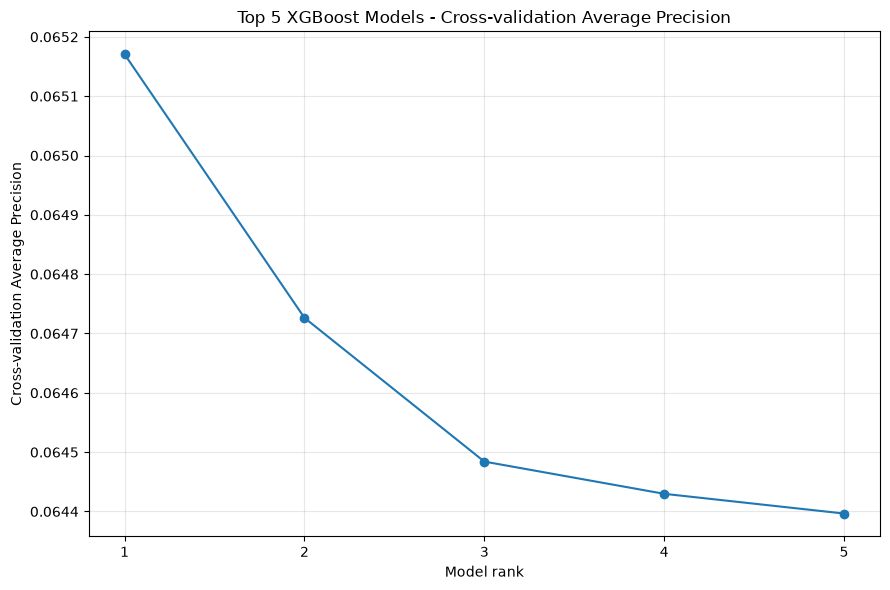


RANDOMIZED SEARCH COMPLETED

Output directory:
c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\XGBoost_RandomizedSearch_OpenML_42742

Saved files:
 - 01_top5_cv_average_precision.png
 - best_model_parameters.json
 - best_xgboost_randomized_model.joblib
 - cv_folds.pkl
 - randomized_search_all_results.csv
 - randomized_search_summary.json
 - top5_models.csv
 - top5_models_parameters.json



In [10]:
# ============================================================
# XGBOOST RANDOMIZED SEARCH
# OPENML 42742
# ============================================================
#
# Goal:
# Optimize the XGBoost hyperparameters using RandomizedSearchCV.
#
# IMPORTANT:
# - The test set is NOT used during tuning.
# - Cross-validation is performed only on the training data.
# - The exact CV folds are saved for later experiments.
# - The Top 5 configurations are saved for further analysis.
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)

from xgboost import XGBClassifier


# ============================================================
# 2. OUTPUT DIRECTORY
# ============================================================

output_dir = "XGBoost_RandomizedSearch_OpenML_42742"

os.makedirs(
    output_dir,
    exist_ok=True
)

print("=" * 70)
print("XGBOOST RANDOMIZED SEARCH")
print("=" * 70)


# ============================================================
# 3. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "X_train_processed",
    "X_test_processed",
    "y_train",
    "y_test",
    "preprocessor"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:

    raise NameError(
        "The following required variables are missing: "
        + ", ".join(missing_variables)
        + "\nPlease run the XGBoost baseline cell first."
    )


print("\nRequired variables found.")


# ============================================================
# 4. CREATE AND SAVE CONTROLLED CV FOLDS
# ============================================================
#
# We explicitly create the folds instead of letting
# RandomizedSearchCV generate them internally.
#
# This allows us to reuse EXACTLY the same folds later
# for the weighted XGBoost experiment.
# ============================================================

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

cv_splits = list(
    cv.split(
        X_train_processed,
        y_train
    )
)

print("\nCross-validation:")
print("Number of folds:", len(cv_splits))

for i, (train_idx, val_idx) in enumerate(
    cv_splits,
    start=1
):

    print(
        f"Fold {i}: "
        f"{len(train_idx):,} training observations | "
        f"{len(val_idx):,} validation observations"
    )


# Save exact folds
folds_path = os.path.join(
    output_dir,
    "cv_folds.pkl"
)

with open(
    folds_path,
    "wb"
) as f:

    pickle.dump(
        cv_splits,
        f
    )

print("\nCV folds saved to:")
print(os.path.abspath(folds_path))


# ============================================================
# 5. DEFINE BASE XGBOOST MODEL
# ============================================================
#
# scale_pos_weight is intentionally NOT used here.
#
# This experiment is the non-weighted hyperparameter search.
# ============================================================

xgb_model = XGBClassifier(

    objective="binary:logistic",

    eval_metric="aucpr",

    tree_method="hist",

    random_state=42,

    n_jobs=-1
)


# ============================================================
# 6. DEFINE HYPERPARAMETER SEARCH SPACE
# ============================================================
#
# The ranges are deliberately moderate.
#
# RandomizedSearchCV will sample combinations from these
# distributions rather than testing every possible combination.
# ============================================================

param_distributions = {

    "n_estimators": [
        100,
        200,
        300,
        400
    ],

    "max_depth": [
        3,
        4,
        5,
        6
    ],

    "learning_rate": [
        0.03,
        0.05,
        0.1,
        0.2
    ],

    "subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "colsample_bytree": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "min_child_weight": [
        1,
        3,
        5,
        10
    ],

    "gamma": [
        0,
        0.1,
        0.3,
        0.5
    ],

    "reg_alpha": [
        0,
        0.01,
        0.1
    ],

    "reg_lambda": [
        1,
        2,
        5
    ]
}


# ============================================================
# 7. RANDOMIZED SEARCH
# ============================================================
#
# Average Precision is used as the main optimization metric.
#
# This is particularly appropriate because the target class
# is strongly imbalanced.
# ============================================================

random_search = RandomizedSearchCV(

    estimator=xgb_model,

    param_distributions=param_distributions,

    n_iter=12,

    scoring="average_precision",

    cv=cv_splits,

    verbose=2,

    random_state=42,

    n_jobs=1,

    return_train_score=True
)


# ============================================================
# 8. RUN RANDOMIZED SEARCH
# ============================================================

print("\n" + "=" * 70)
print("STARTING RANDOMIZED SEARCH")
print("=" * 70)

random_search.fit(
    X_train_processed,
    y_train
)

print("\nRandomizedSearchCV completed.")


# ============================================================
# 9. BEST MODEL
# ============================================================

best_model = random_search.best_estimator_

print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)

print(
    "\nBest CV Average Precision:"
)

print(
    f"{random_search.best_score_:.6f}"
)

print("\nBest hyperparameters:")

for parameter, value in (
    random_search.best_params_
    .items()
):

    print(
        f"{parameter}: {value}"
    )


# ============================================================
# 10. SAVE COMPLETE CV RESULTS
# ============================================================

cv_results = pd.DataFrame(
    random_search.cv_results_
)

cv_results.to_csv(
    os.path.join(
        output_dir,
        "randomized_search_all_results.csv"
    ),
    index=False
)

print(
    "\nComplete CV results saved."
)


# ============================================================
# 11. EXTRACT TOP 5 MODELS
# ============================================================

top5 = (
    cv_results
    .sort_values(
        "rank_test_score"
    )
    .head(5)
    .copy()
)


# ============================================================
# 12. CREATE CLEAN TOP 5 TABLE
# ============================================================

top5_table = pd.DataFrame({

    "Rank": top5["rank_test_score"],

    "CV_AP": top5["mean_test_score"],

    "CV_AP_STD": top5["std_test_score"],

    "Train_AP": top5["mean_train_score"],

    "n_estimators": top5["param_n_estimators"],

    "max_depth": top5["param_max_depth"],

    "learning_rate": top5["param_learning_rate"],

    "subsample": top5["param_subsample"],

    "colsample": top5["param_colsample_bytree"],

    "min_child_weight": top5["param_min_child_weight"],

    "gamma": top5["param_gamma"],

    "reg_alpha": top5["param_reg_alpha"],

    "reg_lambda": top5["param_reg_lambda"]
})


top5_table = top5_table.reset_index(
    drop=True
)


# ============================================================
# 13. SAVE TOP 5 TABLE
# ============================================================

top5_table.to_csv(
    os.path.join(
        output_dir,
        "top5_models.csv"
    ),
    index=False
)


print("\n" + "=" * 70)
print("TOP 5 MODELS")
print("=" * 70)

print(
    top5_table.to_string(
        index=False
    )
)


# ============================================================
# 14. SAVE TOP 5 PARAMETERS AS JSON
# ============================================================

top5_parameters = []

for _, row in top5.iterrows():

    parameters = {

        parameter: row[
            f"param_{parameter}"
        ]

        for parameter
        in param_distributions.keys()
    }

    top5_parameters.append({

        "rank": int(
            row["rank_test_score"]
        ),

        "cv_average_precision": float(
            row["mean_test_score"]
        ),

        "cv_ap_std": float(
            row["std_test_score"]
        ),

        "hyperparameters": parameters

    })


with open(
    os.path.join(
        output_dir,
        "top5_models_parameters.json"
    ),
    "w"
) as f:

    json.dump(
        top5_parameters,
        f,
        indent=4,
        default=str
    )


# ============================================================
# 15. SAVE THE BEST MODEL
# ============================================================
#
# We save the fitted best estimator so that it can be reused
# without retraining.
# ============================================================

import joblib

joblib.dump(
    best_model,
    os.path.join(
        output_dir,
        "best_xgboost_randomized_model.joblib"
    )
)


# ============================================================
# 16. SAVE BEST MODEL PARAMETERS
# ============================================================

with open(
    os.path.join(
        output_dir,
        "best_model_parameters.json"
    ),
    "w"
) as f:

    json.dump(
        random_search.best_params_,
        f,
        indent=4,
        default=str
    )


# ============================================================
# 17. TOP 5 CV PERFORMANCE PLOT
# ============================================================

plt.figure(
    figsize=(9, 6)
)

ranks = top5_table["Rank"].astype(str)

plt.plot(
    ranks,
    top5_table["CV_AP"],
    marker="o"
)

plt.xlabel(
    "Model rank"
)

plt.ylabel(
    "Cross-validation Average Precision"
)

plt.title(
    "Top 5 XGBoost Models - Cross-validation Average Precision"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "01_top5_cv_average_precision.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 18. SAVE RANDOMIZED SEARCH SUMMARY
# ============================================================

summary = {

    "dataset": "OpenML 42742",

    "cv_folds": 3,

    "n_iter": 12,

    "scoring": "average_precision",

    "random_state": 42,

    "best_cv_average_precision": float(
        random_search.best_score_
    ),

    "best_parameters": random_search.best_params_

}


with open(
    os.path.join(
        output_dir,
        "randomized_search_summary.json"
    ),
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4,
        default=str
    )


# ============================================================
# 19. FINAL OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("RANDOMIZED SEARCH COMPLETED")
print("=" * 70)

print("\nOutput directory:")

print(
    os.path.abspath(
        output_dir
    )
)

print("\nSaved files:")

for filename in sorted(
    os.listdir(output_dir)
):

    print(
        " -",
        filename
    )

print("\n" + "=" * 70)

CREATING LOGBOOK TABLES FOR XGBOOST RANDOMIZED SEARCH


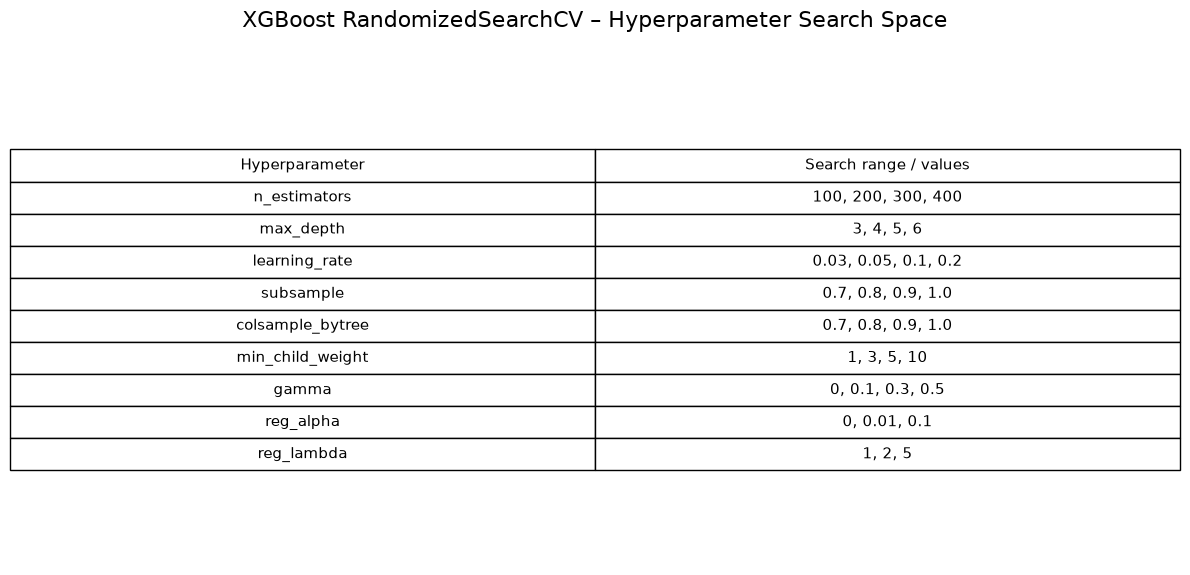

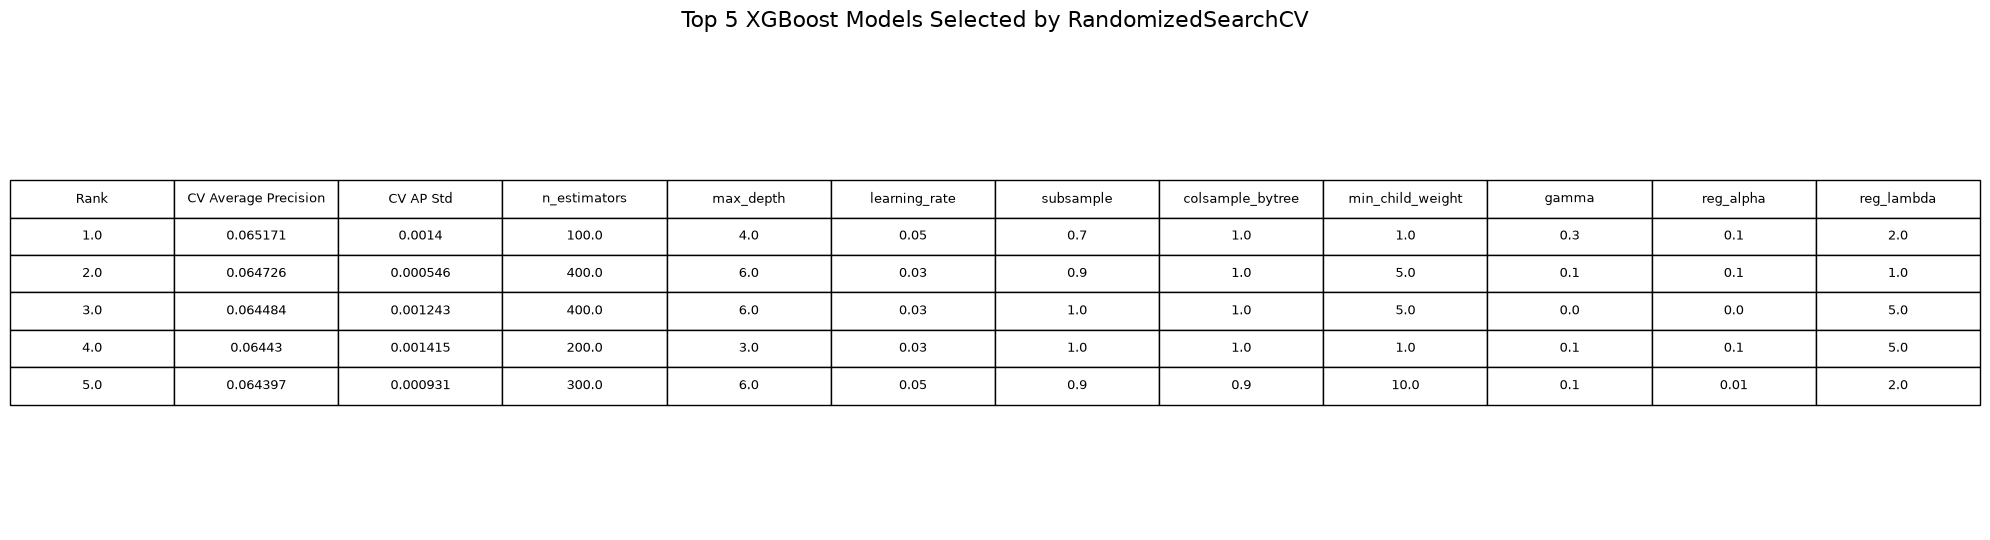

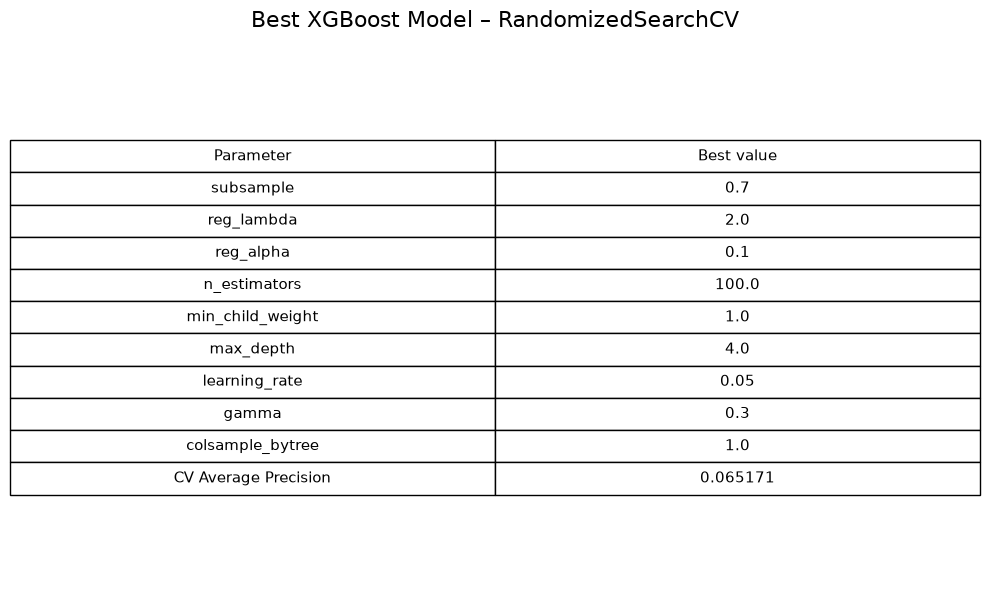

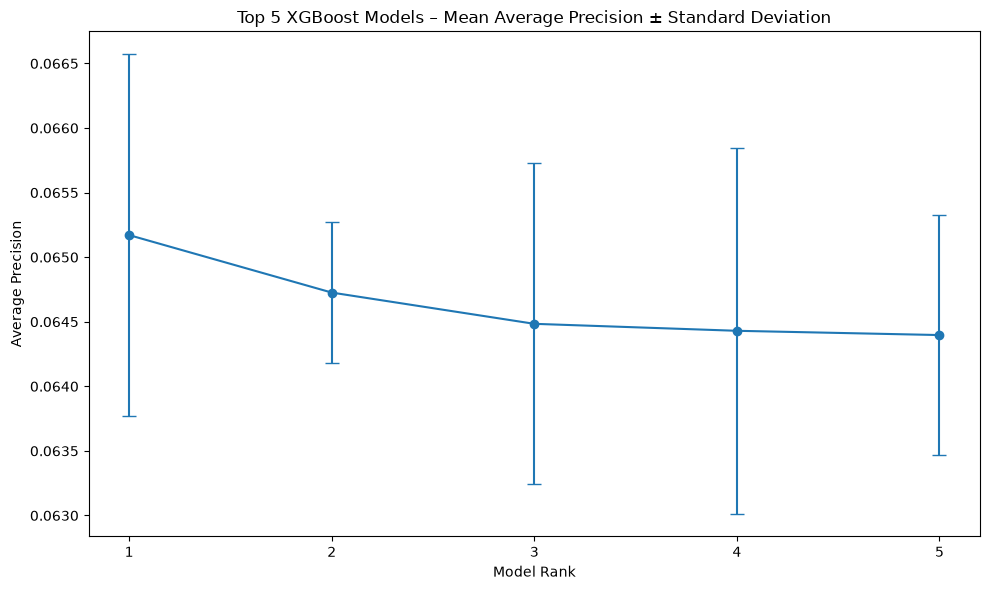


RANDOMIZED SEARCH RESULTS SUCCESSFULLY SAVED

Files created:

1. Parameter search space:
   01_XGBoost_RandomizedSearch_parameter_ranges.png

2. Top 5 models:
   02_XGBoost_RandomizedSearch_TOP5_complete.png

3. Best model parameters:
   03_XGBoost_RandomizedSearch_BEST_parameters.png

4. Best trained model:
   04_XGBoost_RandomizedSearch_BEST_model.joblib

5. Top 5 performance:
   05_XGBoost_RandomizedSearch_TOP5_performance.png

Folder:
c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\XGBoost_RandomizedSearch


In [11]:
# ============================================================
# XGBOOST RANDOMIZED SEARCH
# COMPLETE RESULTS FOR LOGBOOK
# ============================================================

import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

randomized_dir = "XGBoost_RandomizedSearch"
os.makedirs(randomized_dir, exist_ok=True)

print("=" * 80)
print("CREATING LOGBOOK TABLES FOR XGBOOST RANDOMIZED SEARCH")
print("=" * 80)


# ============================================================
# 1. SEARCH SPACE / PARAMETER RANGES
# ============================================================

param_distributions = random_search.param_distributions

range_rows = []

for parameter, values in param_distributions.items():

    # Convert parameter range to readable text
    if hasattr(values, "dist"):
        # scipy statistical distribution
        distribution_name = type(values.dist).__name__

        if hasattr(values, "kwds") and values.kwds:
            parameters_text = ", ".join(
                f"{k}={v}"
                for k, v in values.kwds.items()
            )
            range_text = (
                f"{distribution_name} "
                f"({parameters_text})"
            )
        else:
            range_text = distribution_name

    elif isinstance(values, (list, tuple)):
        range_text = ", ".join(
            str(v) for v in values
        )

    else:
        range_text = str(values)

    range_rows.append({
        "Hyperparameter": parameter,
        "Search range / values": range_text
    })


search_space_table = pd.DataFrame(range_rows)


# ------------------------------------------------------------
# Save search-space table as IMAGE
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, max(3, len(search_space_table) * 0.65))
)

ax.axis("off")

table = ax.table(
    cellText=search_space_table.values,
    colLabels=search_space_table.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.7)

ax.set_title(
    "XGBoost RandomizedSearchCV – Hyperparameter Search Space",
    fontsize=16,
    pad=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        randomized_dir,
        "01_XGBoost_RandomizedSearch_parameter_ranges.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 2. COMPLETE CV RESULTS
# ============================================================

cv_results = pd.DataFrame(
    random_search.cv_results_
)

# Relevant columns
result_columns = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",

    "param_n_estimators",
    "param_max_depth",
    "param_learning_rate",
    "param_subsample",
    "param_colsample_bytree",
    "param_min_child_weight",
    "param_gamma",
    "param_reg_alpha",
    "param_reg_lambda"
]

result_columns = [
    col
    for col in result_columns
    if col in cv_results.columns
]

complete_results = cv_results[
    result_columns
].copy()


# ------------------------------------------------------------
# Rename
# ------------------------------------------------------------

complete_results = complete_results.rename(
    columns={
        "rank_test_score": "Rank",
        "mean_test_score": "CV Average Precision",
        "std_test_score": "CV AP Std",
        "param_n_estimators": "n_estimators",
        "param_max_depth": "max_depth",
        "param_learning_rate": "learning_rate",
        "param_subsample": "subsample",
        "param_colsample_bytree": "colsample_bytree",
        "param_min_child_weight": "min_child_weight",
        "param_gamma": "gamma",
        "param_reg_alpha": "reg_alpha",
        "param_reg_lambda": "reg_lambda"
    }
)


# Sort by performance
complete_results = complete_results.sort_values(
    "CV Average Precision",
    ascending=False
).reset_index(drop=True)


# ============================================================
# 3. TOP 5 MODELS
# ============================================================

top5 = complete_results.head(5).copy()

top5["Rank"] = range(1, 6)


# Round scores
top5["CV Average Precision"] = (
    top5["CV Average Precision"].astype(float).round(6)
)

top5["CV AP Std"] = (
    top5["CV AP Std"].astype(float).round(6)
)


# ------------------------------------------------------------
# Save TOP 5 as IMAGE
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(20, 5.5)
)

ax.axis("off")

table = ax.table(
    cellText=top5.values,
    colLabels=top5.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.0)

ax.set_title(
    "Top 5 XGBoost Models Selected by RandomizedSearchCV",
    fontsize=16,
    pad=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        randomized_dir,
        "02_XGBoost_RandomizedSearch_TOP5_complete.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 4. BEST MODEL PARAMETERS
# ============================================================

best_params = random_search.best_params_

best_parameter_rows = []

for parameter, value in best_params.items():

    best_parameter_rows.append({
        "Parameter": parameter,
        "Best value": value
    })

best_parameter_table = pd.DataFrame(
    best_parameter_rows
)


# ------------------------------------------------------------
# Add CV score
# ------------------------------------------------------------

best_parameter_table.loc[
    len(best_parameter_table)
] = [
    "CV Average Precision",
    round(random_search.best_score_, 6)
]


# ------------------------------------------------------------
# Save BEST PARAMETERS as IMAGE
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, max(4, len(best_parameter_table) * 0.6))
)

ax.axis("off")

table = ax.table(
    cellText=best_parameter_table.values,
    colLabels=best_parameter_table.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.7)

ax.set_title(
    "Best XGBoost Model – RandomizedSearchCV",
    fontsize=16,
    pad=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        randomized_dir,
        "03_XGBoost_RandomizedSearch_BEST_parameters.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 5. SAVE THE BEST TRAINED MODEL
# ============================================================

joblib.dump(
    random_search.best_estimator_,
    os.path.join(
        randomized_dir,
        "04_XGBoost_RandomizedSearch_BEST_model.joblib"
    )
)


# ============================================================
# 6. PERFORMANCE GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

plt.errorbar(
    top5["Rank"],
    top5["CV Average Precision"],
    yerr=top5["CV AP Std"],
    fmt="o-",
    capsize=5
)

plt.xlabel("Model Rank")
plt.ylabel("Average Precision")
plt.title(
    "Top 5 XGBoost Models – "
    "Mean Average Precision ± Standard Deviation"
)

plt.xticks(top5["Rank"])

plt.tight_layout()

plt.savefig(
    os.path.join(
        randomized_dir,
        "05_XGBoost_RandomizedSearch_TOP5_performance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 7. FINAL MESSAGE
# ============================================================

print("\n" + "=" * 80)
print("RANDOMIZED SEARCH RESULTS SUCCESSFULLY SAVED")
print("=" * 80)

print("\nFiles created:")

print(
    "\n1. Parameter search space:"
    "\n   01_XGBoost_RandomizedSearch_parameter_ranges.png"
)

print(
    "\n2. Top 5 models:"
    "\n   02_XGBoost_RandomizedSearch_TOP5_complete.png"
)

print(
    "\n3. Best model parameters:"
    "\n   03_XGBoost_RandomizedSearch_BEST_parameters.png"
)

print(
    "\n4. Best trained model:"
    "\n   04_XGBoost_RandomizedSearch_BEST_model.joblib"
)

print(
    "\n5. Top 5 performance:"
    "\n   05_XGBoost_RandomizedSearch_TOP5_performance.png"
)

print(
    f"\nFolder:\n{os.path.abspath(randomized_dir)}"
)

In [ ]:
#Classification of the 5 Models using Now ROC-AUC/Gini


NON-WEIGHTED MODEL — ORIGINAL RANK 1
Fit 1/15 — Rank 1, Fold 1
AP = 0.066562 | ROC-AUC = 0.639848 | Gini = 0.279695
Fit 2/15 — Rank 1, Fold 2
AP = 0.063256 | ROC-AUC = 0.632630 | Gini = 0.265260
Fit 3/15 — Rank 1, Fold 3
AP = 0.065694 | ROC-AUC = 0.636785 | Gini = 0.273570

NON-WEIGHTED MODEL — ORIGINAL RANK 2
Fit 4/15 — Rank 2, Fold 1
AP = 0.065497 | ROC-AUC = 0.637571 | Gini = 0.275142
Fit 5/15 — Rank 2, Fold 2
AP = 0.064377 | ROC-AUC = 0.634671 | Gini = 0.269341
Fit 6/15 — Rank 2, Fold 3
AP = 0.064305 | ROC-AUC = 0.638172 | Gini = 0.276344

NON-WEIGHTED MODEL — ORIGINAL RANK 3
Fit 7/15 — Rank 3, Fold 1
AP = 0.066109 | ROC-AUC = 0.638283 | Gini = 0.276566
Fit 8/15 — Rank 3, Fold 2
AP = 0.063091 | ROC-AUC = 0.632518 | Gini = 0.265035
Fit 9/15 — Rank 3, Fold 3
AP = 0.064252 | ROC-AUC = 0.637481 | Gini = 0.274962

NON-WEIGHTED MODEL — ORIGINAL RANK 4
Fit 10/15 — Rank 4, Fold 1
AP = 0.066275 | ROC-AUC = 0.637536 | Gini = 0.275073
Fit 11/15 — Rank 4, Fold 2
AP = 0.062836 | ROC-AUC = 0.63

,Original_AP_Rank,AP_Rank,CV_AP,CV_AP_Std
0,1,1,0.065171,0.001400
1,2,2,0.064726,0.000546
2,3,3,0.064484,0.001243
3,4,4,0.064430,0.001415
4,5,5,0.064397,0.000931



NON-WEIGHTED — RANKING BY ROC-AUC / GINI


,Original_AP_Rank,ROC_AUC_Rank,CV_ROC_AUC,CV_ROC_AUC_Std,CV_Gini
1,2,1,0.636804,0.001529,0.273609
0,1,2,0.636421,0.002958,0.272842
2,3,3,0.636094,0.002550,0.272188
4,5,4,0.635570,0.002123,0.271139
3,4,5,0.634436,0.002715,0.268872


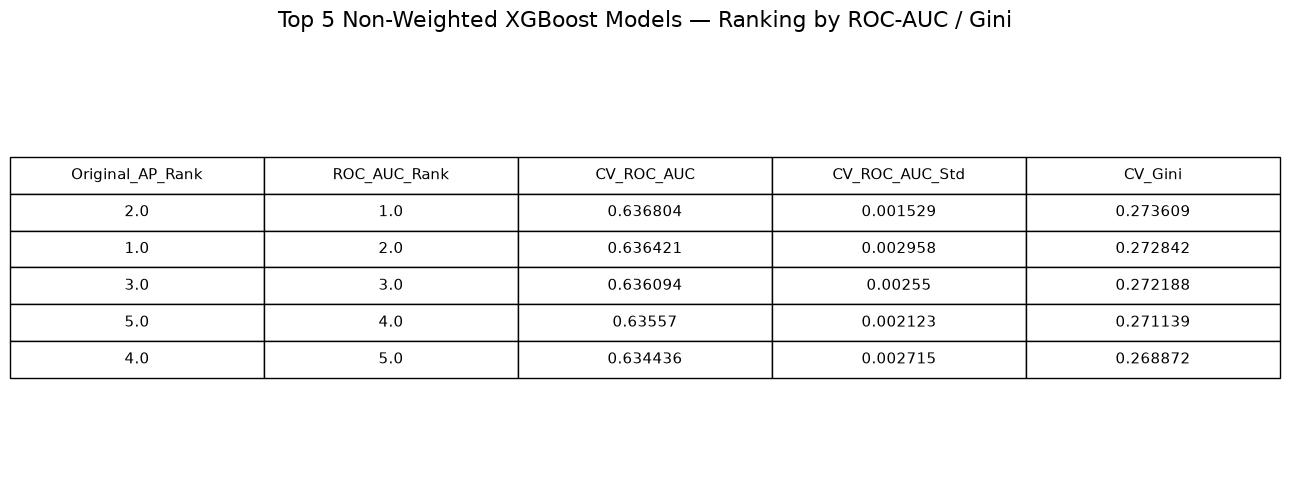

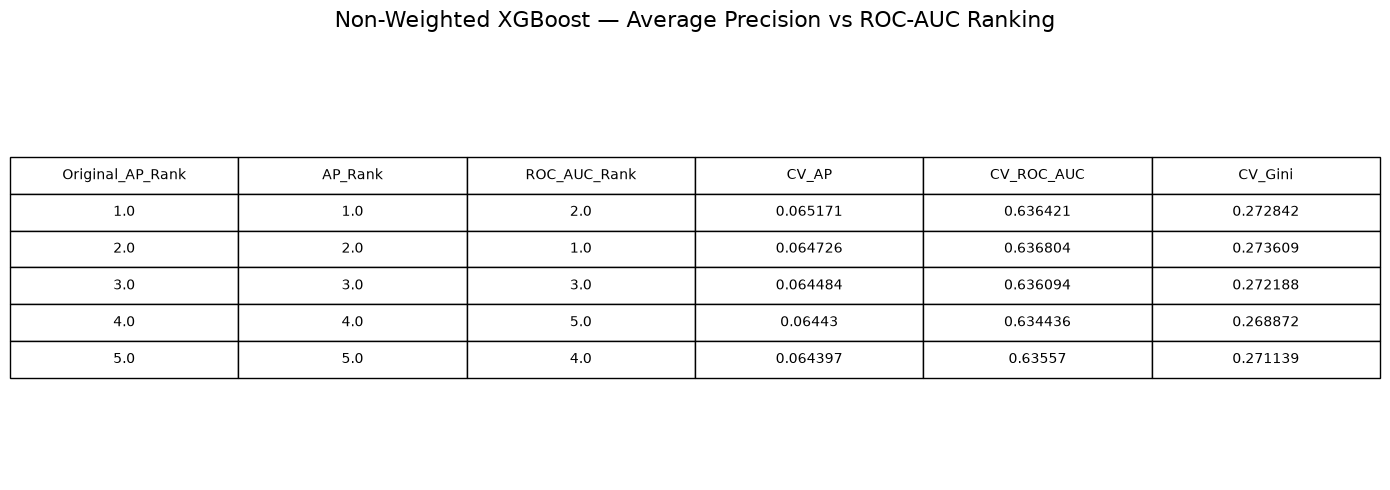

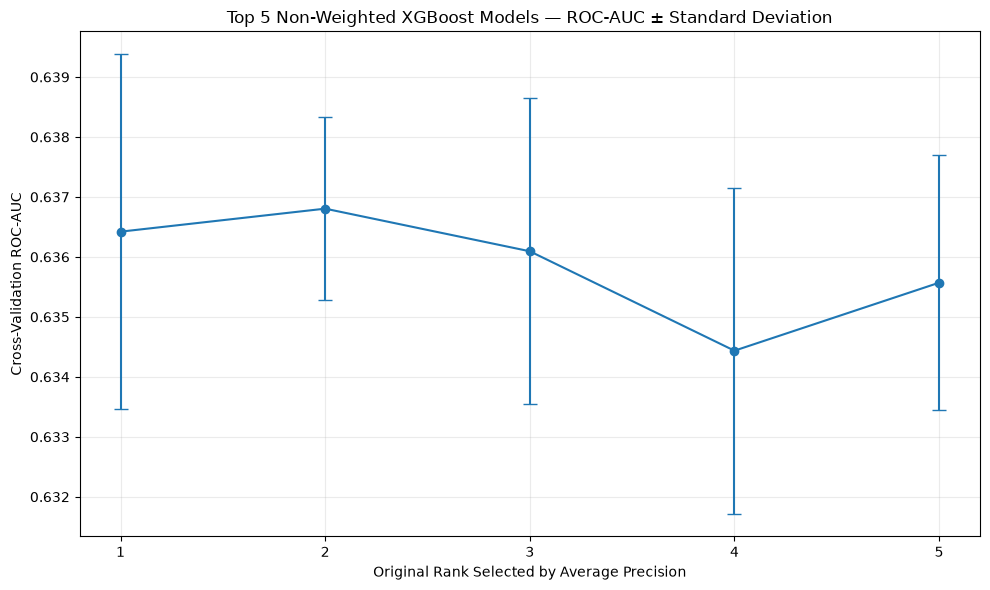


NON-WEIGHTED CONTROLLED EVALUATION COMPLETE

Total fits performed: 15

✓ Same 5 configurations
✓ Same 3 saved CV folds
✓ AP calculated
✓ ROC-AUC calculated
✓ Gini calculated
✓ AP ranking created
✓ ROC-AUC/Gini ranking created

Results saved in:
c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\XGBoost_NonWeighted_Controlled_Evaluation


In [15]:
# ============================================================
# NON-WEIGHTED TOP 5
# ROC-AUC / GINI EVALUATION USING THE SAME SAVED 3 CV FOLDS
# ============================================================

import os
import json
import pickle
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)


# ============================================================
# 1. OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = "XGBoost_NonWeighted_Controlled_Evaluation"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 2. LOCATE RANDOMIZED SEARCH FILES
# ============================================================

candidate_directories = [
    "XGBoost_RandomizedSearch_OpenML_42742",
    "XGBoost_RandomizedSearch"
]

randomized_dir = None

for directory in candidate_directories:

    folds_path_test = os.path.join(
        directory,
        "cv_folds.pkl"
    )

    params_path_test = os.path.join(
        directory,
        "top5_models_parameters.json"
    )

    if (
        os.path.exists(folds_path_test)
        and os.path.exists(params_path_test)
    ):
        randomized_dir = directory
        break


if randomized_dir is None:
    raise FileNotFoundError(
        "Saved CV folds and Top 5 parameter files were not found."
    )


# ============================================================
# 3. LOAD THE EXACT SAME CV FOLDS
# ============================================================

folds_path = os.path.join(
    randomized_dir,
    "cv_folds.pkl"
)

with open(
    folds_path,
    "rb"
) as f:

    cv_splits = pickle.load(f)


if len(cv_splits) != 3:
    raise ValueError(
        f"Expected 3 folds, found {len(cv_splits)}."
    )


# ============================================================
# 4. LOAD THE SAME TOP 5 CONFIGURATIONS
# ============================================================

parameters_path = os.path.join(
    randomized_dir,
    "top5_models_parameters.json"
)

with open(
    parameters_path,
    "r"
) as f:

    top5_models = json.load(f)


# ============================================================
# 5. PREPARE TARGET
# ============================================================

y_train_array = np.asarray(
    y_train
).astype(int)


# ============================================================
# 6. EVALUATE THE 5 NON-WEIGHTED CONFIGURATIONS
# ============================================================

results = []

fit_counter = 0


for model_info in sorted(
    top5_models,
    key=lambda x: x["rank"]
):

    original_rank = int(
        model_info["rank"]
    )

    params = model_info[
        "hyperparameters"
    ].copy()


    # Ensure correct numeric types
    params["n_estimators"] = int(
        params["n_estimators"]
    )

    params["max_depth"] = int(
        params["max_depth"]
    )

    params["learning_rate"] = float(
        params["learning_rate"]
    )

    params["subsample"] = float(
        params["subsample"]
    )

    params["colsample_bytree"] = float(
        params["colsample_bytree"]
    )

    params["min_child_weight"] = float(
        params["min_child_weight"]
    )

    params["gamma"] = float(
        params["gamma"]
    )

    params["reg_alpha"] = float(
        params["reg_alpha"]
    )

    params["reg_lambda"] = float(
        params["reg_lambda"]
    )


    fold_ap = []
    fold_auc = []
    fold_gini = []


    print("\n" + "=" * 70)
    print(f"NON-WEIGHTED MODEL — ORIGINAL RANK {original_rank}")
    print("=" * 70)


    for fold_number, (
        train_idx,
        valid_idx
    ) in enumerate(
        cv_splits,
        start=1
    ):

        fit_counter += 1

        print(
            f"Fit {fit_counter}/15 — "
            f"Rank {original_rank}, Fold {fold_number}"
        )


        X_fold_train = X_train_processed[
            train_idx
        ]

        X_fold_valid = X_train_processed[
            valid_idx
        ]

        y_fold_train = y_train_array[
            train_idx
        ]

        y_fold_valid = y_train_array[
            valid_idx
        ]


        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr",
            tree_method="hist",
            random_state=42,
            n_jobs=-1,
            **params
        )


        model.fit(
            X_fold_train,
            y_fold_train
        )


        proba = model.predict_proba(
            X_fold_valid
        )[:, 1]


        ap = average_precision_score(
            y_fold_valid,
            proba
        )

        auc = roc_auc_score(
            y_fold_valid,
            proba
        )

        gini = (
            2 * auc - 1
        )


        fold_ap.append(ap)
        fold_auc.append(auc)
        fold_gini.append(gini)


        print(
            f"AP = {ap:.6f} | "
            f"ROC-AUC = {auc:.6f} | "
            f"Gini = {gini:.6f}"
        )


    results.append({

        "Original_AP_Rank":
            original_rank,

        "CV_AP":
            np.mean(fold_ap),

        "CV_AP_Std":
            np.std(fold_ap),

        "CV_ROC_AUC":
            np.mean(fold_auc),

        "CV_ROC_AUC_Std":
            np.std(fold_auc),

        "CV_Gini":
            np.mean(fold_gini),

        "CV_Gini_Std":
            np.std(fold_gini)
    })


# ============================================================
# 7. RESULTS DATAFRAME
# ============================================================

nonweighted_auc_df = pd.DataFrame(
    results
)


# ============================================================
# 8. CREATE BOTH RANKINGS
# ============================================================

nonweighted_auc_df[
    "AP_Rank"
] = (
    nonweighted_auc_df[
        "CV_AP"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)


nonweighted_auc_df[
    "ROC_AUC_Rank"
] = (
    nonweighted_auc_df[
        "CV_ROC_AUC"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)


# Gini ranking is identical to ROC-AUC ranking
nonweighted_auc_df[
    "Gini_Rank"
] = (
    nonweighted_auc_df[
        "CV_Gini"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)


# ============================================================
# 9. DISPLAY AP RANKING
# ============================================================

print("\n" + "=" * 80)
print("NON-WEIGHTED — RANKING BY AVERAGE PRECISION")
print("=" * 80)

display(
    nonweighted_auc_df[
        [
            "Original_AP_Rank",
            "AP_Rank",
            "CV_AP",
            "CV_AP_Std"
        ]
    ]
    .sort_values(
        "AP_Rank"
    )
    .round(6)
)


# ============================================================
# 10. DISPLAY ROC-AUC / GINI RANKING
# ============================================================

auc_ranking = (
    nonweighted_auc_df[
        [
            "Original_AP_Rank",
            "ROC_AUC_Rank",
            "CV_ROC_AUC",
            "CV_ROC_AUC_Std",
            "CV_Gini"
        ]
    ]
    .sort_values(
        "ROC_AUC_Rank"
    )
    .copy()
)


print("\n" + "=" * 80)
print("NON-WEIGHTED — RANKING BY ROC-AUC / GINI")
print("=" * 80)

display(
    auc_ranking.round(6)
)


# ============================================================
# 11. SAVE ROC-AUC RANKING AS IMAGE
# ============================================================

fig, ax = plt.subplots(
    figsize=(13, 5)
)

ax.axis("off")

table = ax.table(
    cellText=auc_ranking.round(6).values,
    colLabels=auc_ranking.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

ax.set_title(
    "Top 5 Non-Weighted XGBoost Models — "
    "Ranking by ROC-AUC / Gini",
    fontsize=16,
    pad=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "01_nonweighted_ROC_AUC_Gini_ranking.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 12. AP RANK VS ROC-AUC RANK IMAGE
# ============================================================

rank_comparison = (
    nonweighted_auc_df[
        [
            "Original_AP_Rank",
            "AP_Rank",
            "ROC_AUC_Rank",
            "CV_AP",
            "CV_ROC_AUC",
            "CV_Gini"
        ]
    ]
    .sort_values(
        "Original_AP_Rank"
    )
)


fig, ax = plt.subplots(
    figsize=(14, 5)
)

ax.axis("off")

table = ax.table(
    cellText=rank_comparison.round(6).values,
    colLabels=rank_comparison.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

ax.set_title(
    "Non-Weighted XGBoost — "
    "Average Precision vs ROC-AUC Ranking",
    fontsize=16,
    pad=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "02_AP_vs_ROC_AUC_ranking.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 13. ROC-AUC LINE PLOT
# ============================================================

plot_df = (
    nonweighted_auc_df
    .sort_values(
        "Original_AP_Rank"
    )
)


plt.figure(
    figsize=(10, 6)
)

plt.errorbar(
    plot_df[
        "Original_AP_Rank"
    ],
    plot_df[
        "CV_ROC_AUC"
    ],
    yerr=plot_df[
        "CV_ROC_AUC_Std"
    ],
    marker="o",
    capsize=5
)

plt.xlabel(
    "Original Rank Selected by Average Precision"
)

plt.ylabel(
    "Cross-Validation ROC-AUC"
)

plt.title(
    "Top 5 Non-Weighted XGBoost Models — "
    "ROC-AUC ± Standard Deviation"
)

plt.xticks(
    plot_df[
        "Original_AP_Rank"
    ]
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "03_nonweighted_ROC_AUC.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 14. SAVE RESULTS
# ============================================================

nonweighted_auc_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "nonweighted_AP_ROC_AUC_Gini_results.csv"
    ),
    index=False
)


print("\n" + "=" * 80)
print("NON-WEIGHTED CONTROLLED EVALUATION COMPLETE")
print("=" * 80)

print(
    f"\nTotal fits performed: {fit_counter}"
)

print(
    "\n✓ Same 5 configurations"
)

print(
    "✓ Same 3 saved CV folds"
)

print(
    "✓ AP calculated"
)

print(
    "✓ ROC-AUC calculated"
)

print(
    "✓ Gini calculated"
)

print(
    "✓ AP ranking created"
)

print(
    "✓ ROC-AUC/Gini ranking created"
)

print(
    f"\nResults saved in:\n"
    f"{os.path.abspath(OUTPUT_DIR)}"
)

RECOVERING OOF PREDICTIONS
BEST NON-WEIGHTED XGBOOST BY ROC-AUC

RandomizedSearch files found in:
c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\XGBoost_RandomizedSearch_OpenML_42742

Loaded exactly 3 saved CV folds.

Best non-weighted configuration by ROC-AUC:
Original AP Rank : 2
CV ROC-AUC       : 0.636804
CV Gini          : 0.273609
CV AP            : 0.064726

Exact hyperparameters:
n_estimators: 400
max_depth: 6
learning_rate: 0.03
subsample: 0.9
colsample_bytree: 1.0
min_child_weight: 5.0
gamma: 0.1
reg_alpha: 0.1
reg_lambda: 1.0

STARTING 3 NON-WEIGHTED FITS

Fit 1/3 — Fold 1
AP      = 0.065497
ROC-AUC = 0.637571
Gini    = 0.275142

Fit 2/3 — Fold 2
AP      = 0.064377
ROC-AUC = 0.634671
Gini    = 0.269341

Fit 3/3 — Fold 3
AP      = 0.064305
ROC-AUC = 0.638172
Gini    = 0.276344

GLOBAL OOF PERFORMANCE
Average Precision : 0.064584
ROC-AUC           : 0.636784
Gini              : 0.273567


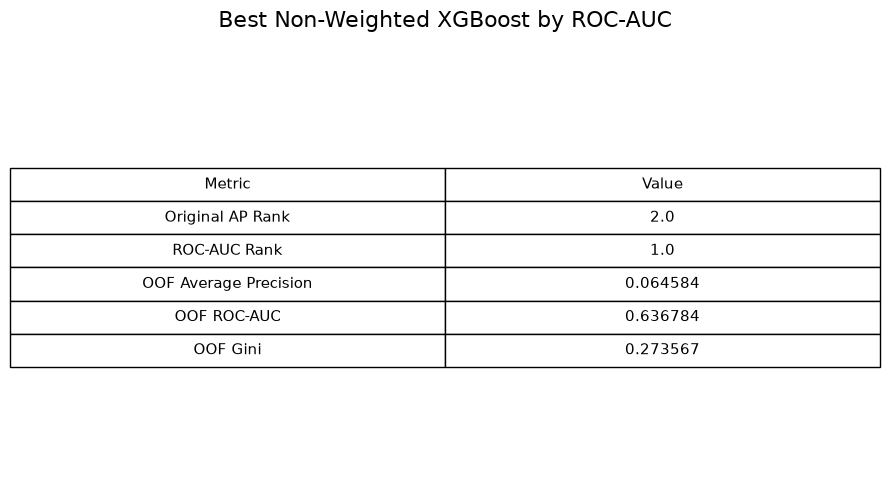

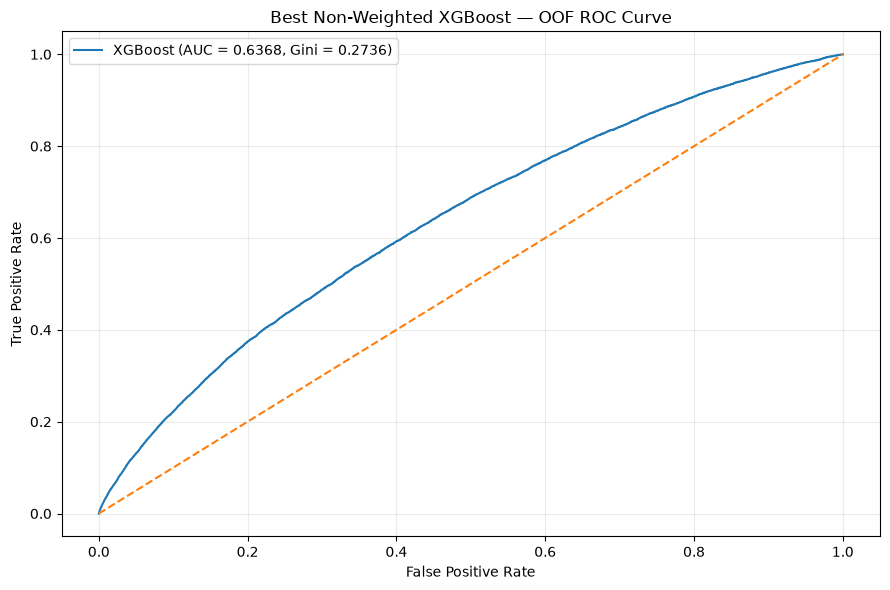

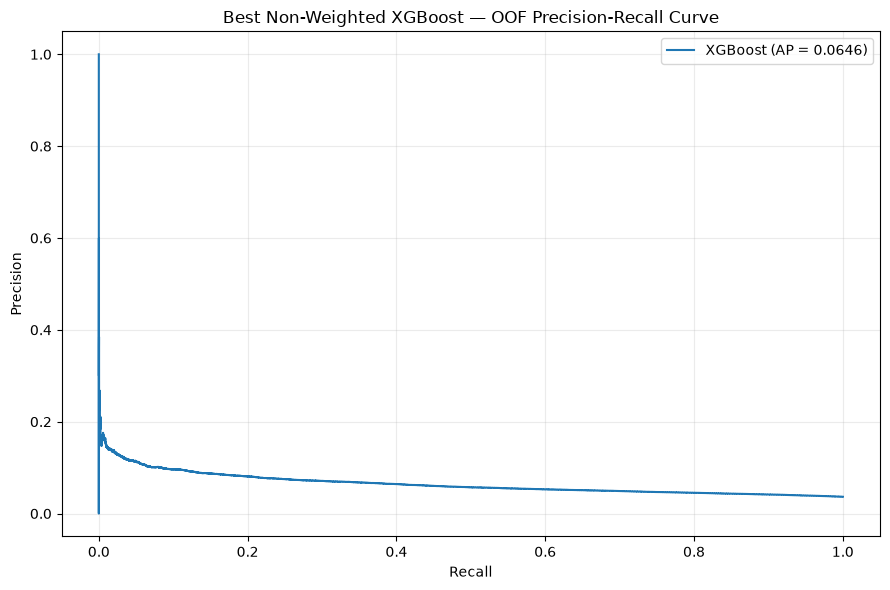


OOF RECOVERY COMPLETED

Total fits performed: 3
Selected XGBoost: Original AP Rank 2

✓ Same 3 saved CV folds
✓ Exact 9 hyperparameters
✓ Non-weighted training
✓ OOF probabilities saved
✓ ROC-AUC / Gini / AP saved

Results saved in:
c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\XGBoost_NonWeighted_Best_ROC_AUC_OOF


In [18]:
# ============================================================
# RECOVER OOF PREDICTIONS
# BEST NON-WEIGHTED XGBOOST ACCORDING TO ROC-AUC
# ============================================================
#
# This block performs ONLY 3 fits:
# one fit per previously saved CV fold.
#
# The selected model is the non-weighted XGBoost configuration
# with the best CV ROC-AUC among the Top 5 models previously
# selected by Average Precision.
#
# NO weighted training
# NO RandomizedSearchCV
# NO test-set evaluation
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import json
import pickle
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)


# ============================================================
# 1. OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = "XGBoost_NonWeighted_Best_ROC_AUC_OOF"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("=" * 80)
print("RECOVERING OOF PREDICTIONS")
print("BEST NON-WEIGHTED XGBOOST BY ROC-AUC")
print("=" * 80)


# ============================================================
# 2. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "X_train_processed",
    "y_train"
]

missing_variables = [
    var
    for var in required_variables
    if var not in globals()
]

if missing_variables:

    raise NameError(
        "Missing required variables: "
        + ", ".join(missing_variables)
    )


y_train_array = np.asarray(
    y_train
).astype(int)


# ============================================================
# 3. LOCATE SAVED RANDOMIZED SEARCH FILES
# ============================================================

candidate_directories = [
    "XGBoost_RandomizedSearch_OpenML_42742",
    "XGBoost_RandomizedSearch"
]

randomized_dir = None

for directory in candidate_directories:

    folds_candidate = os.path.join(
        directory,
        "cv_folds.pkl"
    )

    params_candidate = os.path.join(
        directory,
        "top5_models_parameters.json"
    )

    if (
        os.path.exists(folds_candidate)
        and os.path.exists(params_candidate)
    ):

        randomized_dir = directory
        break


if randomized_dir is None:

    raise FileNotFoundError(
        "Could not find the saved CV folds and "
        "Top 5 parameter file."
    )


print(
    f"\nRandomizedSearch files found in:\n"
    f"{os.path.abspath(randomized_dir)}"
)


# ============================================================
# 4. LOAD THE EXACT SAME 3 CV FOLDS
# ============================================================

folds_path = os.path.join(
    randomized_dir,
    "cv_folds.pkl"
)

with open(
    folds_path,
    "rb"
) as f:

    cv_splits = pickle.load(f)


if len(cv_splits) != 3:

    raise ValueError(
        f"Expected 3 folds, found {len(cv_splits)}."
    )


print("\nLoaded exactly 3 saved CV folds.")


# ============================================================
# 5. LOAD TOP 5 MODEL PARAMETERS
# ============================================================

parameters_path = os.path.join(
    randomized_dir,
    "top5_models_parameters.json"
)

with open(
    parameters_path,
    "r"
) as f:

    top5_models = json.load(f)


# ============================================================
# 6. LOAD NON-WEIGHTED ROC-AUC RESULTS
# ============================================================

auc_results_path = os.path.join(
    "XGBoost_NonWeighted_Controlled_Evaluation",
    "nonweighted_AP_ROC_AUC_Gini_results.csv"
)

if not os.path.exists(
    auc_results_path
):

    raise FileNotFoundError(
        "The controlled non-weighted ROC-AUC results "
        "could not be found."
    )


auc_results = pd.read_csv(
    auc_results_path
)


# ============================================================
# 7. IDENTIFY THE BEST CONFIGURATION BY ROC-AUC
# ============================================================

best_auc_row = (
    auc_results
    .sort_values(
        "CV_ROC_AUC",
        ascending=False
    )
    .iloc[0]
)


best_original_rank = int(
    best_auc_row[
        "Original_AP_Rank"
    ]
)


print("\nBest non-weighted configuration by ROC-AUC:")

print(
    f"Original AP Rank : {best_original_rank}"
)

print(
    f"CV ROC-AUC       : "
    f"{best_auc_row['CV_ROC_AUC']:.6f}"
)

print(
    f"CV Gini          : "
    f"{best_auc_row['CV_Gini']:.6f}"
)

print(
    f"CV AP            : "
    f"{best_auc_row['CV_AP']:.6f}"
)


# ============================================================
# 8. GET THE EXACT 9 HYPERPARAMETERS
# ============================================================

selected_model_info = None

for model_info in top5_models:

    if int(
        model_info["rank"]
    ) == best_original_rank:

        selected_model_info = model_info
        break


if selected_model_info is None:

    raise ValueError(
        f"Could not find parameters for "
        f"Original AP Rank {best_original_rank}."
    )


params = (
    selected_model_info[
        "hyperparameters"
    ]
    .copy()
)


# Convert parameter types explicitly
params["n_estimators"] = int(
    params["n_estimators"]
)

params["max_depth"] = int(
    params["max_depth"]
)

params["learning_rate"] = float(
    params["learning_rate"]
)

params["subsample"] = float(
    params["subsample"]
)

params["colsample_bytree"] = float(
    params["colsample_bytree"]
)

params["min_child_weight"] = float(
    params["min_child_weight"]
)

params["gamma"] = float(
    params["gamma"]
)

params["reg_alpha"] = float(
    params["reg_alpha"]
)

params["reg_lambda"] = float(
    params["reg_lambda"]
)


print("\nExact hyperparameters:")

for key, value in params.items():

    print(
        f"{key}: {value}"
    )


# ============================================================
# 9. PREPARE OOF STORAGE
# ============================================================

oof_proba = np.zeros(
    len(y_train_array),
    dtype=float
)

fold_results = []

fit_counter = 0


# ============================================================
# 10. EXACTLY 3 NON-WEIGHTED FITS
# ============================================================

print("\n" + "=" * 80)
print("STARTING 3 NON-WEIGHTED FITS")
print("=" * 80)


for fold_number, (
    train_idx,
    valid_idx
) in enumerate(
    cv_splits,
    start=1
):

    fit_counter += 1


    print(
        f"\nFit {fit_counter}/3 "
        f"— Fold {fold_number}"
    )


    X_fold_train = (
        X_train_processed[
            train_idx
        ]
    )

    X_fold_valid = (
        X_train_processed[
            valid_idx
        ]
    )

    y_fold_train = (
        y_train_array[
            train_idx
        ]
    )

    y_fold_valid = (
        y_train_array[
            valid_idx
        ]
    )


    # --------------------------------------------------------
    # SAME EXACT NON-WEIGHTED MODEL CONFIGURATION
    # --------------------------------------------------------

    model = XGBClassifier(

        objective="binary:logistic",

        eval_metric="aucpr",

        tree_method="hist",

        random_state=42,

        n_jobs=-1,

        **params
    )


    # --------------------------------------------------------
    # NON-WEIGHTED TRAINING
    # --------------------------------------------------------

    model.fit(
        X_fold_train,
        y_fold_train
    )


    # --------------------------------------------------------
    # VALIDATION PROBABILITIES
    # --------------------------------------------------------

    valid_proba = (
        model
        .predict_proba(
            X_fold_valid
        )[:, 1]
    )


    oof_proba[
        valid_idx
    ] = valid_proba


    # --------------------------------------------------------
    # FOLD METRICS
    # --------------------------------------------------------

    fold_ap = average_precision_score(
        y_fold_valid,
        valid_proba
    )

    fold_auc = roc_auc_score(
        y_fold_valid,
        valid_proba
    )

    fold_gini = (
        2 * fold_auc - 1
    )


    fold_results.append({

        "Fold":
            fold_number,

        "Average_Precision":
            fold_ap,

        "ROC_AUC":
            fold_auc,

        "Gini":
            fold_gini
    })


    print(
        f"AP      = {fold_ap:.6f}"
    )

    print(
        f"ROC-AUC = {fold_auc:.6f}"
    )

    print(
        f"Gini    = {fold_gini:.6f}"
    )


    # Save each fold model
    joblib.dump(
        model,
        os.path.join(
            OUTPUT_DIR,
            f"best_nonweighted_xgb_"
            f"rank_{best_original_rank}_"
            f"fold_{fold_number}.joblib"
        )
    )


# ============================================================
# 11. SAFETY CHECK
# ============================================================

if fit_counter != 3:

    raise RuntimeError(
        f"Expected exactly 3 fits, "
        f"but performed {fit_counter}."
    )


# ============================================================
# 12. GLOBAL OOF METRICS
# ============================================================

oof_ap = average_precision_score(
    y_train_array,
    oof_proba
)

oof_auc = roc_auc_score(
    y_train_array,
    oof_proba
)

oof_gini = (
    2 * oof_auc - 1
)


print("\n" + "=" * 80)
print("GLOBAL OOF PERFORMANCE")
print("=" * 80)

print(
    f"Average Precision : {oof_ap:.6f}"
)

print(
    f"ROC-AUC           : {oof_auc:.6f}"
)

print(
    f"Gini              : {oof_gini:.6f}"
)


# ============================================================
# 13. SAVE OOF PREDICTIONS
# ============================================================

oof_df = pd.DataFrame({

    "y_true":
        y_train_array,

    "xgb_oof_probability":
        oof_proba
})


oof_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "best_nonweighted_xgboost_OOF_predictions.csv"
    ),
    index=False
)


# ============================================================
# 14. SAVE FOLD RESULTS
# ============================================================

fold_results_df = pd.DataFrame(
    fold_results
)

fold_results_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "fold_metrics.csv"
    ),
    index=False
)


# ============================================================
# 15. SAVE SUMMARY TABLE AS IMAGE
# ============================================================

summary_df = pd.DataFrame({

    "Metric": [
        "Original AP Rank",
        "ROC-AUC Rank",
        "OOF Average Precision",
        "OOF ROC-AUC",
        "OOF Gini"
    ],

    "Value": [
        best_original_rank,
        1,
        oof_ap,
        oof_auc,
        oof_gini
    ]
})


fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.axis("off")

table = ax.table(
    cellText=summary_df.round(6).values,
    colLabels=summary_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)

ax.set_title(
    "Best Non-Weighted XGBoost by ROC-AUC",
    fontsize=16,
    pad=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "01_best_nonweighted_XGBoost_summary.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 16. OOF ROC CURVE
# ============================================================

fpr, tpr, _ = roc_curve(
    y_train_array,
    oof_proba
)


plt.figure(
    figsize=(9, 6)
)

plt.plot(
    fpr,
    tpr,
    label=(
        f"XGBoost "
        f"(AUC = {oof_auc:.4f}, "
        f"Gini = {oof_gini:.4f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Best Non-Weighted XGBoost — OOF ROC Curve"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "02_best_nonweighted_XGBoost_OOF_ROC.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 17. OOF PRECISION-RECALL CURVE
# ============================================================

precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y_train_array,
        oof_proba
    )
)


plt.figure(
    figsize=(9, 6)
)

plt.plot(
    recall_curve,
    precision_curve,
    label=(
        f"XGBoost "
        f"(AP = {oof_ap:.4f})"
    )
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Best Non-Weighted XGBoost — "
    "OOF Precision-Recall Curve"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "03_best_nonweighted_XGBoost_OOF_PR.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 18. SAVE SELECTION INFORMATION
# ============================================================

selection_info = {

    "selection_metric":
        "ROC-AUC",

    "original_AP_rank":
        best_original_rank,

    "ROC_AUC_rank":
        1,

    "OOF_average_precision":
        float(
            oof_ap
        ),

    "OOF_ROC_AUC":
        float(
            oof_auc
        ),

    "OOF_Gini":
        float(
            oof_gini
        ),

    "hyperparameters":
        params
}


with open(
    os.path.join(
        OUTPUT_DIR,
        "selection_information.json"
    ),
    "w"
) as f:

    json.dump(
        selection_info,
        f,
        indent=4
    )


# ============================================================
# 19. FINAL MESSAGE
# ============================================================

print("\n" + "=" * 80)
print("OOF RECOVERY COMPLETED")
print("=" * 80)

print(
    f"\nTotal fits performed: {fit_counter}"
)

print(
    f"Selected XGBoost: "
    f"Original AP Rank {best_original_rank}"
)

print(
    "\n✓ Same 3 saved CV folds"
)

print(
    "✓ Exact 9 hyperparameters"
)

print(
    "✓ Non-weighted training"
)

print(
    "✓ OOF probabilities saved"
)

print(
    "✓ ROC-AUC / Gini / AP saved"
)

print(
    f"\nResults saved in:\n"
    f"{os.path.abspath(OUTPUT_DIR)}"
)

In [ ]:
#Weighted XGBoost

Results will be saved in: xgboost_weighted_results

Top 5 NON-WEIGHTED configurations:


,Rank,n_estimators,max_depth,learning_rate,subsample,colsample_bytree
0,1,100,4,0.05,0.7,1.0
1,2,400,6,0.03,0.9,1.0
2,3,400,6,0.03,1.0,1.0
3,4,200,3,0.03,1.0,1.0
4,5,300,6,0.05,0.9,0.9


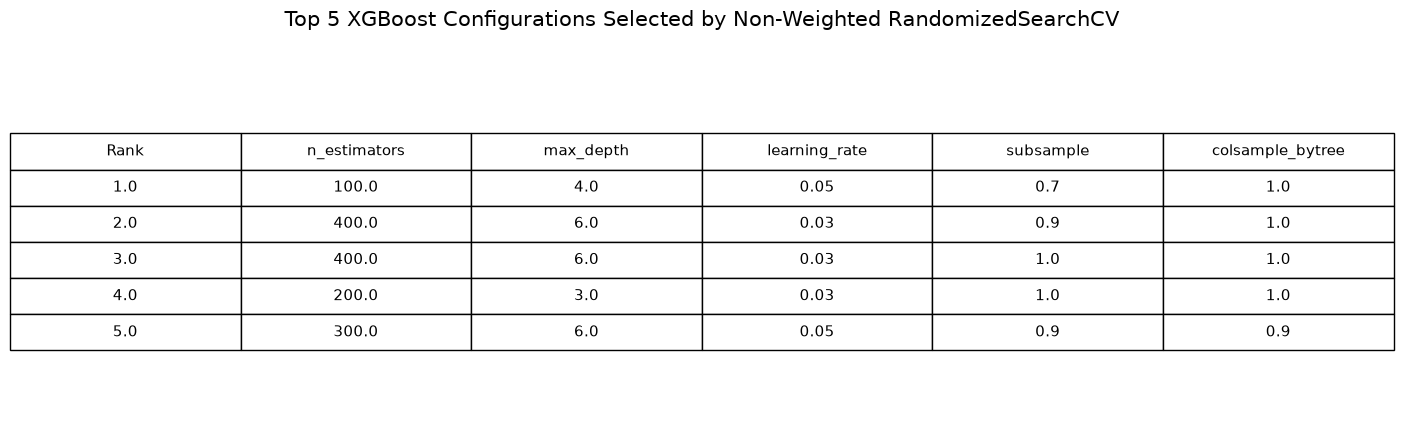


Class distribution in training data:
target
0    458814
1     17355
Name: count, dtype: int64

Mean sample weight:
1.0000000000000002

Unique sample weights:
[ 0.51891289 13.71849611]

Evaluating the SAME 5 models...

Model 1/5
{'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.7, 'colsample_bytree': 1.0}
Non-weighted AP: 0.06332
Weighted AP:     0.06222

Model 2/5
{'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.03, 'subsample': 0.9, 'colsample_bytree': 1.0}
Non-weighted AP: 0.06161
Weighted AP:     0.06029

Model 3/5
{'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.03, 'subsample': 1.0, 'colsample_bytree': 1.0}
Non-weighted AP: 0.06096
Weighted AP:     0.05923

Model 4/5
{'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03, 'subsample': 1.0, 'colsample_bytree': 1.0}
Non-weighted AP: 0.06395
Weighted AP:     0.06331

Model 5/5
{'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9}
Non-wei

,Rank,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,NonWeighted_AP,NonWeighted_AP_std,NonWeighted_ROC_AUC,NonWeighted_ROC_AUC_std,Weighted_AP,Weighted_AP_std,Weighted_ROC_AUC,Weighted_ROC_AUC_std,Delta_AP,Delta_ROC_AUC
0,1,100,4,0.05,0.7,1.0,0.06332,0.00139,0.62860,0.00416,0.06222,0.00162,0.62647,0.00388,-0.00110,-0.00213
1,2,400,6,0.03,0.9,1.0,0.06161,0.00110,0.62411,0.00498,0.06029,0.00123,0.61444,0.00300,-0.00132,-0.00968
2,3,400,6,0.03,1.0,1.0,0.06096,0.00154,0.62115,0.00448,0.05923,0.00130,0.61014,0.00370,-0.00173,-0.01101
3,4,200,3,0.03,1.0,1.0,0.06395,0.00209,0.63017,0.00421,0.06331,0.00181,0.62891,0.00490,-0.00064,-0.00126
4,5,300,6,0.05,0.9,0.9,0.06094,0.00159,0.62207,0.00373,0.05956,0.00104,0.61226,0.00182,-0.00138,-0.00980


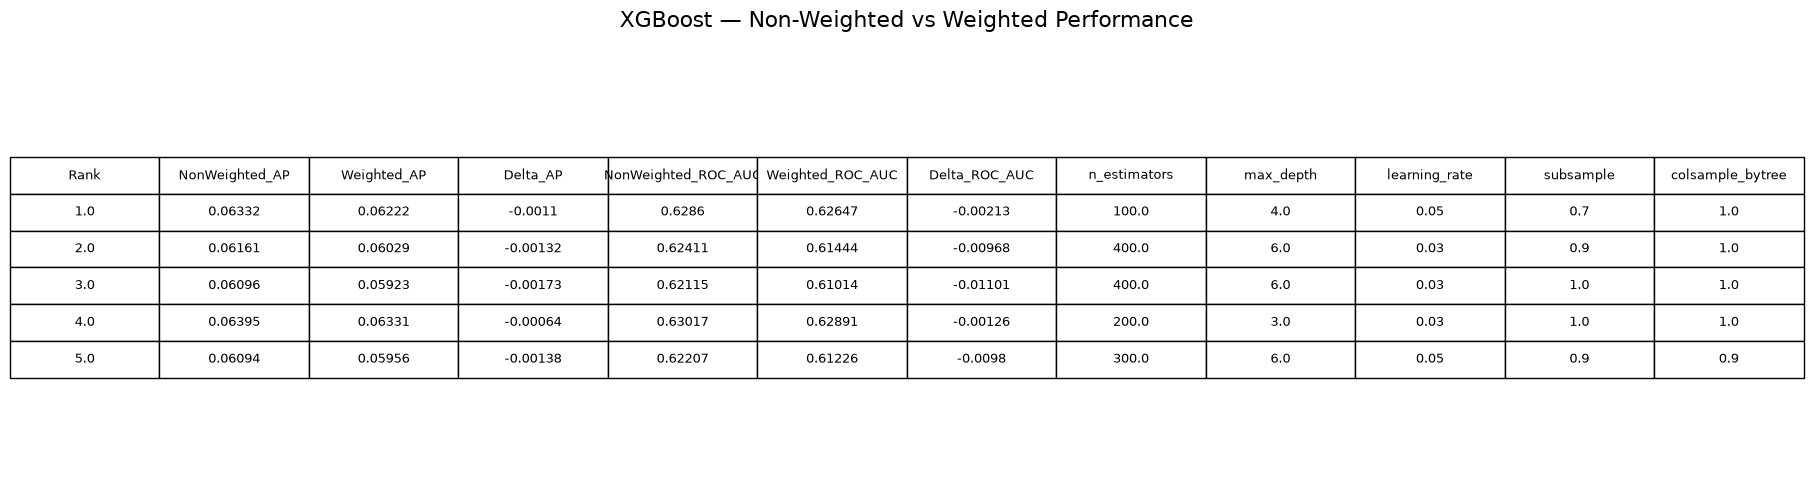

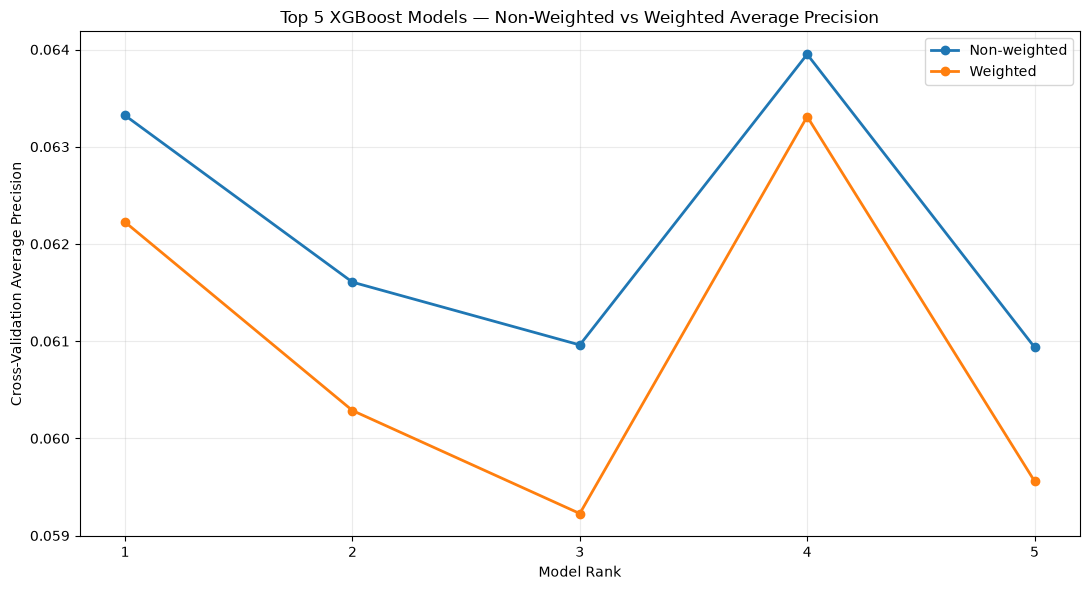

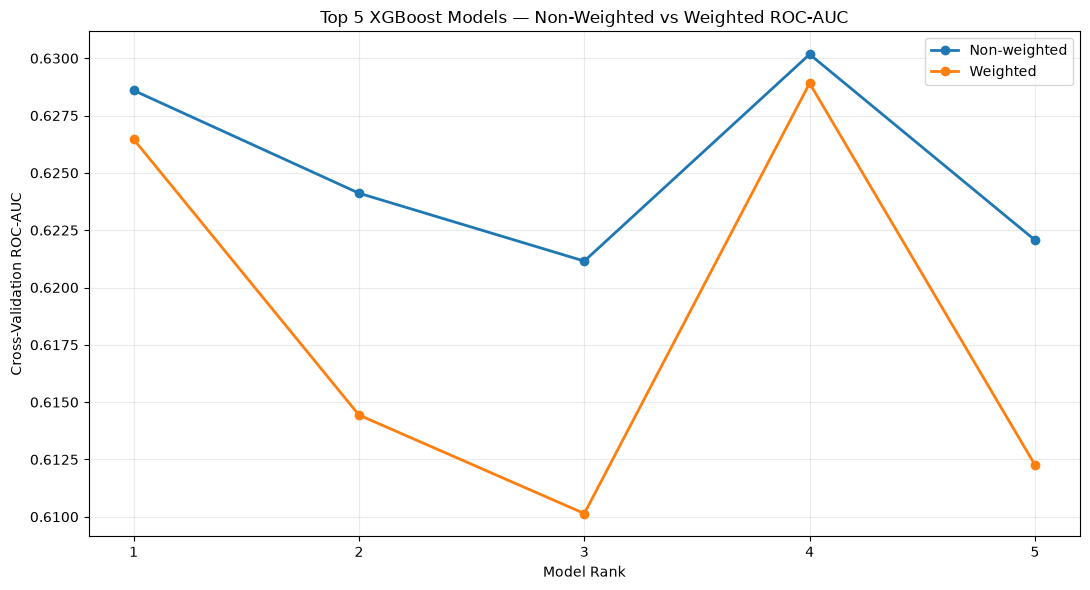

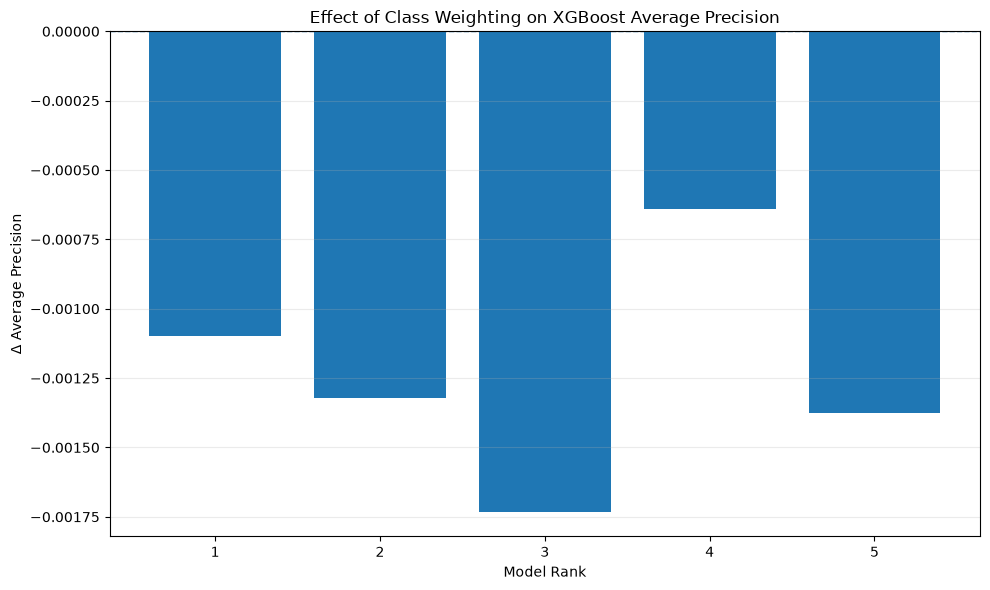

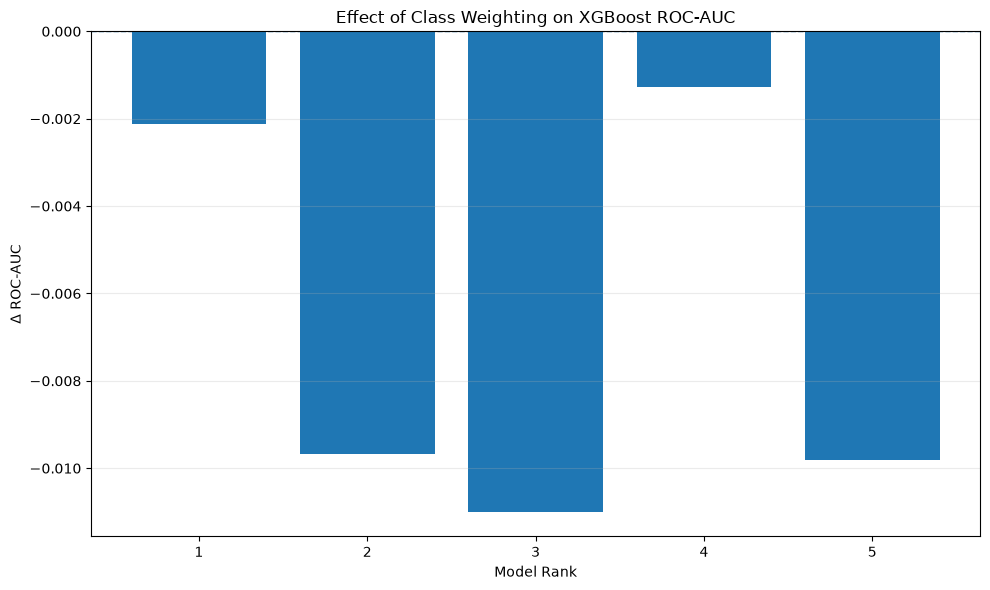


BEST WEIGHTED MODEL
Rank: 4

Hyperparameters:
n_estimators: 200
max_depth: 3
learning_rate: 0.03
subsample: 1.0
colsample_bytree: 1.0

Weighted CV AP: 0.06331
Weighted CV ROC-AUC: 0.62891

TEST SET PERFORMANCE
Average Precision : 0.06412
ROC-AUC           : 0.63298
Precision         : 0.05374
Recall            : 0.55013
F1-score          : 0.09792


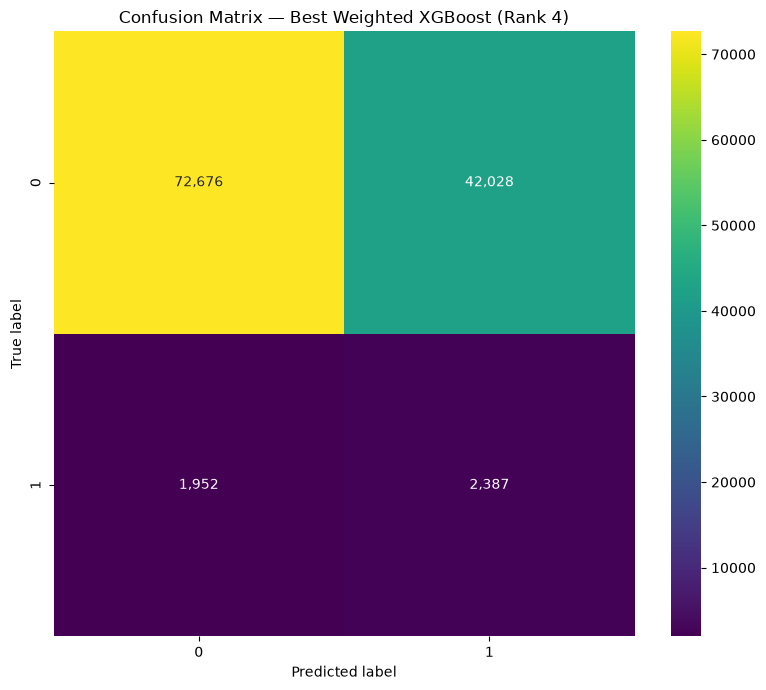

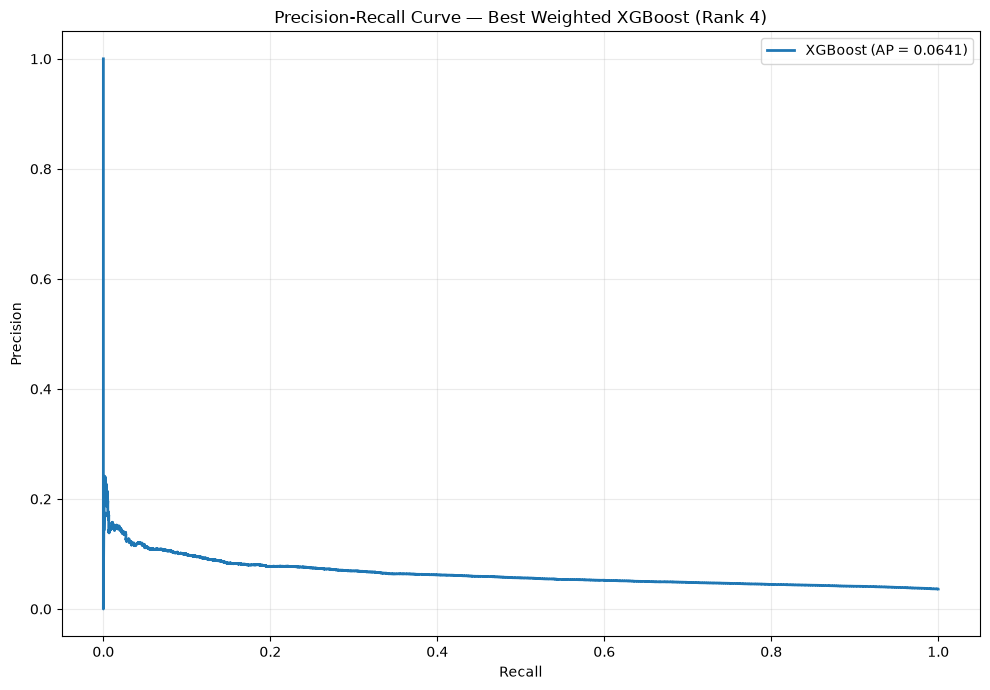

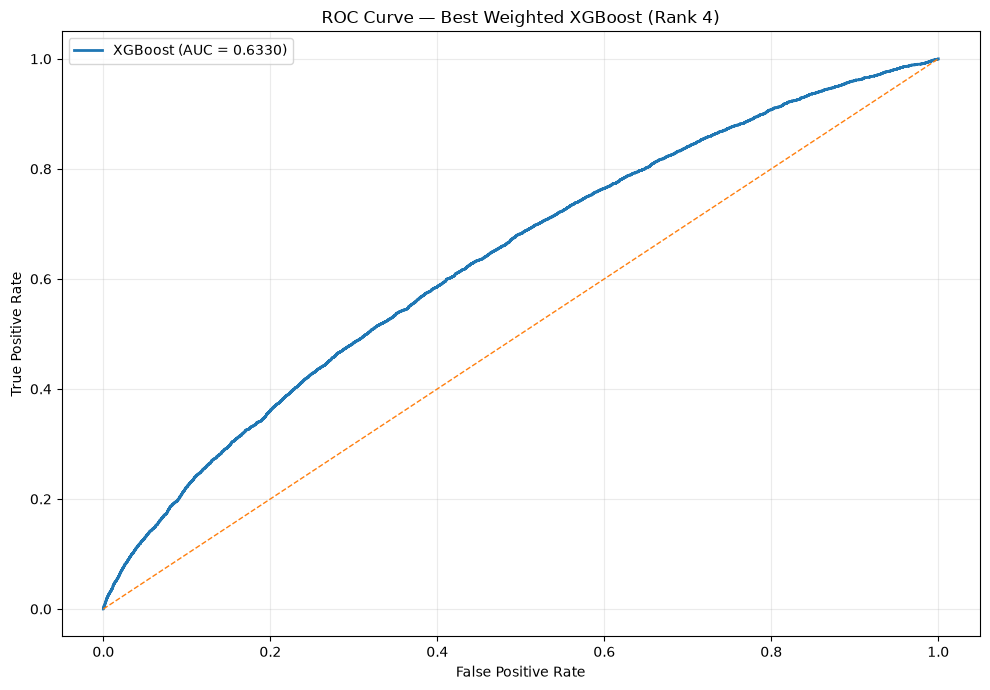

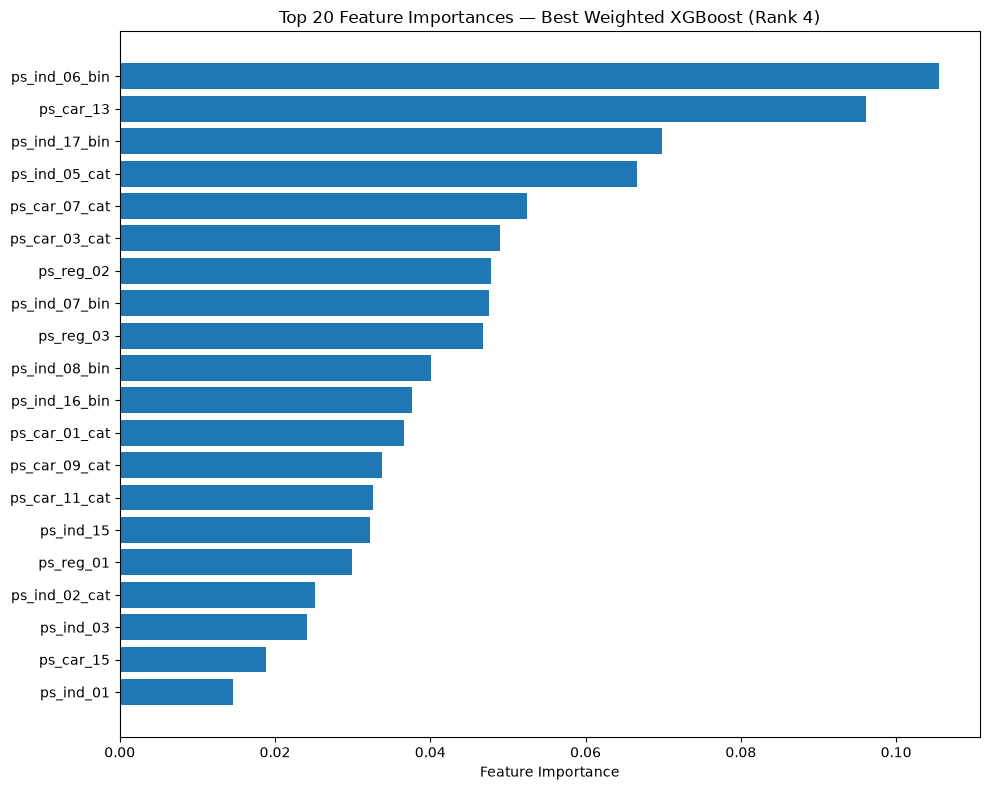


WEIGHTED XGBOOST ANALYSIS COMPLETE

Output folder:
c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\xgboost_weighted_results

Saved:
✓ Top 5 configurations — CSV
✓ Top 5 configurations — PNG
✓ Weighted vs non-weighted comparison — CSV
✓ Weighted vs non-weighted comparison — PNG
✓ AP comparison plot
✓ ROC-AUC comparison plot
✓ Effect of weighting on AP
✓ Effect of weighting on ROC-AUC
✓ Best weighted XGBoost model — JOBLIB
✓ Test predictions/probabilities — CSV
✓ Test metrics — CSV
✓ Confusion matrix — PNG
✓ Precision-Recall curve — PNG
✓ ROC curve — PNG
✓ Top 20 feature importance — PNG
✓ Full feature importance — CSV
✓ OOF predictions — CSV


In [12]:
# ============================================================
# WEIGHTED XGBOOST
# Re-use the SAME top 5 models from the non-weighted search
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.utils.class_weight import compute_sample_weight


# ============================================================
# 1. OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = "xgboost_weighted_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Results will be saved in: {OUTPUT_DIR}")


# ============================================================
# 2. GET THE SAME TOP 5 CONFIGURATIONS
#    FROM THE NON-WEIGHTED RANDOMIZED SEARCH
# ============================================================

# IMPORTANT:
# Replace "random_search" below if your RandomizedSearchCV
# object has another name.

cv_results = pd.DataFrame(random_search.cv_results_)

# Sort according to the non-weighted CV Average Precision
cv_results = cv_results.sort_values(
    by="mean_test_score",
    ascending=False
).reset_index(drop=True)

top5 = cv_results.head(5).copy()


# Extract hyperparameters
top5_params = []

for i, row in top5.iterrows():

    params = {
        "n_estimators": int(row["param_n_estimators"]),
        "max_depth": int(row["param_max_depth"]),
        "learning_rate": float(row["param_learning_rate"]),
        "subsample": float(row["param_subsample"]),
        "colsample_bytree": float(row["param_colsample_bytree"])
    }

    top5_params.append(params)


# Display the five configurations
top5_config_table = pd.DataFrame(top5_params)

top5_config_table.insert(
    0,
    "Rank",
    range(1, len(top5_config_table) + 1)
)

print("\nTop 5 NON-WEIGHTED configurations:")
display(top5_config_table)


# ============================================================
# 3. SAVE TOP 5 CONFIGURATIONS AS CSV
# ============================================================

top5_config_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "top5_xgboost_configurations.csv"
    ),
    index=False
)


# ============================================================
# 4. SAVE TOP 5 CONFIGURATIONS AS IMAGE
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 4.5)
)

ax.axis("off")

table = ax.table(
    cellText=top5_config_table.round(4).values,
    colLabels=top5_config_table.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.0)

ax.set_title(
    "Top 5 XGBoost Configurations Selected by Non-Weighted RandomizedSearchCV",
    fontsize=15,
    pad=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "top5_xgboost_configurations.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 5. CLASS WEIGHTS
# ============================================================

# Balanced sample weights.
#
# IMPORTANT:
# These weights are calculated from the TRAINING DATA only.
# This avoids using information from the test set.

sample_weights_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

print("\nClass distribution in training data:")
print(pd.Series(y_train).value_counts())

print("\nMean sample weight:")
print(sample_weights_train.mean())

print("\nUnique sample weights:")
print(np.unique(sample_weights_train))


# ============================================================
# 6. STRATIFIED CV
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 7. FUNCTION TO EVALUATE ONE MODEL
# ============================================================

def evaluate_xgboost_model(params, weighted=False):

    fold_ap = []
    fold_roc_auc = []

    oof_predictions = np.zeros(len(y_train))

    y_train_array = np.asarray(y_train)

    for fold, (train_idx, valid_idx) in enumerate(
        cv.split(X_train, y_train_array),
        start=1
    ):

        # ----------------------------------------------------
        # Split fold
        # ----------------------------------------------------

        X_fold_train = X_train.iloc[train_idx]
        X_fold_valid = X_train.iloc[valid_idx]

        y_fold_train = y_train_array[train_idx]
        y_fold_valid = y_train_array[valid_idx]

        # ----------------------------------------------------
        # Create model
        # ----------------------------------------------------

        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
            **params
        )

        # ----------------------------------------------------
        # Sample weights
        # ----------------------------------------------------

        if weighted:

            fold_weights = compute_sample_weight(
                class_weight="balanced",
                y=y_fold_train
            )

            model.fit(
                X_fold_train,
                y_fold_train,
                sample_weight=fold_weights
            )

        else:

            model.fit(
                X_fold_train,
                y_fold_train
            )

        # ----------------------------------------------------
        # Validation probabilities
        # ----------------------------------------------------

        valid_proba = model.predict_proba(
            X_fold_valid
        )[:, 1]

        oof_predictions[valid_idx] = valid_proba

        # ----------------------------------------------------
        # Fold metrics
        # ----------------------------------------------------

        fold_ap.append(
            average_precision_score(
                y_fold_valid,
                valid_proba
            )
        )

        fold_roc_auc.append(
            roc_auc_score(
                y_fold_valid,
                valid_proba
            )
        )

    return {
        "AP_mean": np.mean(fold_ap),
        "AP_std": np.std(fold_ap),
        "ROC_AUC_mean": np.mean(fold_roc_auc),
        "ROC_AUC_std": np.std(fold_roc_auc),
        "OOF_predictions": oof_predictions
    }


# ============================================================
# 8. EVALUATE THE SAME 5 MODELS
#    BOTH NON-WEIGHTED AND WEIGHTED
# ============================================================

results = []

oof_predictions_dict = {}

print("\nEvaluating the SAME 5 models...")
print("=" * 70)

for rank, params in enumerate(top5_params, start=1):

    print(f"\nModel {rank}/5")
    print(params)

    # --------------------------------------------------------
    # NON-WEIGHTED
    # --------------------------------------------------------

    nonweighted = evaluate_xgboost_model(
        params,
        weighted=False
    )

    # --------------------------------------------------------
    # WEIGHTED
    # --------------------------------------------------------

    weighted = evaluate_xgboost_model(
        params,
        weighted=True
    )

    # --------------------------------------------------------
    # Save results
    # --------------------------------------------------------

    results.append({

        "Rank": rank,

        # Hyperparameters
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "learning_rate": params["learning_rate"],
        "subsample": params["subsample"],
        "colsample_bytree": params["colsample_bytree"],

        # Non-weighted
        "NonWeighted_AP": nonweighted["AP_mean"],
        "NonWeighted_AP_std": nonweighted["AP_std"],
        "NonWeighted_ROC_AUC": nonweighted["ROC_AUC_mean"],
        "NonWeighted_ROC_AUC_std": nonweighted["ROC_AUC_std"],

        # Weighted
        "Weighted_AP": weighted["AP_mean"],
        "Weighted_AP_std": weighted["AP_std"],
        "Weighted_ROC_AUC": weighted["ROC_AUC_mean"],
        "Weighted_ROC_AUC_std": weighted["ROC_AUC_std"],

        # Difference
        "Delta_AP": (
            weighted["AP_mean"]
            - nonweighted["AP_mean"]
        ),

        "Delta_ROC_AUC": (
            weighted["ROC_AUC_mean"]
            - nonweighted["ROC_AUC_mean"]
        )
    })

    oof_predictions_dict[
        f"model_{rank}_nonweighted"
    ] = nonweighted["OOF_predictions"]

    oof_predictions_dict[
        f"model_{rank}_weighted"
    ] = weighted["OOF_predictions"]

    print(
        f"Non-weighted AP: "
        f"{nonweighted['AP_mean']:.5f}"
    )

    print(
        f"Weighted AP:     "
        f"{weighted['AP_mean']:.5f}"
    )


# ============================================================
# 9. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

print("\nFINAL COMPARISON")
display(
    results_df.round(5)
)


# ============================================================
# 10. SAVE COMPLETE RESULTS
# ============================================================

results_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "xgboost_weighted_vs_nonweighted_comparison.csv"
    ),
    index=False
)


# ============================================================
# 11. SAVE RESULTS TABLE AS IMAGE
# ============================================================

display_columns = [
    "Rank",
    "NonWeighted_AP",
    "Weighted_AP",
    "Delta_AP",
    "NonWeighted_ROC_AUC",
    "Weighted_ROC_AUC",
    "Delta_ROC_AUC",
    "n_estimators",
    "max_depth",
    "learning_rate",
    "subsample",
    "colsample_bytree"
]

table_df = results_df[display_columns].copy()

fig, ax = plt.subplots(
    figsize=(18, 5)
)

ax.axis("off")

table = ax.table(
    cellText=table_df.round(5).values,
    colLabels=table_df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 2.0)

ax.set_title(
    "XGBoost — Non-Weighted vs Weighted Performance",
    fontsize=16,
    pad=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "xgboost_weighted_vs_nonweighted_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 12. GRAPH — AP COMPARISON
# ============================================================

x = results_df["Rank"]

plt.figure(figsize=(11, 6))

plt.plot(
    x,
    results_df["NonWeighted_AP"],
    marker="o",
    linewidth=2,
    label="Non-weighted"
)

plt.plot(
    x,
    results_df["Weighted_AP"],
    marker="o",
    linewidth=2,
    label="Weighted"
)

plt.xlabel("Model Rank")
plt.ylabel("Cross-Validation Average Precision")

plt.title(
    "Top 5 XGBoost Models — Non-Weighted vs Weighted Average Precision"
)

plt.xticks(x)
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "top5_nonweighted_vs_weighted_AP.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 13. GRAPH — ROC-AUC COMPARISON
# ============================================================

plt.figure(figsize=(11, 6))

plt.plot(
    x,
    results_df["NonWeighted_ROC_AUC"],
    marker="o",
    linewidth=2,
    label="Non-weighted"
)

plt.plot(
    x,
    results_df["Weighted_ROC_AUC"],
    marker="o",
    linewidth=2,
    label="Weighted"
)

plt.xlabel("Model Rank")
plt.ylabel("Cross-Validation ROC-AUC")

plt.title(
    "Top 5 XGBoost Models — Non-Weighted vs Weighted ROC-AUC"
)

plt.xticks(x)
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "top5_nonweighted_vs_weighted_ROC_AUC.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 14. GRAPH — EFFECT OF WEIGHTING ON AP
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    x,
    results_df["Delta_AP"]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Model Rank")
plt.ylabel("Δ Average Precision")

plt.title(
    "Effect of Class Weighting on XGBoost Average Precision"
)

plt.xticks(x)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "effect_of_weighting_on_AP.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 15. GRAPH — EFFECT OF WEIGHTING ON ROC-AUC
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    x,
    results_df["Delta_ROC_AUC"]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Model Rank")
plt.ylabel("Δ ROC-AUC")

plt.title(
    "Effect of Class Weighting on XGBoost ROC-AUC"
)

plt.xticks(x)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "effect_of_weighting_on_ROC_AUC.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 16. IDENTIFY BEST WEIGHTED MODEL
# ============================================================

best_idx = results_df[
    "Weighted_AP"
].idxmax()

best_rank = int(
    results_df.loc[best_idx, "Rank"]
)

best_params = top5_params[
    best_rank - 1
]

print("\n" + "=" * 70)
print("BEST WEIGHTED MODEL")
print("=" * 70)

print(f"Rank: {best_rank}")

print("\nHyperparameters:")
for key, value in best_params.items():
    print(f"{key}: {value}")

print(
    f"\nWeighted CV AP: "
    f"{results_df.loc[best_idx, 'Weighted_AP']:.5f}"
)

print(
    f"Weighted CV ROC-AUC: "
    f"{results_df.loc[best_idx, 'Weighted_ROC_AUC']:.5f}"
)


# ============================================================
# 17. TRAIN FINAL BEST WEIGHTED MODEL ON FULL TRAINING DATA
# ============================================================

best_weighted_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    **best_params
)

best_weighted_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights_train
)


# ============================================================
# 18. SAVE THE MODEL
# ============================================================

joblib.dump(
    best_weighted_model,
    os.path.join(
        OUTPUT_DIR,
        f"best_weighted_xgboost_rank_{best_rank}.joblib"
    )
)


# ============================================================
# 19. TEST SET PREDICTIONS
# ============================================================

y_test_proba = best_weighted_model.predict_proba(
    X_test
)[:, 1]

# Default threshold = 0.5
y_test_pred = (
    y_test_proba >= 0.5
).astype(int)


# ============================================================
# 20. TEST METRICS
# ============================================================

test_ap = average_precision_score(
    y_test,
    y_test_proba
)

test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

test_precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)

print("\nTEST SET PERFORMANCE")
print("=" * 70)
print(f"Average Precision : {test_ap:.5f}")
print(f"ROC-AUC           : {test_roc_auc:.5f}")
print(f"Precision         : {test_precision:.5f}")
print(f"Recall            : {test_recall:.5f}")
print(f"F1-score          : {test_f1:.5f}")


# ============================================================
# 21. SAVE TEST METRICS
# ============================================================

test_metrics = pd.DataFrame({
    "Metric": [
        "Average Precision",
        "ROC-AUC",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Value": [
        test_ap,
        test_roc_auc,
        test_precision,
        test_recall,
        test_f1
    ]
})

test_metrics.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "best_weighted_xgboost_test_metrics.csv"
    ),
    index=False
)


# ============================================================
# 22. SAVE PREDICTED PROBABILITIES
# ============================================================

predictions_df = pd.DataFrame({
    "y_true": np.asarray(y_test),
    "predicted_probability": y_test_proba,
    "predicted_class": y_test_pred
})

predictions_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "best_weighted_xgboost_test_predictions.csv"
    ),
    index=False
)


# ============================================================
# 23. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(8, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt=",",
    cmap="viridis",
    cbar=True
)

plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.title(
    f"Confusion Matrix — Best Weighted XGBoost (Rank {best_rank})"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "best_weighted_xgboost_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 24. PRECISION-RECALL CURVE
# ============================================================

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_test_proba
)

plt.figure(figsize=(10, 7))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"XGBoost (AP = {test_ap:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    f"Precision-Recall Curve — Best Weighted XGBoost "
    f"(Rank {best_rank})"
)

plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "best_weighted_xgboost_precision_recall_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 25. ROC CURVE
# ============================================================

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_test_proba
)

plt.figure(figsize=(10, 7))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"XGBoost (AUC = {test_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    f"ROC Curve — Best Weighted XGBoost "
    f"(Rank {best_rank})"
)

plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "best_weighted_xgboost_roc_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 26. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_weighted_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

top20_features = feature_importance.head(20)

# Save CSV
feature_importance.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "best_weighted_xgboost_feature_importance.csv"
    ),
    index=False
)


# Save Top 20 as image
plt.figure(figsize=(10, 8))

plt.barh(
    top20_features["Feature"][::-1],
    top20_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")

plt.title(
    f"Top 20 Feature Importances — "
    f"Best Weighted XGBoost (Rank {best_rank})"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "best_weighted_xgboost_top20_feature_importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 27. SAVE OOF PREDICTIONS
# ============================================================

oof_df = pd.DataFrame(
    oof_predictions_dict
)

oof_df["y_true"] = np.asarray(y_train)

oof_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "xgboost_oof_predictions_weighted_vs_nonweighted.csv"
    ),
    index=False
)


# ============================================================
# 28. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("WEIGHTED XGBOOST ANALYSIS COMPLETE")
print("=" * 70)

print(f"\nOutput folder:")
print(os.path.abspath(OUTPUT_DIR))

print("\nSaved:")
print("✓ Top 5 configurations — CSV")
print("✓ Top 5 configurations — PNG")
print("✓ Weighted vs non-weighted comparison — CSV")
print("✓ Weighted vs non-weighted comparison — PNG")
print("✓ AP comparison plot")
print("✓ ROC-AUC comparison plot")
print("✓ Effect of weighting on AP")
print("✓ Effect of weighting on ROC-AUC")
print("✓ Best weighted XGBoost model — JOBLIB")
print("✓ Test predictions/probabilities — CSV")
print("✓ Test metrics — CSV")
print("✓ Confusion matrix — PNG")
print("✓ Precision-Recall curve — PNG")
print("✓ ROC curve — PNG")
print("✓ Top 20 feature importance — PNG")
print("✓ Full feature importance — CSV")
print("✓ OOF predictions — CSV")

CONTROLLED WEIGHTED XGBOOST EXPERIMENT

Training data found.
Processed training shape: (476169, 235)
Target shape: (476169,)

RandomizedSearch files found in:
c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\XGBoost_RandomizedSearch_OpenML_42742

Loaded CV folds:
Number of folds = 3
Fold 1: 317,446 train | 158,723 validation
Fold 2: 317,446 train | 158,723 validation
Fold 3: 317,446 train | 158,723 validation

Loaded Top 5 configurations.
All 9 original hyperparameters are available for all 5 models.

Exact configurations recovered from the non-weighted search:


,Rank,NonWeighted_CV_AP,NonWeighted_AP_Std,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,gamma,reg_alpha,reg_lambda
0,1,0.065171,0.001400,100,4,0.05,0.7,1.0,1,0.3,0.10,2
1,2,0.064726,0.000546,400,6,0.03,0.9,1.0,5,0.1,0.10,1
2,3,0.064484,0.001243,400,6,0.03,1.0,1.0,5,0.0,0.00,5
3,4,0.064430,0.001415,200,3,0.03,1.0,1.0,1,0.1,0.10,5
4,5,0.064397,0.000931,300,6,0.05,0.9,0.9,10,0.1,0.01,2


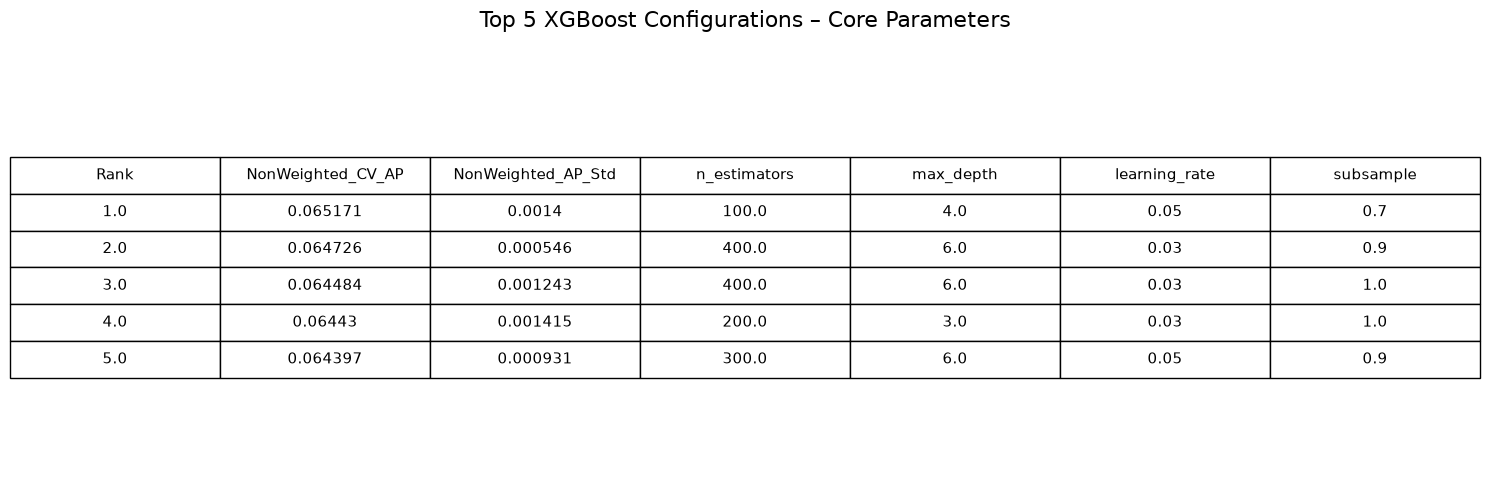

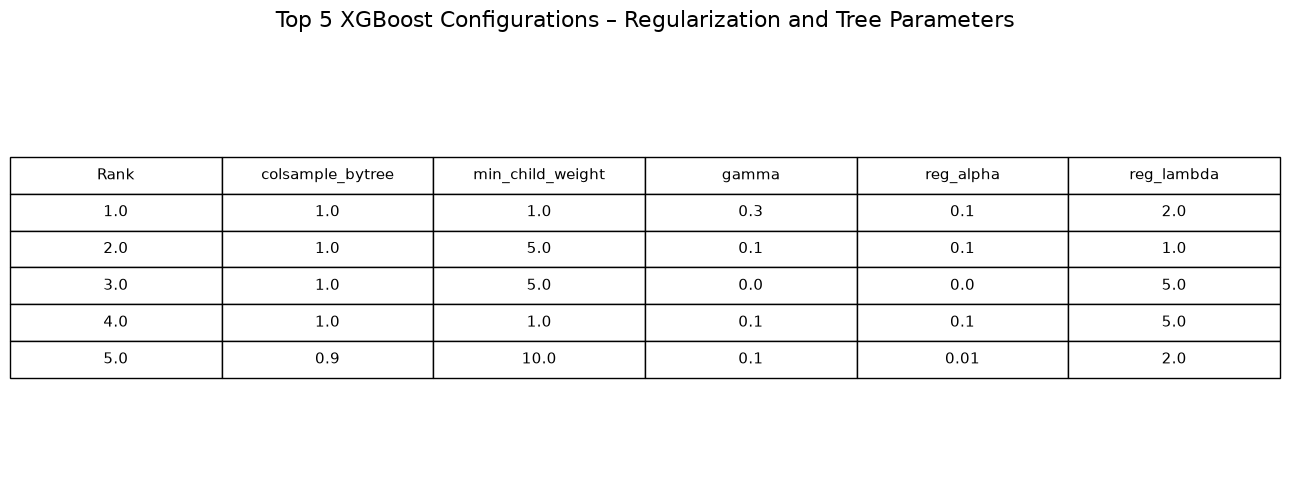


STARTING THE 15 WEIGHTED XGBOOST FITS

----------------------------------------------------------------------
MODEL RANK 1
----------------------------------------------------------------------
Exact original parameters:
  n_estimators: 100
  max_depth: 4
  learning_rate: 0.05
  subsample: 0.7
  colsample_bytree: 1.0
  min_child_weight: 1.0
  gamma: 0.3
  reg_alpha: 0.1
  reg_lambda: 2.0

Fit 1/15 — Rank 1, Fold 1
  AP      = 0.067243
  ROC-AUC = 0.638386
  Gini    = 0.276771

Fit 2/15 — Rank 1, Fold 2
  AP      = 0.062074
  ROC-AUC = 0.630754
  Gini    = 0.261509

Fit 3/15 — Rank 1, Fold 3
  AP      = 0.064655
  ROC-AUC = 0.636025
  Gini    = 0.272050

Rank 1 weighted CV AP: 0.064657 ± 0.002110
Rank 1 weighted CV ROC-AUC: 0.635055
Rank 1 weighted CV Gini: 0.270110

----------------------------------------------------------------------
MODEL RANK 2
----------------------------------------------------------------------
Exact original parameters:
  n_estimators: 400
  max_depth: 6
  lea

,Rank,NonWeighted_CV_AP,NonWeighted_AP_Std,Weighted_CV_AP,Weighted_AP_Std,Weighted_CV_ROC_AUC,Weighted_ROC_AUC_Std,Weighted_CV_Gini,Weighted_Gini_Std,Delta_AP,Delta_AP_Percent,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,gamma,reg_alpha,reg_lambda
0,1,0.065171,0.001400,0.064657,0.002110,0.635055,0.003190,0.270110,0.006380,-0.000513,-0.787675,100,4,0.05,0.7,1.0,1.0,0.3,0.10,2.0
1,2,0.064726,0.000546,0.062660,0.000676,0.628958,0.001182,0.257917,0.002363,-0.002066,-3.192497,400,6,0.03,0.9,1.0,5.0,0.1,0.10,1.0
2,3,0.064484,0.001243,0.062802,0.000754,0.628635,0.001636,0.257270,0.003272,-0.001682,-2.608890,400,6,0.03,1.0,1.0,5.0,0.0,0.00,5.0
3,4,0.064430,0.001415,0.063935,0.001446,0.633923,0.002660,0.267846,0.005319,-0.000495,-0.767711,200,3,0.03,1.0,1.0,1.0,0.1,0.10,5.0
4,5,0.064397,0.000931,0.062406,0.000592,0.628998,0.001800,0.257996,0.003600,-0.001990,-3.090584,300,6,0.05,0.9,0.9,10.0,0.1,0.01,2.0


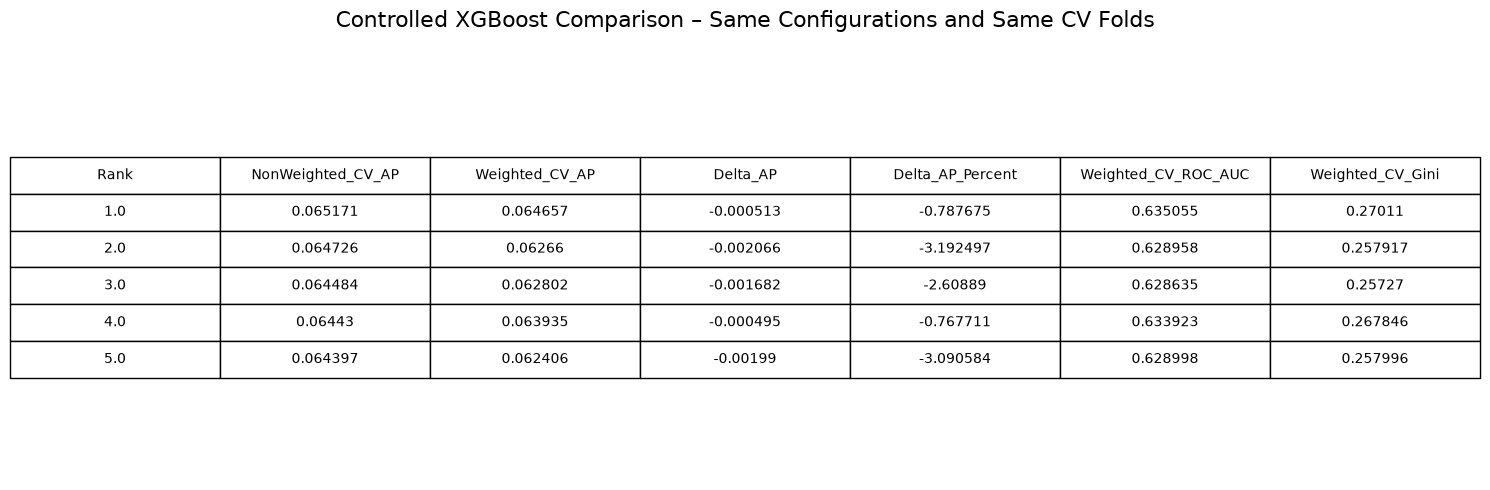

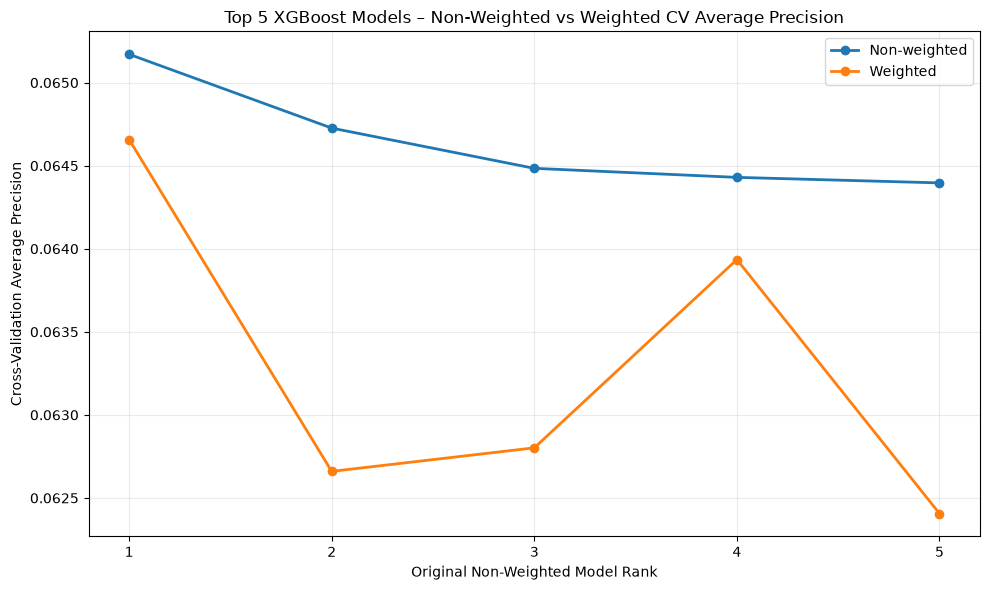

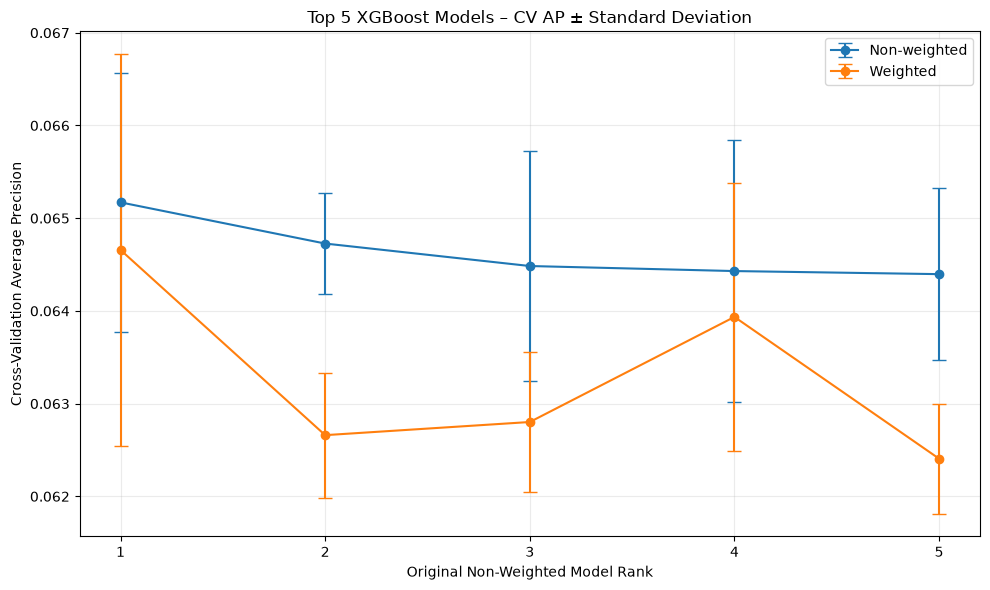

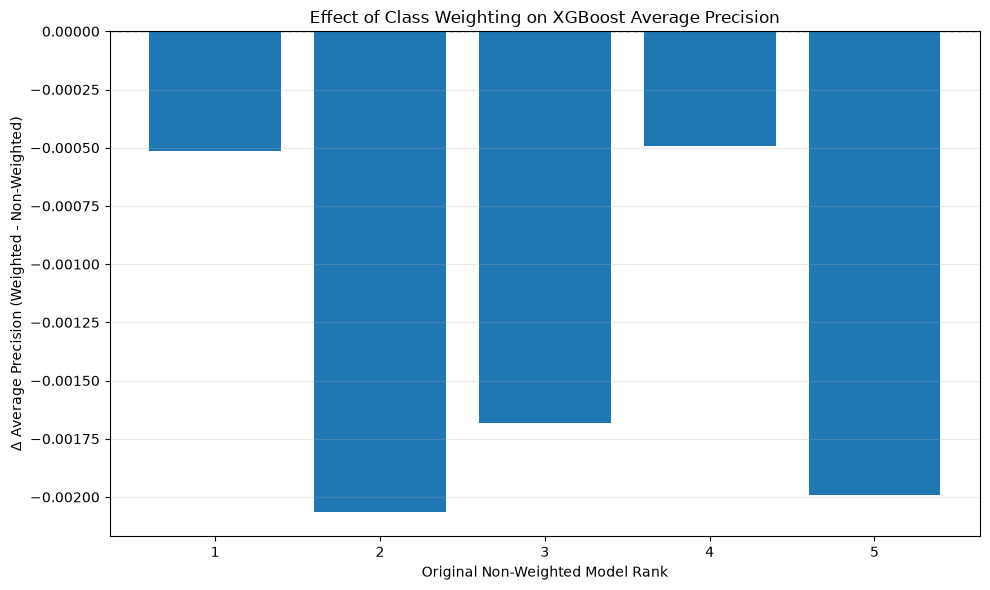

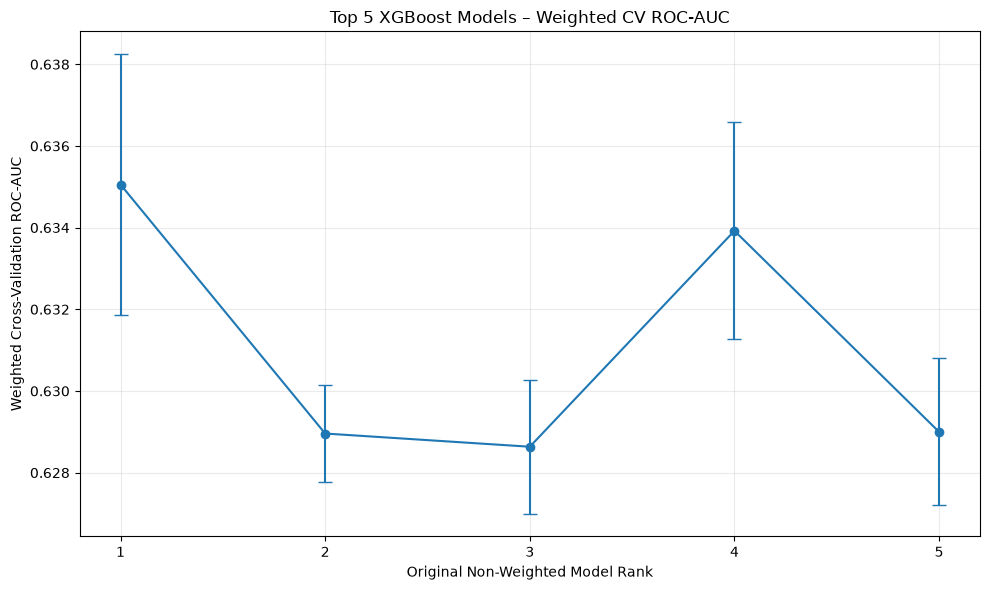

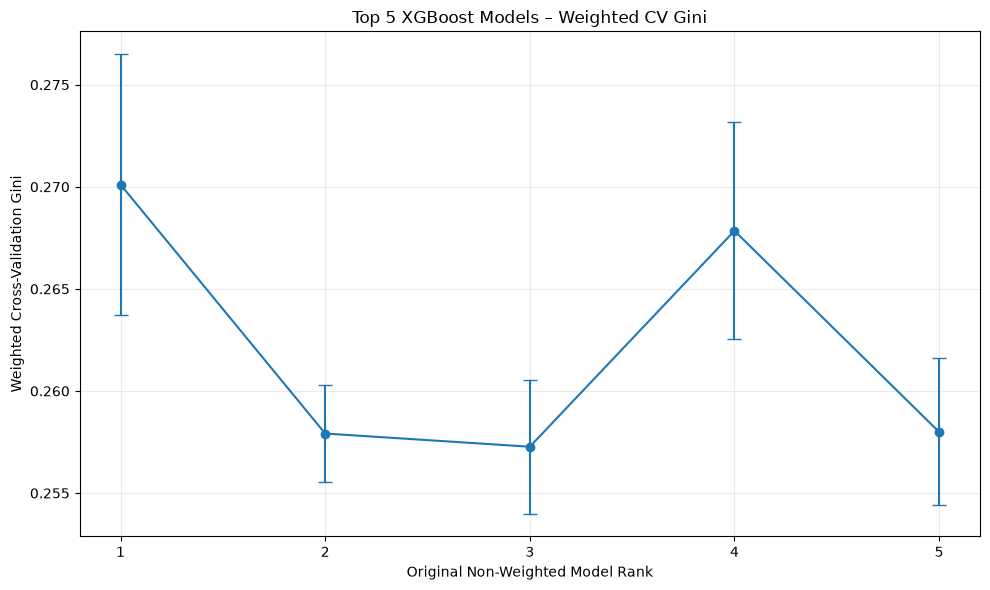


BEST WEIGHTED CONFIGURATION
Original non-weighted rank: 1
Weighted CV AP: 0.064657
Weighted CV ROC-AUC: 0.635055
Weighted CV Gini: 0.270110


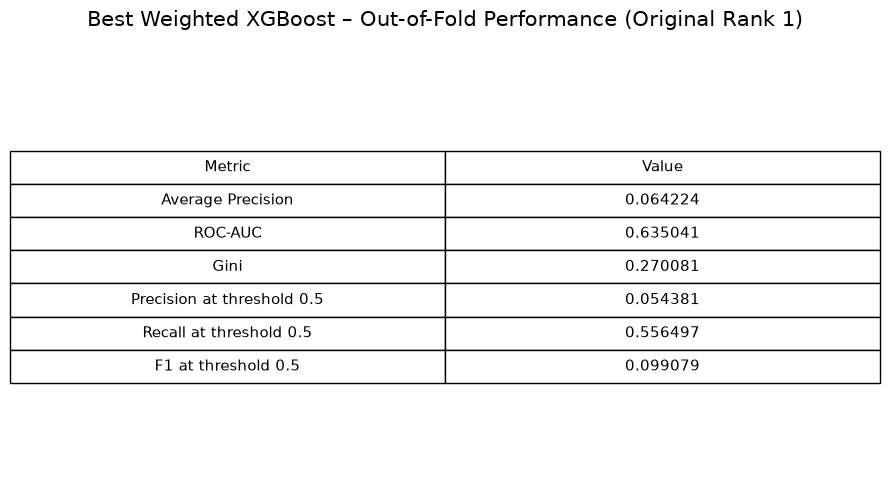

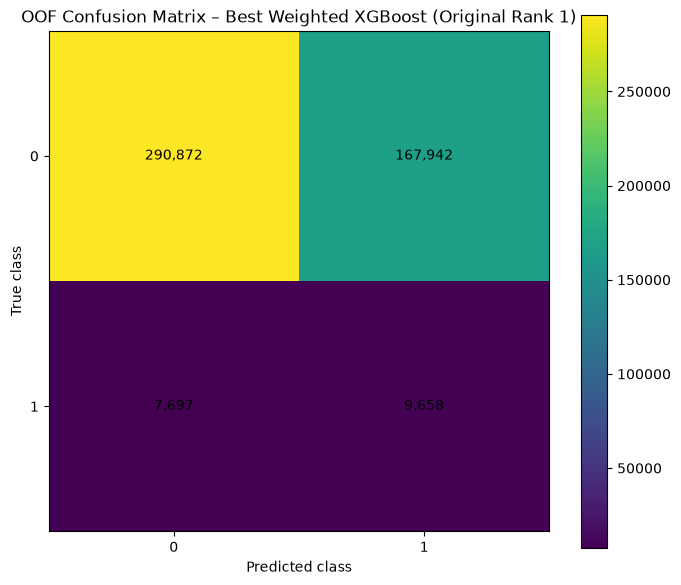

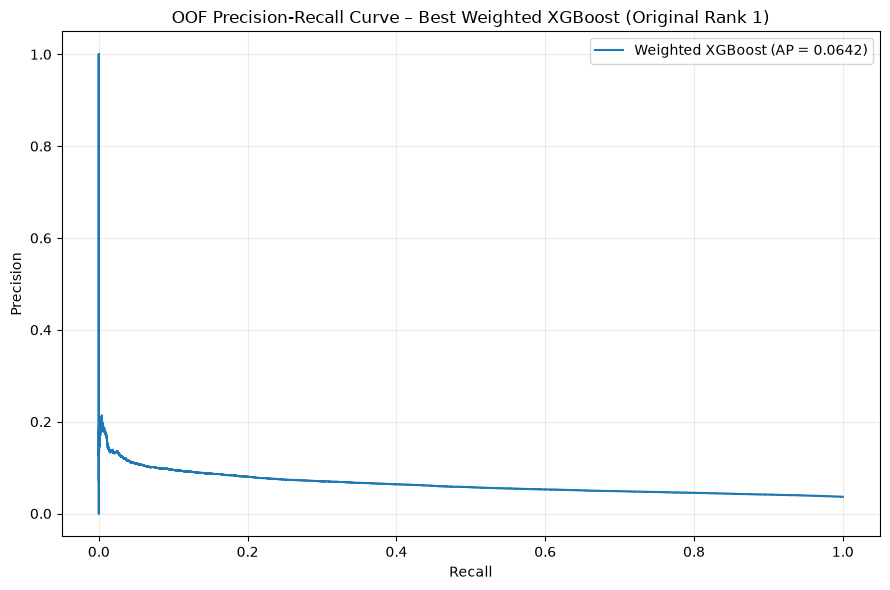

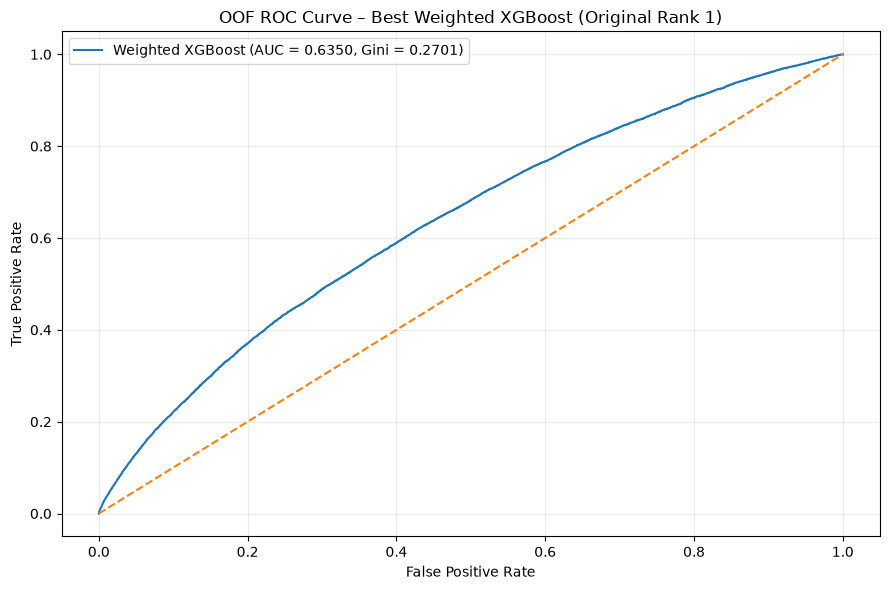


CONTROLLED WEIGHTED EXPERIMENT COMPLETED

Total fits performed: 15

The experiment used:
✓ The exact same 5 XGBoost configurations
✓ All 9 original tuned hyperparameters
✓ The exact same 3 CV folds
✓ Training data only
✓ No test-set evaluation
✓ Only class weighting was changed

Best weighted configuration: original Rank 1

Results saved in:
c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\XGBoost_Weighted_Controlled_Experiment


In [13]:
# ============================================================
# CONTROLLED WEIGHTED XGBOOST EXPERIMENT
# EXACT SAME TOP 5 CONFIGURATIONS + EXACT SAME 3 CV FOLDS
# ============================================================
#
# Objective:
# Evaluate the effect of class weighting on EXACTLY the same
# five XGBoost configurations selected by the non-weighted
# RandomizedSearchCV.
#
# IMPORTANT:
# - NO new RandomizedSearchCV
# - NO new CV folds
# - NO retraining of non-weighted models
# - NO test-set evaluation
# - Exactly 5 models × 3 folds = 15 XGBoost fits
#
# The ONLY experimental change is class weighting.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import json
import pickle
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve
)


# ============================================================
# 1. OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = "XGBoost_Weighted_Controlled_Experiment"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("=" * 80)
print("CONTROLLED WEIGHTED XGBOOST EXPERIMENT")
print("=" * 80)


# ============================================================
# 2. CHECK REQUIRED TRAINING VARIABLES
# ============================================================

required_variables = [
    "X_train_processed",
    "y_train"
]

missing_variables = [
    var
    for var in required_variables
    if var not in globals()
]

if missing_variables:

    raise NameError(
        "Missing required variables: "
        + ", ".join(missing_variables)
        + "\nPlease execute the preprocessing / RandomizedSearch "
          "cells first."
    )


y_train_array = np.asarray(
    y_train
).astype(int)

print("\nTraining data found.")

print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Target shape:",
    y_train_array.shape
)


# ============================================================
# 3. LOCATE SAVED NON-WEIGHTED RANDOMIZED SEARCH FILES
# ============================================================
#
# Two directory names were used during the project.
# We automatically detect the correct one.
# ============================================================

candidate_directories = [
    "XGBoost_RandomizedSearch_OpenML_42742",
    "XGBoost_RandomizedSearch"
]

randomized_dir = None

for directory in candidate_directories:

    folds_candidate = os.path.join(
        directory,
        "cv_folds.pkl"
    )

    params_candidate = os.path.join(
        directory,
        "top5_models_parameters.json"
    )

    if (
        os.path.exists(folds_candidate)
        and
        os.path.exists(params_candidate)
    ):

        randomized_dir = directory
        break


if randomized_dir is None:

    raise FileNotFoundError(
        "Could not find both 'cv_folds.pkl' and "
        "'top5_models_parameters.json'.\n"
        "Check the RandomizedSearch output folder."
    )


print(
    f"\nRandomizedSearch files found in:\n"
    f"{os.path.abspath(randomized_dir)}"
)


# ============================================================
# 4. LOAD THE EXACT SAME 3 CV FOLDS
# ============================================================

folds_path = os.path.join(
    randomized_dir,
    "cv_folds.pkl"
)

with open(
    folds_path,
    "rb"
) as f:

    cv_splits = pickle.load(f)


print("\nLoaded CV folds:")

print(
    f"Number of folds = {len(cv_splits)}"
)


# Safety check
if len(cv_splits) != 3:

    raise ValueError(
        f"Expected exactly 3 saved folds, "
        f"but found {len(cv_splits)}."
    )


for fold_number, (train_idx, val_idx) in enumerate(
    cv_splits,
    start=1
):

    print(
        f"Fold {fold_number}: "
        f"{len(train_idx):,} train | "
        f"{len(val_idx):,} validation"
    )


# ============================================================
# 5. LOAD EXACT TOP 5 NON-WEIGHTED CONFIGURATIONS
# ============================================================

parameters_path = os.path.join(
    randomized_dir,
    "top5_models_parameters.json"
)

with open(
    parameters_path,
    "r"
) as f:

    top5_models = json.load(f)


if len(top5_models) != 5:

    raise ValueError(
        f"Expected exactly 5 models, "
        f"but found {len(top5_models)}."
    )


print("\nLoaded Top 5 configurations.")


# ============================================================
# 6. VERIFY ALL 9 HYPERPARAMETERS
# ============================================================

required_hyperparameters = [
    "n_estimators",
    "max_depth",
    "learning_rate",
    "subsample",
    "colsample_bytree",
    "min_child_weight",
    "gamma",
    "reg_alpha",
    "reg_lambda"
]


for model_info in top5_models:

    missing_params = [
        p
        for p in required_hyperparameters
        if p not in model_info["hyperparameters"]
    ]

    if missing_params:

        raise ValueError(
            f"Rank {model_info['rank']} is missing: "
            + ", ".join(missing_params)
        )


print(
    "All 9 original hyperparameters "
    "are available for all 5 models."
)


# ============================================================
# 7. DISPLAY / SAVE THE EXACT FIVE CONFIGURATIONS
# ============================================================

configuration_rows = []

for model_info in top5_models:

    params = model_info["hyperparameters"]

    row = {
        "Rank": model_info["rank"],
        "NonWeighted_CV_AP":
            model_info["cv_average_precision"],
        "NonWeighted_AP_Std":
            model_info["cv_ap_std"]
    }

    for parameter in required_hyperparameters:
        row[parameter] = params[parameter]

    configuration_rows.append(row)


config_df = pd.DataFrame(
    configuration_rows
).sort_values(
    "Rank"
).reset_index(drop=True)


print(
    "\nExact configurations recovered "
    "from the non-weighted search:"
)

display(
    config_df.round(6)
)


config_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "01_exact_top5_nonweighted_configurations.csv"
    ),
    index=False
)


# ============================================================
# 8. CONFIGURATION TABLE AS IMAGE
# ============================================================
#
# Split into two tables so the font remains readable.
# ============================================================

table1_columns = [
    "Rank",
    "NonWeighted_CV_AP",
    "NonWeighted_AP_Std",
    "n_estimators",
    "max_depth",
    "learning_rate",
    "subsample"
]

table1_df = config_df[
    table1_columns
].copy()


fig, ax = plt.subplots(
    figsize=(15, 5)
)

ax.axis("off")

table = ax.table(
    cellText=table1_df.round(6).values,
    colLabels=table1_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.0)

ax.set_title(
    "Top 5 XGBoost Configurations – Core Parameters",
    fontsize=16,
    pad=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "01a_top5_core_parameters.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


table2_columns = [
    "Rank",
    "colsample_bytree",
    "min_child_weight",
    "gamma",
    "reg_alpha",
    "reg_lambda"
]

table2_df = config_df[
    table2_columns
].copy()


fig, ax = plt.subplots(
    figsize=(13, 5)
)

ax.axis("off")

table = ax.table(
    cellText=table2_df.round(6).values,
    colLabels=table2_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.0)

ax.set_title(
    "Top 5 XGBoost Configurations – "
    "Regularization and Tree Parameters",
    fontsize=16,
    pad=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "01b_top5_regularization_parameters.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 9. PREPARE RESULT STORAGE
# ============================================================

weighted_results = []

weighted_oof_predictions = {}

total_fit_counter = 0


# ============================================================
# 10. TRAIN EXACTLY 5 × 3 = 15 WEIGHTED MODELS
# ============================================================

print("\n" + "=" * 80)
print("STARTING THE 15 WEIGHTED XGBOOST FITS")
print("=" * 80)


for model_info in sorted(
    top5_models,
    key=lambda x: x["rank"]
):

    rank = int(
        model_info["rank"]
    )

    params = (
        model_info["hyperparameters"]
        .copy()
    )

    # Convert JSON values explicitly to Python numeric types
    params["n_estimators"] = int(
        params["n_estimators"]
    )

    params["max_depth"] = int(
        params["max_depth"]
    )

    params["learning_rate"] = float(
        params["learning_rate"]
    )

    params["subsample"] = float(
        params["subsample"]
    )

    params["colsample_bytree"] = float(
        params["colsample_bytree"]
    )

    params["min_child_weight"] = float(
        params["min_child_weight"]
    )

    params["gamma"] = float(
        params["gamma"]
    )

    params["reg_alpha"] = float(
        params["reg_alpha"]
    )

    params["reg_lambda"] = float(
        params["reg_lambda"]
    )


    print("\n" + "-" * 70)
    print(f"MODEL RANK {rank}")
    print("-" * 70)

    print("Exact original parameters:")

    for key, value in params.items():
        print(f"  {key}: {value}")


    fold_ap = []
    fold_roc_auc = []
    fold_gini = []

    oof_proba = np.zeros(
        len(y_train_array),
        dtype=float
    )


    # ========================================================
    # SAME SAVED FOLDS AS NON-WEIGHTED RANDOMIZEDSEARCHCV
    # ========================================================

    for fold_number, (
        train_idx,
        valid_idx
    ) in enumerate(
        cv_splits,
        start=1
    ):

        total_fit_counter += 1

        print(
            f"\nFit {total_fit_counter}/15 "
            f"— Rank {rank}, Fold {fold_number}"
        )


        # ----------------------------------------------------
        # Use the EXACT saved fold indices
        # ----------------------------------------------------

        X_fold_train = (
            X_train_processed[
                train_idx
            ]
        )

        X_fold_valid = (
            X_train_processed[
                valid_idx
            ]
        )

        y_fold_train = (
            y_train_array[
                train_idx
            ]
        )

        y_fold_valid = (
            y_train_array[
                valid_idx
            ]
        )


        # ----------------------------------------------------
        # Compute weights ONLY from this fold's training data
        # ----------------------------------------------------

        fold_weights = (
            compute_sample_weight(
                class_weight="balanced",
                y=y_fold_train
            )
        )


        # ----------------------------------------------------
        # EXACT SAME XGBoost configuration
        # ----------------------------------------------------

        weighted_model = XGBClassifier(

            objective="binary:logistic",

            eval_metric="aucpr",

            tree_method="hist",

            random_state=42,

            n_jobs=-1,

            **params
        )


        # ----------------------------------------------------
        # Weighted training
        # ----------------------------------------------------

        weighted_model.fit(
            X_fold_train,
            y_fold_train,
            sample_weight=fold_weights
        )


        # ----------------------------------------------------
        # Validation probabilities
        # ----------------------------------------------------

        valid_proba = (
            weighted_model
            .predict_proba(
                X_fold_valid
            )[:, 1]
        )


        oof_proba[
            valid_idx
        ] = valid_proba


        # ----------------------------------------------------
        # Fold metrics
        # ----------------------------------------------------

        ap = (
            average_precision_score(
                y_fold_valid,
                valid_proba
            )
        )

        auc = (
            roc_auc_score(
                y_fold_valid,
                valid_proba
            )
        )

        gini = (
            2 * auc - 1
        )


        fold_ap.append(ap)

        fold_roc_auc.append(auc)

        fold_gini.append(gini)


        print(
            f"  AP      = {ap:.6f}"
        )

        print(
            f"  ROC-AUC = {auc:.6f}"
        )

        print(
            f"  Gini    = {gini:.6f}"
        )


        # ----------------------------------------------------
        # Save the fitted fold model
        # ----------------------------------------------------
        #
        # This prevents losing these trained models if the
        # kernel is restarted.
        # ----------------------------------------------------

        fold_model_path = os.path.join(
            OUTPUT_DIR,
            f"rank_{rank}_fold_{fold_number}_weighted.joblib"
        )

        joblib.dump(
            weighted_model,
            fold_model_path
        )


    # ========================================================
    # MODEL-LEVEL CV RESULTS
    # ========================================================

    weighted_ap_mean = float(
        np.mean(fold_ap)
    )

    weighted_ap_std = float(
        np.std(fold_ap)
    )

    weighted_auc_mean = float(
        np.mean(fold_roc_auc)
    )

    weighted_auc_std = float(
        np.std(fold_roc_auc)
    )

    weighted_gini_mean = float(
        np.mean(fold_gini)
    )

    weighted_gini_std = float(
        np.std(fold_gini)
    )


    nonweighted_ap = float(
        model_info[
            "cv_average_precision"
        ]
    )


    delta_ap = (
        weighted_ap_mean
        - nonweighted_ap
    )


    delta_ap_percent = (
        delta_ap
        / nonweighted_ap
        * 100
    )


    result_row = {

        "Rank": rank,

        # Original non-weighted result
        "NonWeighted_CV_AP":
            nonweighted_ap,

        "NonWeighted_AP_Std":
            float(
                model_info[
                    "cv_ap_std"
                ]
            ),

        # Weighted results
        "Weighted_CV_AP":
            weighted_ap_mean,

        "Weighted_AP_Std":
            weighted_ap_std,

        "Weighted_CV_ROC_AUC":
            weighted_auc_mean,

        "Weighted_ROC_AUC_Std":
            weighted_auc_std,

        "Weighted_CV_Gini":
            weighted_gini_mean,

        "Weighted_Gini_Std":
            weighted_gini_std,

        # Effect of weighting
        "Delta_AP":
            delta_ap,

        "Delta_AP_Percent":
            delta_ap_percent
    }


    # Add all nine exact hyperparameters
    for parameter in required_hyperparameters:

        result_row[
            parameter
        ] = params[
            parameter
        ]


    weighted_results.append(
        result_row
    )


    weighted_oof_predictions[
        f"Rank_{rank}_Weighted"
    ] = oof_proba


    print(
        f"\nRank {rank} weighted CV AP: "
        f"{weighted_ap_mean:.6f} "
        f"± {weighted_ap_std:.6f}"
    )

    print(
        f"Rank {rank} weighted CV ROC-AUC: "
        f"{weighted_auc_mean:.6f}"
    )

    print(
        f"Rank {rank} weighted CV Gini: "
        f"{weighted_gini_mean:.6f}"
    )


# ============================================================
# 11. VERIFY EXACTLY 15 FITS
# ============================================================

print("\n" + "=" * 80)

print(
    f"TOTAL XGBOOST FITS PERFORMED: "
    f"{total_fit_counter}"
)

if total_fit_counter != 15:

    raise RuntimeError(
        f"Expected exactly 15 fits, "
        f"but {total_fit_counter} were performed."
    )

print(
    "✓ Exactly 15 weighted fits performed."
)


# ============================================================
# 12. CREATE FINAL RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(
    weighted_results
).sort_values(
    "Rank"
).reset_index(drop=True)


print("\nFINAL CONTROLLED COMPARISON:")

display(
    results_df.round(6)
)


results_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "02_controlled_weighted_results.csv"
    ),
    index=False
)


# ============================================================
# 13. SAVE MAIN COMPARISON TABLE AS IMAGE
# ============================================================

comparison_columns = [
    "Rank",
    "NonWeighted_CV_AP",
    "Weighted_CV_AP",
    "Delta_AP",
    "Delta_AP_Percent",
    "Weighted_CV_ROC_AUC",
    "Weighted_CV_Gini"
]

comparison_table = (
    results_df[
        comparison_columns
    ]
    .copy()
)


fig, ax = plt.subplots(
    figsize=(15, 5)
)

ax.axis("off")

table = ax.table(
    cellText=comparison_table.round(6).values,
    colLabels=comparison_table.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.0)

ax.set_title(
    "Controlled XGBoost Comparison – "
    "Same Configurations and Same CV Folds",
    fontsize=16,
    pad=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "02_controlled_weighted_comparison_table.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 14. NON-WEIGHTED VS WEIGHTED AP
# ============================================================

x = results_df[
    "Rank"
]

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    x,
    results_df[
        "NonWeighted_CV_AP"
    ],
    marker="o",
    linewidth=2,
    label="Non-weighted"
)

plt.plot(
    x,
    results_df[
        "Weighted_CV_AP"
    ],
    marker="o",
    linewidth=2,
    label="Weighted"
)

plt.xlabel(
    "Original Non-Weighted Model Rank"
)

plt.ylabel(
    "Cross-Validation Average Precision"
)

plt.title(
    "Top 5 XGBoost Models – "
    "Non-Weighted vs Weighted CV Average Precision"
)

plt.xticks(x)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "03_nonweighted_vs_weighted_AP.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 15. AP WITH STANDARD DEVIATION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.errorbar(
    x,
    results_df[
        "NonWeighted_CV_AP"
    ],
    yerr=results_df[
        "NonWeighted_AP_Std"
    ],
    marker="o",
    capsize=5,
    label="Non-weighted"
)

plt.errorbar(
    x,
    results_df[
        "Weighted_CV_AP"
    ],
    yerr=results_df[
        "Weighted_AP_Std"
    ],
    marker="o",
    capsize=5,
    label="Weighted"
)

plt.xlabel(
    "Original Non-Weighted Model Rank"
)

plt.ylabel(
    "Cross-Validation Average Precision"
)

plt.title(
    "Top 5 XGBoost Models – "
    "CV AP ± Standard Deviation"
)

plt.xticks(x)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "04_AP_with_standard_deviation.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 16. EFFECT OF WEIGHTING ON AP
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    x,
    results_df[
        "Delta_AP"
    ]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Original Non-Weighted Model Rank"
)

plt.ylabel(
    "Δ Average Precision "
    "(Weighted - Non-Weighted)"
)

plt.title(
    "Effect of Class Weighting on XGBoost Average Precision"
)

plt.xticks(x)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "05_effect_of_weighting_on_AP.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 17. WEIGHTED ROC-AUC
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.errorbar(
    x,
    results_df[
        "Weighted_CV_ROC_AUC"
    ],
    yerr=results_df[
        "Weighted_ROC_AUC_Std"
    ],
    marker="o",
    capsize=5
)

plt.xlabel(
    "Original Non-Weighted Model Rank"
)

plt.ylabel(
    "Weighted Cross-Validation ROC-AUC"
)

plt.title(
    "Top 5 XGBoost Models – Weighted CV ROC-AUC"
)

plt.xticks(x)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "06_weighted_ROC_AUC.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 18. WEIGHTED GINI
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.errorbar(
    x,
    results_df[
        "Weighted_CV_Gini"
    ],
    yerr=results_df[
        "Weighted_Gini_Std"
    ],
    marker="o",
    capsize=5
)

plt.xlabel(
    "Original Non-Weighted Model Rank"
)

plt.ylabel(
    "Weighted Cross-Validation Gini"
)

plt.title(
    "Top 5 XGBoost Models – Weighted CV Gini"
)

plt.xticks(x)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "07_weighted_Gini.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 19. IDENTIFY BEST WEIGHTED CONFIGURATION
# ============================================================

best_idx = (
    results_df[
        "Weighted_CV_AP"
    ]
    .idxmax()
)

best_rank = int(
    results_df.loc[
        best_idx,
        "Rank"
    ]
)


print("\n" + "=" * 80)
print("BEST WEIGHTED CONFIGURATION")
print("=" * 80)

print(
    f"Original non-weighted rank: "
    f"{best_rank}"
)

print(
    f"Weighted CV AP: "
    f"{results_df.loc[best_idx, 'Weighted_CV_AP']:.6f}"
)

print(
    f"Weighted CV ROC-AUC: "
    f"{results_df.loc[best_idx, 'Weighted_CV_ROC_AUC']:.6f}"
)

print(
    f"Weighted CV Gini: "
    f"{results_df.loc[best_idx, 'Weighted_CV_Gini']:.6f}"
)


# ============================================================
# 20. OOF METRICS FOR BEST WEIGHTED CONFIGURATION
# ============================================================
#
# No additional training is required.
#
# These predictions were obtained only when each observation
# was in the validation fold.
# ============================================================

best_oof_proba = (
    weighted_oof_predictions[
        f"Rank_{best_rank}_Weighted"
    ]
)

best_oof_pred = (
    best_oof_proba >= 0.5
).astype(int)


best_oof_ap = (
    average_precision_score(
        y_train_array,
        best_oof_proba
    )
)

best_oof_auc = (
    roc_auc_score(
        y_train_array,
        best_oof_proba
    )
)

best_oof_gini = (
    2 * best_oof_auc - 1
)

best_oof_precision = (
    precision_score(
        y_train_array,
        best_oof_pred,
        zero_division=0
    )
)

best_oof_recall = (
    recall_score(
        y_train_array,
        best_oof_pred,
        zero_division=0
    )
)

best_oof_f1 = (
    f1_score(
        y_train_array,
        best_oof_pred,
        zero_division=0
    )
)


# ============================================================
# 21. BEST WEIGHTED OOF METRIC TABLE
# ============================================================

best_metrics_df = pd.DataFrame({

    "Metric": [
        "Average Precision",
        "ROC-AUC",
        "Gini",
        "Precision at threshold 0.5",
        "Recall at threshold 0.5",
        "F1 at threshold 0.5"
    ],

    "Value": [
        best_oof_ap,
        best_oof_auc,
        best_oof_gini,
        best_oof_precision,
        best_oof_recall,
        best_oof_f1
    ]
})


fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.axis("off")

table = ax.table(
    cellText=best_metrics_df.round(6).values,
    colLabels=best_metrics_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)

ax.set_title(
    f"Best Weighted XGBoost – "
    f"Out-of-Fold Performance (Original Rank {best_rank})",
    fontsize=15,
    pad=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "08_best_weighted_OOF_metrics.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 22. BEST WEIGHTED OOF CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_train_array,
    best_oof_pred
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

image = ax.imshow(
    cm
)

for i in range(
    cm.shape[0]
):

    for j in range(
        cm.shape[1]
    ):

        ax.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center"
        )

ax.set_xticks(
    [0, 1]
)

ax.set_yticks(
    [0, 1]
)

ax.set_xlabel(
    "Predicted class"
)

ax.set_ylabel(
    "True class"
)

ax.set_title(
    f"OOF Confusion Matrix – "
    f"Best Weighted XGBoost (Original Rank {best_rank})"
)

plt.colorbar(
    image,
    ax=ax
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "09_best_weighted_OOF_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 23. BEST WEIGHTED OOF PRECISION-RECALL CURVE
# ============================================================

precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y_train_array,
        best_oof_proba
    )
)

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    recall_curve,
    precision_curve,
    label=(
        f"Weighted XGBoost "
        f"(AP = {best_oof_ap:.4f})"
    )
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    f"OOF Precision-Recall Curve – "
    f"Best Weighted XGBoost "
    f"(Original Rank {best_rank})"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "10_best_weighted_OOF_precision_recall_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 24. BEST WEIGHTED OOF ROC CURVE
# ============================================================

fpr, tpr, _ = (
    roc_curve(
        y_train_array,
        best_oof_proba
    )
)

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    fpr,
    tpr,
    label=(
        f"Weighted XGBoost "
        f"(AUC = {best_oof_auc:.4f}, "
        f"Gini = {best_oof_gini:.4f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    f"OOF ROC Curve – "
    f"Best Weighted XGBoost "
    f"(Original Rank {best_rank})"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "11_best_weighted_OOF_ROC_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 25. SAVE ALL WEIGHTED OOF PREDICTIONS
# ============================================================

oof_df = pd.DataFrame(
    weighted_oof_predictions
)

oof_df[
    "y_true"
] = y_train_array


oof_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "12_weighted_OOF_predictions.csv"
    ),
    index=False
)


# ============================================================
# 26. SAVE SUMMARY AS JSON
# ============================================================

summary = {

    "experiment":
        "Controlled class-weighting experiment",

    "number_of_models":
        5,

    "number_of_folds":
        3,

    "total_weighted_fits":
        total_fit_counter,

    "fold_source":
        folds_path,

    "parameter_source":
        parameters_path,

    "best_weighted_original_rank":
        best_rank,

    "best_weighted_cv_ap":
        float(
            results_df.loc[
                best_idx,
                "Weighted_CV_AP"
            ]
        ),

    "best_weighted_cv_roc_auc":
        float(
            results_df.loc[
                best_idx,
                "Weighted_CV_ROC_AUC"
            ]
        ),

    "best_weighted_cv_gini":
        float(
            results_df.loc[
                best_idx,
                "Weighted_CV_Gini"
            ]
        )
}


with open(
    os.path.join(
        OUTPUT_DIR,
        "13_experiment_summary.json"
    ),
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


# ============================================================
# 27. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("CONTROLLED WEIGHTED EXPERIMENT COMPLETED")
print("=" * 80)

print(
    f"\nTotal fits performed: "
    f"{total_fit_counter}"
)

print(
    "\nThe experiment used:"
)

print(
    "✓ The exact same 5 XGBoost configurations"
)

print(
    "✓ All 9 original tuned hyperparameters"
)

print(
    "✓ The exact same 3 CV folds"
)

print(
    "✓ Training data only"
)

print(
    "✓ No test-set evaluation"
)

print(
    "✓ Only class weighting was changed"
)

print(
    f"\nBest weighted configuration: "
    f"original Rank {best_rank}"
)

print(
    f"\nResults saved in:\n"
    f"{os.path.abspath(OUTPUT_DIR)}"
)

In [14]:
# ============================================================
# ADD AP AND ROC-AUC RANKINGS
# ============================================================

results_df["Weighted_AP_Rank"] = (
    results_df["Weighted_CV_AP"]
    .rank(method="min", ascending=False)
    .astype(int)
)

results_df["Weighted_ROC_AUC_Rank"] = (
    results_df["Weighted_CV_ROC_AUC"]
    .rank(method="min", ascending=False)
    .astype(int)
)

# Gini produces exactly the same ranking as ROC-AUC
results_df["Weighted_Gini_Rank"] = (
    results_df["Weighted_CV_Gini"]
    .rank(method="min", ascending=False)
    .astype(int)
)

print("\nWeighted models ranked by Average Precision:")
display(
    results_df[
        [
            "Rank",
            "Weighted_AP_Rank",
            "Weighted_CV_AP",
            "Weighted_AP_Std"
        ]
    ]
    .sort_values("Weighted_AP_Rank")
    .round(6)
)

print("\nWeighted models ranked by ROC-AUC / Gini:")
display(
    results_df[
        [
            "Rank",
            "Weighted_ROC_AUC_Rank",
            "Weighted_CV_ROC_AUC",
            "Weighted_CV_Gini"
        ]
    ]
    .sort_values("Weighted_ROC_AUC_Rank")
    .round(6)
)


Weighted models ranked by Average Precision:


,Rank,Weighted_AP_Rank,Weighted_CV_AP,Weighted_AP_Std
0,1,1,0.064657,0.002110
3,4,2,0.063935,0.001446
2,3,3,0.062802,0.000754
1,2,4,0.062660,0.000676
4,5,5,0.062406,0.000592



Weighted models ranked by ROC-AUC / Gini:


,Rank,Weighted_ROC_AUC_Rank,Weighted_CV_ROC_AUC,Weighted_CV_Gini
0,1,1,0.635055,0.270110
3,4,2,0.633923,0.267846
4,5,3,0.628998,0.257996
1,2,4,0.628958,0.257917
2,3,5,0.628635,0.257270


In [ ]:
#SVM

LINEAR SVM BASELINE

Same saved CV folds loaded.
Number of folds: 3

Processed training shape:
(476169, 235)

----------------------------------------------------------------------
Fold 1/3
----------------------------------------------------------------------
Average Precision : 0.061604
ROC-AUC           : 0.625778
Gini              : 0.251557

----------------------------------------------------------------------
Fold 2/3
----------------------------------------------------------------------
Average Precision : 0.059064
ROC-AUC           : 0.620210
Gini              : 0.240419

----------------------------------------------------------------------
Fold 3/3
----------------------------------------------------------------------
Average Precision : 0.060130
ROC-AUC           : 0.624165
Gini              : 0.248329

LINEAR SVM BASELINE RESULTS


,Metric,CV Mean,CV Std
0,Average Precision,0.060266,0.001042
1,ROC-AUC,0.623384,0.002339
2,Gini,0.246768,0.004679


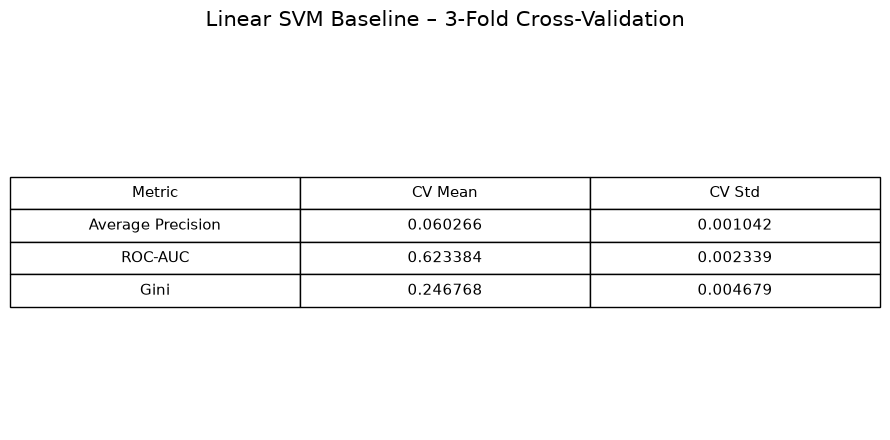

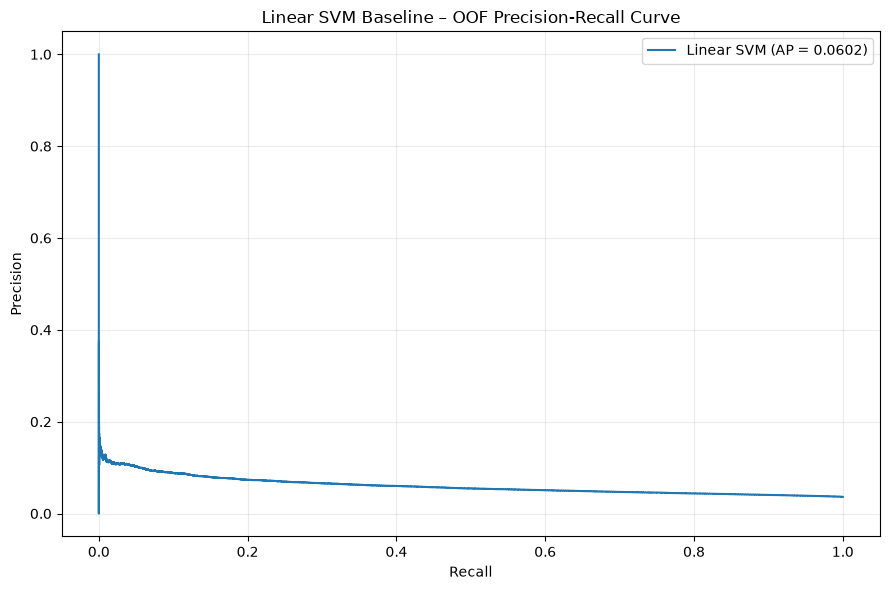

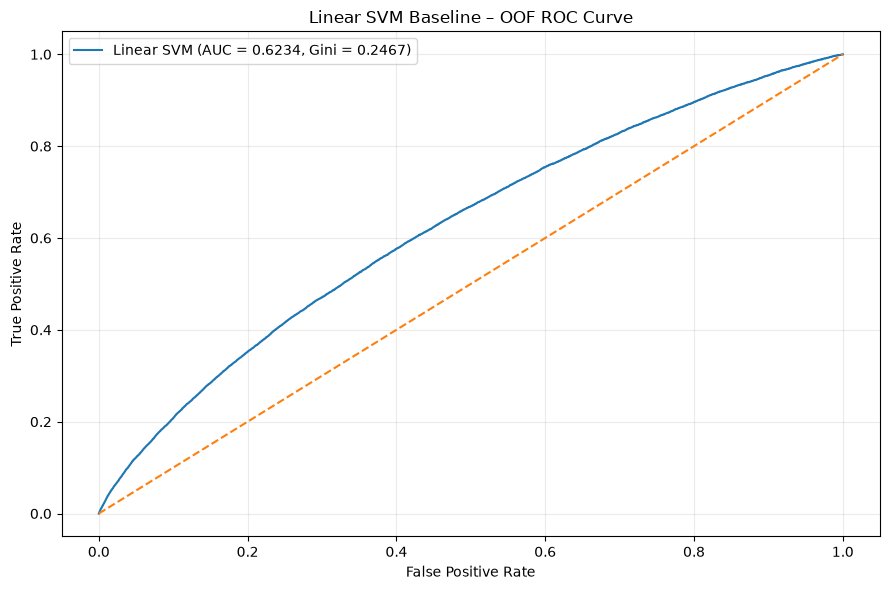


LINEAR SVM BASELINE COMPLETED

Results saved in:
c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\SVM_Linear_Baseline


In [16]:
# ============================================================
# LINEAR SVM BASELINE
# OpenML 42742
# SAME TRAIN / TEST SPLIT AND SAME 3 SAVED CV FOLDS
# ============================================================

import os
import pickle
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import LinearSVC
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve
)

# ============================================================
# 1. OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = "SVM_Linear_Baseline"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 80)
print("LINEAR SVM BASELINE")
print("=" * 80)


# ============================================================
# 2. LOAD THE SAME CV FOLDS USED FOR XGBOOST
# ============================================================

candidate_directories = [
    "XGBoost_RandomizedSearch_OpenML_42742",
    "XGBoost_RandomizedSearch"
]

folds_path = None

for directory in candidate_directories:

    candidate = os.path.join(
        directory,
        "cv_folds.pkl"
    )

    if os.path.exists(candidate):
        folds_path = candidate
        break


if folds_path is None:
    raise FileNotFoundError(
        "cv_folds.pkl could not be found."
    )


with open(folds_path, "rb") as f:
    cv_splits = pickle.load(f)


if len(cv_splits) != 3:
    raise ValueError(
        f"Expected 3 CV folds, found {len(cv_splits)}."
    )


print("\nSame saved CV folds loaded.")
print("Number of folds:", len(cv_splits))


# ============================================================
# 3. PREPARE DATA
# ============================================================

y_train_array = np.asarray(y_train).astype(int)

print("\nProcessed training shape:")
print(X_train_processed.shape)


# ============================================================
# 4. LINEAR SVM BASELINE PARAMETERS
# ============================================================
#
# class_weight is intentionally NOT used in the baseline.
# We first evaluate the standard Linear SVM.
# ============================================================

baseline_params = {
    "C": 1.0,
    "class_weight": None,
    "max_iter": 5000,
    "random_state": 42
}


# ============================================================
# 5. CROSS-VALIDATION
# ============================================================

fold_ap = []
fold_auc = []
fold_gini = []

oof_scores = np.zeros(
    len(y_train_array),
    dtype=float
)


for fold_number, (train_idx, valid_idx) in enumerate(
    cv_splits,
    start=1
):

    print("\n" + "-" * 70)
    print(f"Fold {fold_number}/3")
    print("-" * 70)

    X_fold_train = X_train_processed[train_idx]
    X_fold_valid = X_train_processed[valid_idx]

    y_fold_train = y_train_array[train_idx]
    y_fold_valid = y_train_array[valid_idx]


    svm = LinearSVC(
        **baseline_params
    )


    svm.fit(
        X_fold_train,
        y_fold_train
    )


    # LinearSVC has no predict_proba().
    # decision_function() is perfectly valid for ranking metrics
    # such as Average Precision and ROC-AUC.
    valid_scores = svm.decision_function(
        X_fold_valid
    )


    oof_scores[valid_idx] = valid_scores


    ap = average_precision_score(
        y_fold_valid,
        valid_scores
    )

    auc = roc_auc_score(
        y_fold_valid,
        valid_scores
    )

    gini = 2 * auc - 1


    fold_ap.append(ap)
    fold_auc.append(auc)
    fold_gini.append(gini)


    print(f"Average Precision : {ap:.6f}")
    print(f"ROC-AUC           : {auc:.6f}")
    print(f"Gini              : {gini:.6f}")


    # Save each fold model
    joblib.dump(
        svm,
        os.path.join(
            OUTPUT_DIR,
            f"linear_svm_fold_{fold_number}.joblib"
        )
    )


# ============================================================
# 6. CV SUMMARY
# ============================================================

mean_ap = np.mean(fold_ap)
std_ap = np.std(fold_ap)

mean_auc = np.mean(fold_auc)
std_auc = np.std(fold_auc)

mean_gini = np.mean(fold_gini)
std_gini = np.std(fold_gini)


results_df = pd.DataFrame({
    "Metric": [
        "Average Precision",
        "ROC-AUC",
        "Gini"
    ],
    "CV Mean": [
        mean_ap,
        mean_auc,
        mean_gini
    ],
    "CV Std": [
        std_ap,
        std_auc,
        std_gini
    ]
})


print("\n" + "=" * 80)
print("LINEAR SVM BASELINE RESULTS")
print("=" * 80)

display(
    results_df.round(6)
)


results_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "linear_svm_baseline_results.csv"
    ),
    index=False
)


# ============================================================
# 7. SAVE METRICS TABLE AS IMAGE
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 4.5)
)

ax.axis("off")

table = ax.table(
    cellText=results_df.round(6).values,
    colLabels=results_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)

ax.set_title(
    "Linear SVM Baseline – 3-Fold Cross-Validation",
    fontsize=15,
    pad=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "01_linear_svm_baseline_metrics.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 8. PRECISION-RECALL CURVE FROM OOF SCORES
# ============================================================

precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y_train_array,
        oof_scores
    )
)

oof_ap = average_precision_score(
    y_train_array,
    oof_scores
)


plt.figure(figsize=(9, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"Linear SVM (AP = {oof_ap:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Linear SVM Baseline – OOF Precision-Recall Curve"
)

plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "02_linear_svm_precision_recall_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 9. ROC CURVE FROM OOF SCORES
# ============================================================

fpr, tpr, _ = roc_curve(
    y_train_array,
    oof_scores
)

oof_auc = roc_auc_score(
    y_train_array,
    oof_scores
)

oof_gini = 2 * oof_auc - 1


plt.figure(figsize=(9, 6))

plt.plot(
    fpr,
    tpr,
    label=(
        f"Linear SVM "
        f"(AUC = {oof_auc:.4f}, "
        f"Gini = {oof_gini:.4f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Linear SVM Baseline – OOF ROC Curve"
)

plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "03_linear_svm_roc_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 10. SAVE OOF SCORES
# ============================================================

oof_df = pd.DataFrame({
    "y_true": y_train_array,
    "decision_score": oof_scores
})

oof_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "linear_svm_oof_scores.csv"
    ),
    index=False
)


print("\n" + "=" * 80)
print("LINEAR SVM BASELINE COMPLETED")
print("=" * 80)

print(f"\nResults saved in:\n{os.path.abspath(OUTPUT_DIR)}")

LINEAR SVM HYPERPARAMETER TUNING

Processed training shape: (476169, 235)

Saved CV folds loaded.
Number of folds: 3

Number of parameter combinations: 14
Total SVM fits: 42


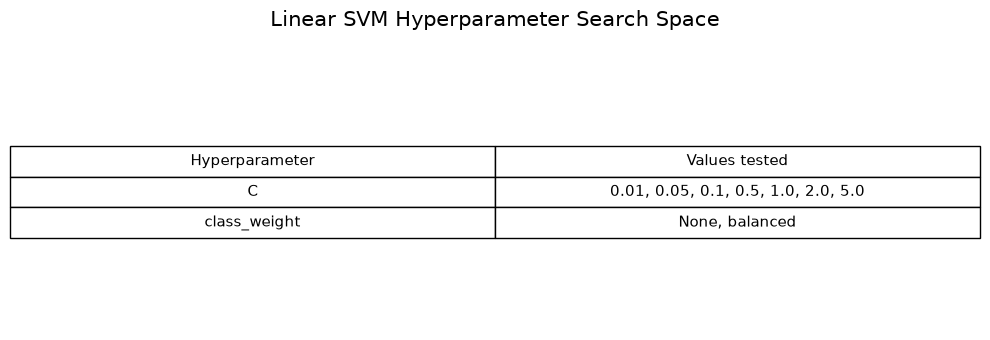


STARTING LINEAR SVM TUNING

----------------------------------------------------------------------
CONFIGURATION 1/14
C = 0.01 | class_weight = None
----------------------------------------------------------------------
Fit 1/42 — Fold 1
ROC-AUC = 0.626243 | Gini = 0.252487 | AP = 0.061808
Fit 2/42 — Fold 2
ROC-AUC = 0.620680 | Gini = 0.241361 | AP = 0.059515
Fit 3/42 — Fold 3
ROC-AUC = 0.624242 | Gini = 0.248484 | AP = 0.060181

----------------------------------------------------------------------
CONFIGURATION 2/14
C = 0.01 | class_weight = balanced
----------------------------------------------------------------------
Fit 4/42 — Fold 1
ROC-AUC = 0.626429 | Gini = 0.252857 | AP = 0.061945
Fit 5/42 — Fold 2
ROC-AUC = 0.619438 | Gini = 0.238875 | AP = 0.058953
Fit 6/42 — Fold 3
ROC-AUC = 0.624666 | Gini = 0.249332 | AP = 0.060415

----------------------------------------------------------------------
CONFIGURATION 3/14
C = 0.05 | class_weight = None
----------------------------------

,C,class_weight,CV_ROC_AUC,CV_ROC_AUC_Std,CV_Gini,CV_Gini_Std,CV_AP,CV_AP_Std,ROC_AUC_Rank,AP_Rank,Gini_Rank
0,0.01,None,0.623722,0.002301,0.247444,0.004601,0.060501,0.000963,1,1,1
1,0.05,None,0.623517,0.002388,0.247034,0.004775,0.060371,0.001060,2,4,2
2,0.01,balanced,0.623511,0.002969,0.247021,0.005937,0.060438,0.001221,3,2,3
3,0.10,None,0.623488,0.002401,0.246977,0.004801,0.060339,0.001092,4,11,4
4,5.00,None,0.623437,0.002425,0.246875,0.004849,0.060325,0.001096,5,12,5
5,0.50,None,0.623434,0.002386,0.246868,0.004772,0.060380,0.001033,6,3,6
6,2.00,None,0.623429,0.002408,0.246857,0.004816,0.060306,0.001088,7,13,7
7,1.00,None,0.623384,0.002339,0.246768,0.004679,0.060266,0.001042,8,14,8
8,0.05,balanced,0.623345,0.003036,0.246690,0.006072,0.060365,0.001273,9,5,9
9,0.10,balanced,0.623319,0.003045,0.246639,0.006089,0.060353,0.001274,10,6,10


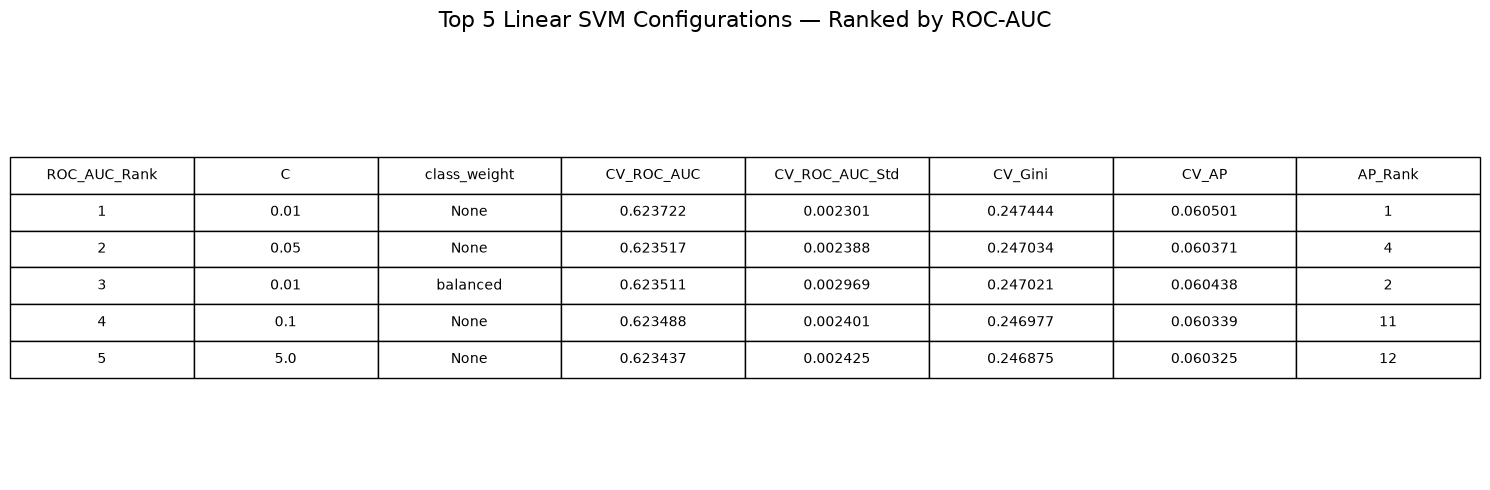

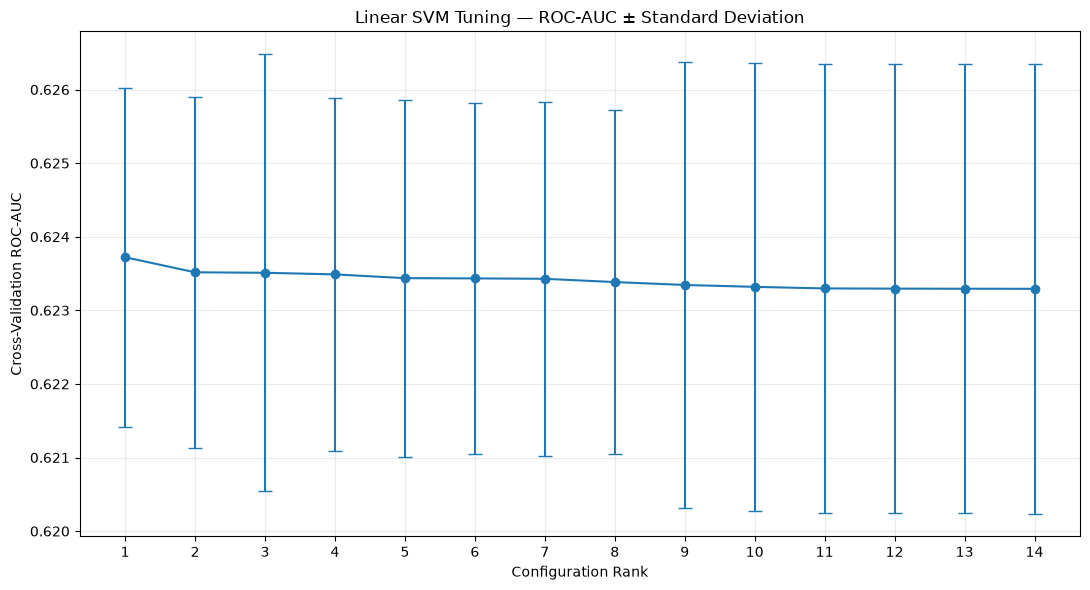

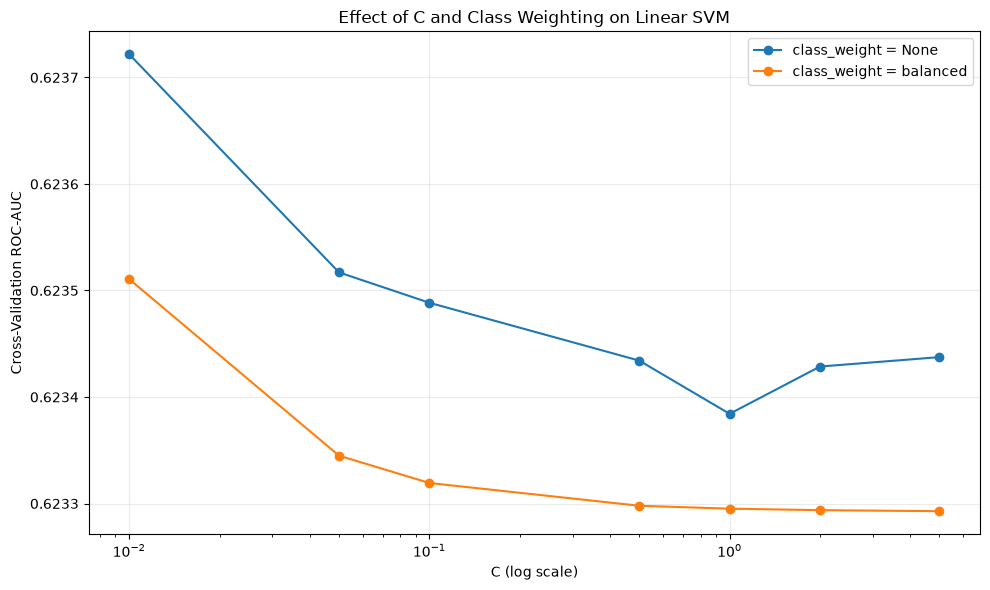

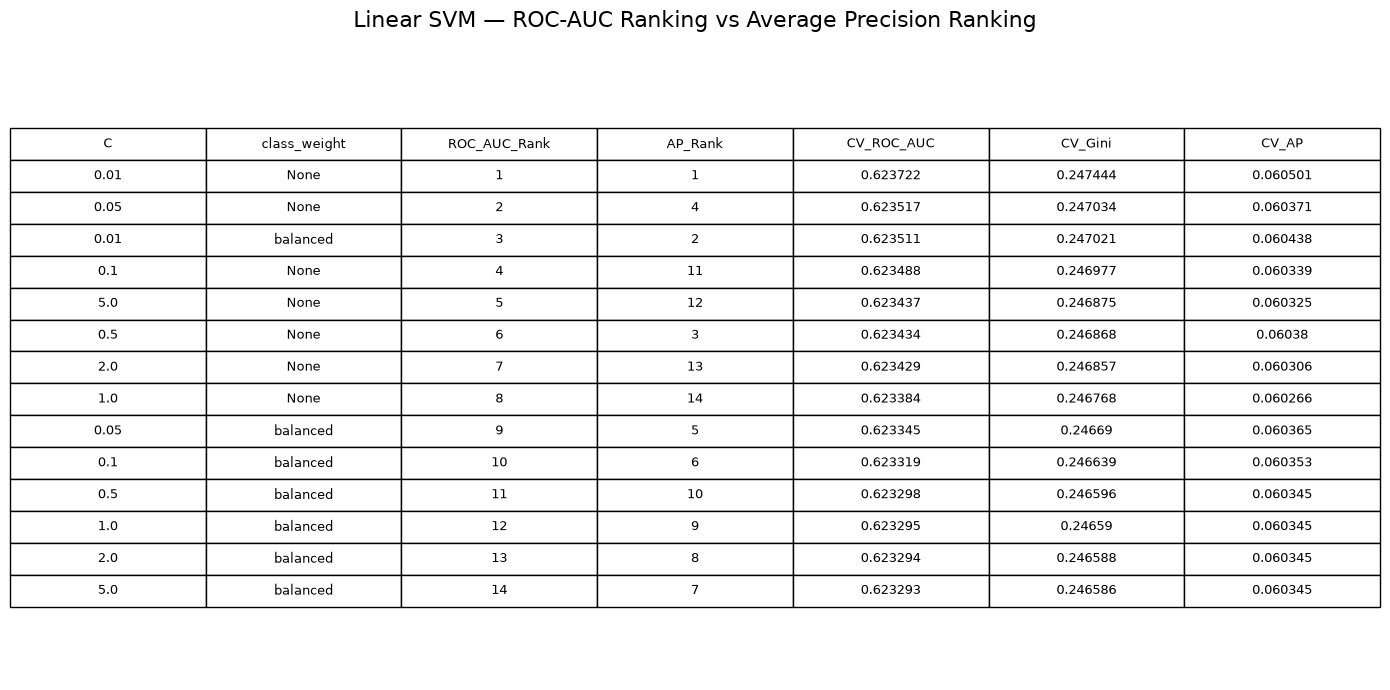


BEST LINEAR SVM CONFIGURATION

C = 0.01
class_weight = None
CV ROC-AUC = 0.623722
CV Gini = 0.247444
CV Average Precision = 0.060501


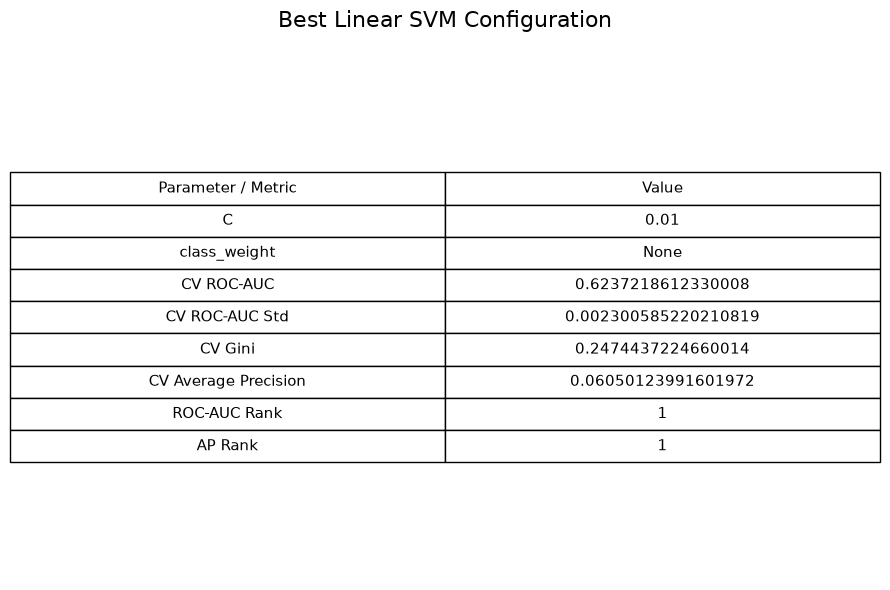

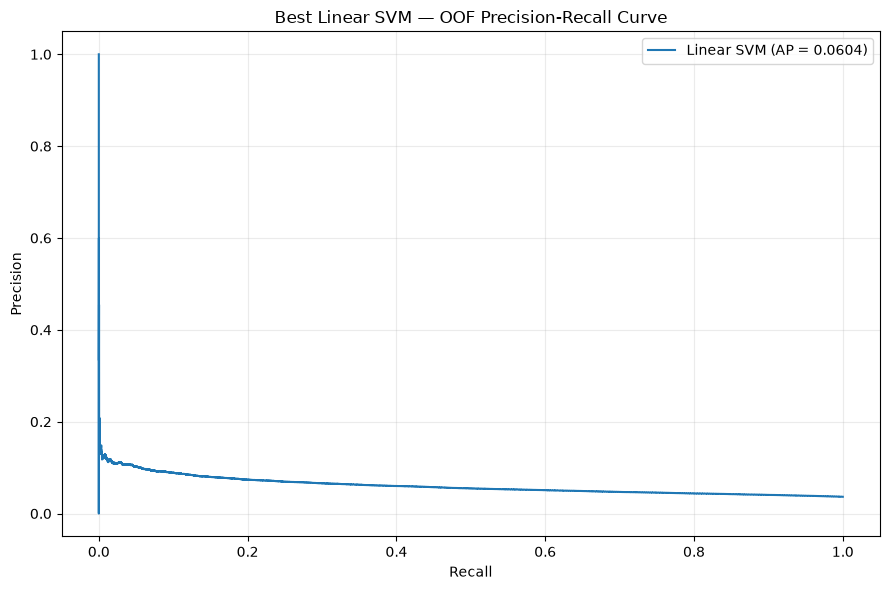

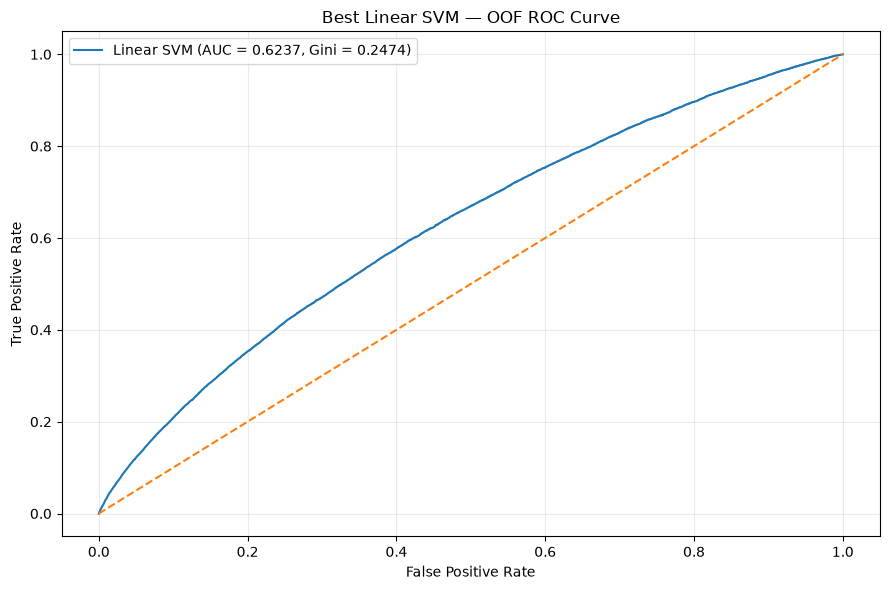


Training best SVM on the complete training set...

LINEAR SVM TUNING COMPLETED

Configurations tested: 14
Total fits: 42

Best C: 0.01
Best class weight: None

Best CV ROC-AUC: 0.623722
Best CV Gini: 0.247444
Best CV AP: 0.060501

✓ Same 3 folds as XGBoost
✓ ROC-AUC used for final ranking
✓ Gini calculated
✓ Average Precision retained
✓ Best model saved as JOBLIB
✓ Test set NOT used

Results saved in:
c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\SVM_Linear_Tuning


In [17]:
# ============================================================
# LINEAR SVM - CONTROLLED HYPERPARAMETER TUNING
# OpenML 42742
#
# Main ranking metric : ROC-AUC
# Complementary metrics: Gini and Average Precision
#
# IMPORTANT:
# - Same X_train as XGBoost
# - Same processed training data
# - Same 3 saved CV folds
# - Test set is NOT used
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import pickle
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve
)


# ============================================================
# 1. OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = "SVM_Linear_Tuning"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("=" * 80)
print("LINEAR SVM HYPERPARAMETER TUNING")
print("=" * 80)


# ============================================================
# 2. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "X_train_processed",
    "y_train"
]

missing_variables = [
    var
    for var in required_variables
    if var not in globals()
]

if missing_variables:

    raise NameError(
        "Missing required variables: "
        + ", ".join(missing_variables)
    )


y_train_array = np.asarray(
    y_train
).astype(int)

print(
    "\nProcessed training shape:",
    X_train_processed.shape
)


# ============================================================
# 3. LOAD EXACT SAME CV FOLDS AS XGBOOST
# ============================================================

candidate_directories = [
    "XGBoost_RandomizedSearch_OpenML_42742",
    "XGBoost_RandomizedSearch"
]

folds_path = None

for directory in candidate_directories:

    candidate = os.path.join(
        directory,
        "cv_folds.pkl"
    )

    if os.path.exists(candidate):

        folds_path = candidate
        break


if folds_path is None:

    raise FileNotFoundError(
        "cv_folds.pkl could not be found."
    )


with open(
    folds_path,
    "rb"
) as f:

    cv_splits = pickle.load(f)


if len(cv_splits) != 3:

    raise ValueError(
        f"Expected 3 saved CV folds, "
        f"but found {len(cv_splits)}."
    )


print("\nSaved CV folds loaded.")
print("Number of folds:", len(cv_splits))


# ============================================================
# 4. DEFINE TUNING SPACE
# ============================================================
#
# C controls regularization:
#
# Small C:
# stronger regularization
#
# Large C:
# weaker regularization
#
# class_weight="balanced" is included here so that class
# weighting is evaluated as part of model selection rather
# than as an additional modelling stage.
# ============================================================

C_values = [
    0.01,
    0.05,
    0.1,
    0.5,
    1.0,
    2.0,
    5.0
]

class_weight_values = [
    None,
    "balanced"
]


parameter_combinations = []

for C in C_values:

    for class_weight in class_weight_values:

        parameter_combinations.append({

            "C": C,

            "class_weight": class_weight
        })


print(
    "\nNumber of parameter combinations:",
    len(parameter_combinations)
)

print(
    "Total SVM fits:",
    len(parameter_combinations)
    * len(cv_splits)
)


# ============================================================
# 5. SAVE SEARCH SPACE AS IMAGE
# ============================================================

search_space_df = pd.DataFrame({

    "Hyperparameter": [
        "C",
        "class_weight"
    ],

    "Values tested": [
        ", ".join(
            str(value)
            for value in C_values
        ),

        "None, balanced"
    ]
})


fig, ax = plt.subplots(
    figsize=(10, 3.5)
)

ax.axis("off")

table = ax.table(
    cellText=search_space_df.values,
    colLabels=search_space_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)

ax.set_title(
    "Linear SVM Hyperparameter Search Space",
    fontsize=15,
    pad=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "01_SVM_tuning_search_space.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 6. MANUAL CONTROLLED CV TUNING
# ============================================================
#
# We use a manual loop instead of GridSearchCV because this
# allows us to store ROC-AUC, Gini AND Average Precision
# simultaneously for every configuration.
# ============================================================

results = []

all_oof_scores = {}

fit_counter = 0

total_fits = (
    len(parameter_combinations)
    * len(cv_splits)
)


print("\n" + "=" * 80)
print("STARTING LINEAR SVM TUNING")
print("=" * 80)


for config_number, params in enumerate(
    parameter_combinations,
    start=1
):

    print("\n" + "-" * 70)

    print(
        f"CONFIGURATION "
        f"{config_number}/{len(parameter_combinations)}"
    )

    print(
        f"C = {params['C']} | "
        f"class_weight = {params['class_weight']}"
    )

    print("-" * 70)


    fold_auc = []
    fold_ap = []
    fold_gini = []

    oof_scores = np.zeros(
        len(y_train_array),
        dtype=float
    )


    # ========================================================
    # SAME 3 SAVED FOLDS
    # ========================================================

    for fold_number, (
        train_idx,
        valid_idx
    ) in enumerate(
        cv_splits,
        start=1
    ):

        fit_counter += 1

        print(
            f"Fit {fit_counter}/{total_fits} "
            f"— Fold {fold_number}"
        )


        X_fold_train = (
            X_train_processed[
                train_idx
            ]
        )

        X_fold_valid = (
            X_train_processed[
                valid_idx
            ]
        )

        y_fold_train = (
            y_train_array[
                train_idx
            ]
        )

        y_fold_valid = (
            y_train_array[
                valid_idx
            ]
        )


        # ----------------------------------------------------
        # Linear SVM
        # ----------------------------------------------------

        model = LinearSVC(

            C=params["C"],

            class_weight=params[
                "class_weight"
            ],

            max_iter=5000,

            dual="auto",

            random_state=42
        )


        model.fit(
            X_fold_train,
            y_fold_train
        )


        # ----------------------------------------------------
        # Decision score
        #
        # No probability calibration is needed for ranking
        # metrics such as ROC-AUC and Average Precision.
        # ----------------------------------------------------

        valid_scores = (
            model.decision_function(
                X_fold_valid
            )
        )


        oof_scores[
            valid_idx
        ] = valid_scores


        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        auc = roc_auc_score(
            y_fold_valid,
            valid_scores
        )

        gini = (
            2 * auc - 1
        )

        ap = average_precision_score(
            y_fold_valid,
            valid_scores
        )


        fold_auc.append(
            auc
        )

        fold_gini.append(
            gini
        )

        fold_ap.append(
            ap
        )


        print(
            f"ROC-AUC = {auc:.6f} | "
            f"Gini = {gini:.6f} | "
            f"AP = {ap:.6f}"
        )


    # ========================================================
    # CONFIGURATION SUMMARY
    # ========================================================

    results.append({

        "C":
            params["C"],

        "class_weight":
            str(
                params["class_weight"]
            ),

        "CV_ROC_AUC":
            np.mean(
                fold_auc
            ),

        "CV_ROC_AUC_Std":
            np.std(
                fold_auc
            ),

        "CV_Gini":
            np.mean(
                fold_gini
            ),

        "CV_Gini_Std":
            np.std(
                fold_gini
            ),

        "CV_AP":
            np.mean(
                fold_ap
            ),

        "CV_AP_Std":
            np.std(
                fold_ap
            )
    })


    combination_name = (
        f"C_{params['C']}_"
        f"weight_{params['class_weight']}"
    )

    all_oof_scores[
        combination_name
    ] = oof_scores


# ============================================================
# 7. RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(
    results
)


# ============================================================
# 8. RANK MODELS BY ROC-AUC
# ============================================================

results_df[
    "ROC_AUC_Rank"
] = (
    results_df[
        "CV_ROC_AUC"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)


# ============================================================
# 9. ALSO RANK BY AP
# ============================================================

results_df[
    "AP_Rank"
] = (
    results_df[
        "CV_AP"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)


# Gini ranking is identical to ROC-AUC
results_df[
    "Gini_Rank"
] = results_df[
    "ROC_AUC_Rank"
]


# Sort according to the common group metric
results_df = results_df.sort_values(
    "ROC_AUC_Rank"
).reset_index(drop=True)


print("\n" + "=" * 80)
print("SVM TUNING RESULTS — RANKED BY ROC-AUC")
print("=" * 80)

display(
    results_df.round(6)
)


# ============================================================
# 10. SAVE ALL RESULTS
# ============================================================

results_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "02_SVM_all_tuning_results.csv"
    ),
    index=False
)


# ============================================================
# 11. TOP 5 CONFIGURATIONS
# ============================================================

top5 = (
    results_df
    .head(5)
    .copy()
)


top5_display = top5[
    [
        "ROC_AUC_Rank",
        "C",
        "class_weight",
        "CV_ROC_AUC",
        "CV_ROC_AUC_Std",
        "CV_Gini",
        "CV_AP",
        "AP_Rank"
    ]
].copy()


# ============================================================
# 12. SAVE TOP 5 TABLE AS IMAGE
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 5)
)

ax.axis("off")

table = ax.table(
    cellText=top5_display.round(6).values,
    colLabels=top5_display.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

ax.set_title(
    "Top 5 Linear SVM Configurations — Ranked by ROC-AUC",
    fontsize=16,
    pad=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "03_SVM_top5_ROC_AUC_table.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 13. ROC-AUC PERFORMANCE GRAPH
# ============================================================

plot_df = (
    results_df
    .sort_values(
        "ROC_AUC_Rank"
    )
)


plt.figure(
    figsize=(11, 6)
)

plt.errorbar(

    range(
        1,
        len(plot_df) + 1
    ),

    plot_df[
        "CV_ROC_AUC"
    ],

    yerr=plot_df[
        "CV_ROC_AUC_Std"
    ],

    marker="o",

    capsize=5
)


plt.xlabel(
    "Configuration Rank"
)

plt.ylabel(
    "Cross-Validation ROC-AUC"
)

plt.title(
    "Linear SVM Tuning — "
    "ROC-AUC ± Standard Deviation"
)

plt.xticks(
    range(
        1,
        len(plot_df) + 1
    )
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "04_SVM_ROC_AUC_performance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 14. EFFECT OF C
# ============================================================

plt.figure(
    figsize=(10, 6)
)


for weight_value in [
    "None",
    "balanced"
]:

    subset = (
        results_df[
            results_df[
                "class_weight"
            ] == weight_value
        ]
        .sort_values(
            "C"
        )
    )

    plt.plot(
        subset["C"],
        subset["CV_ROC_AUC"],
        marker="o",
        label=f"class_weight = {weight_value}"
    )


plt.xscale(
    "log"
)

plt.xlabel(
    "C (log scale)"
)

plt.ylabel(
    "Cross-Validation ROC-AUC"
)

plt.title(
    "Effect of C and Class Weighting on Linear SVM"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "05_effect_of_C_and_class_weight.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 15. ROC-AUC RANK VS AP RANK
# ============================================================

rank_comparison = results_df[
    [
        "C",
        "class_weight",
        "ROC_AUC_Rank",
        "AP_Rank",
        "CV_ROC_AUC",
        "CV_Gini",
        "CV_AP"
    ]
].copy()


fig, ax = plt.subplots(
    figsize=(14, 7)
)

ax.axis("off")

table = ax.table(
    cellText=rank_comparison.round(6).values,
    colLabels=rank_comparison.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.65)

ax.set_title(
    "Linear SVM — ROC-AUC Ranking vs Average Precision Ranking",
    fontsize=16,
    pad=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "06_ROC_AUC_vs_AP_ranking.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 16. IDENTIFY BEST SVM
# ============================================================

best_row = results_df.iloc[
    0
]

best_C = float(
    best_row["C"]
)

best_class_weight = (
    None
    if best_row[
        "class_weight"
    ] == "None"
    else "balanced"
)


print("\n" + "=" * 80)
print("BEST LINEAR SVM CONFIGURATION")
print("=" * 80)

print(
    f"\nC = {best_C}"
)

print(
    f"class_weight = {best_class_weight}"
)

print(
    f"CV ROC-AUC = "
    f"{best_row['CV_ROC_AUC']:.6f}"
)

print(
    f"CV Gini = "
    f"{best_row['CV_Gini']:.6f}"
)

print(
    f"CV Average Precision = "
    f"{best_row['CV_AP']:.6f}"
)


# ============================================================
# 17. SAVE BEST CONFIGURATION AS IMAGE
# ============================================================

best_table = pd.DataFrame({

    "Parameter / Metric": [
        "C",
        "class_weight",
        "CV ROC-AUC",
        "CV ROC-AUC Std",
        "CV Gini",
        "CV Average Precision",
        "ROC-AUC Rank",
        "AP Rank"
    ],

    "Value": [
        best_C,
        str(
            best_class_weight
        ),
        best_row[
            "CV_ROC_AUC"
        ],
        best_row[
            "CV_ROC_AUC_Std"
        ],
        best_row[
            "CV_Gini"
        ],
        best_row[
            "CV_AP"
        ],
        int(
            best_row[
                "ROC_AUC_Rank"
            ]
        ),
        int(
            best_row[
                "AP_Rank"
            ]
        )
    ]
})


fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.axis("off")

table = ax.table(
    cellText=best_table.values,
    colLabels=best_table.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.7)

ax.set_title(
    "Best Linear SVM Configuration",
    fontsize=16,
    pad=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "07_best_SVM_configuration.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 18. SAVE OOF SCORES OF ALL CONFIGURATIONS
# ============================================================

oof_scores_df = pd.DataFrame(
    all_oof_scores
)

oof_scores_df[
    "y_true"
] = y_train_array


oof_scores_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "08_SVM_all_OOF_scores.csv"
    ),
    index=False
)


# ============================================================
# 19. GET BEST OOF SCORES
# ============================================================

best_key = (
    f"C_{best_C}_"
    f"weight_{best_class_weight}"
)


best_oof_scores = (
    all_oof_scores[
        best_key
    ]
)


# ============================================================
# 20. PRECISION-RECALL CURVE
# ============================================================

precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y_train_array,
        best_oof_scores
    )
)

best_oof_ap = (
    average_precision_score(
        y_train_array,
        best_oof_scores
    )
)


plt.figure(
    figsize=(9, 6)
)

plt.plot(
    recall_curve,
    precision_curve,
    label=(
        f"Linear SVM "
        f"(AP = {best_oof_ap:.4f})"
    )
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Best Linear SVM — "
    "OOF Precision-Recall Curve"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "09_best_SVM_precision_recall_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 21. ROC CURVE
# ============================================================

fpr, tpr, _ = (
    roc_curve(
        y_train_array,
        best_oof_scores
    )
)

best_oof_auc = (
    roc_auc_score(
        y_train_array,
        best_oof_scores
    )
)

best_oof_gini = (
    2 * best_oof_auc - 1
)


plt.figure(
    figsize=(9, 6)
)

plt.plot(
    fpr,
    tpr,
    label=(
        f"Linear SVM "
        f"(AUC = {best_oof_auc:.4f}, "
        f"Gini = {best_oof_gini:.4f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Best Linear SVM — "
    "OOF ROC Curve"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "10_best_SVM_ROC_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 22. TRAIN BEST SVM ON FULL TRAINING DATA
# ============================================================
#
# This model is saved for later use.
#
# The test set is STILL NOT evaluated here.
# ============================================================

best_svm = LinearSVC(

    C=best_C,

    class_weight=best_class_weight,

    max_iter=5000,

    dual="auto",

    random_state=42
)


print(
    "\nTraining best SVM "
    "on the complete training set..."
)

best_svm.fit(
    X_train_processed,
    y_train_array
)


# ============================================================
# 23. SAVE BEST TRAINED SVM
# ============================================================

joblib.dump(
    best_svm,
    os.path.join(
        OUTPUT_DIR,
        "11_best_linear_SVM.joblib"
    )
)


# ============================================================
# 24. SAVE EXPERIMENT SUMMARY
# ============================================================

summary = {

    "model":
        "LinearSVC",

    "ranking_metric":
        "ROC-AUC",

    "secondary_metrics": [
        "Gini",
        "Average Precision"
    ],

    "cv_folds":
        3,

    "same_folds_as_xgboost":
        True,

    "number_of_configurations":
        len(
            parameter_combinations
        ),

    "total_fits":
        total_fits,

    "best_C":
        best_C,

    "best_class_weight":
        best_class_weight,

    "best_cv_roc_auc":
        float(
            best_row[
                "CV_ROC_AUC"
            ]
        ),

    "best_cv_gini":
        float(
            best_row[
                "CV_Gini"
            ]
        ),

    "best_cv_average_precision":
        float(
            best_row[
                "CV_AP"
            ]
        ),

    "test_set_used":
        False
}


with open(
    os.path.join(
        OUTPUT_DIR,
        "12_SVM_tuning_summary.json"
    ),
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


# ============================================================
# 25. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("LINEAR SVM TUNING COMPLETED")
print("=" * 80)

print(
    f"\nConfigurations tested: "
    f"{len(parameter_combinations)}"
)

print(
    f"Total fits: {total_fits}"
)

print(
    f"\nBest C: "
    f"{best_C}"
)

print(
    f"Best class weight: "
    f"{best_class_weight}"
)

print(
    f"\nBest CV ROC-AUC: "
    f"{best_row['CV_ROC_AUC']:.6f}"
)

print(
    f"Best CV Gini: "
    f"{best_row['CV_Gini']:.6f}"
)

print(
    f"Best CV AP: "
    f"{best_row['CV_AP']:.6f}"
)

print(
    "\n✓ Same 3 folds as XGBoost"
)

print(
    "✓ ROC-AUC used for final ranking"
)

print(
    "✓ Gini calculated"
)

print(
    "✓ Average Precision retained"
)

print(
    "✓ Best model saved as JOBLIB"
)

print(
    "✓ Test set NOT used"
)

print(
    f"\nResults saved in:\n"
    f"{os.path.abspath(OUTPUT_DIR)}"
)

XGBOOST + SVM ENSEMBLE
SIMPLE AND WEIGHTED AVERAGING

Best non-weighted XGBoost OOF predictions loaded.

Best SVM:
C = 0.01
class_weight = None
CV ROC-AUC = 0.623722

SVM OOF score column:
C_0.01_weight_None

OOF observations: 476,169
✓ XGBoost and SVM predictions are aligned.

Base model OOF performance:
XGBoost — AUC=0.636784, Gini=0.273567, AP=0.064594
SVM     — AUC=0.623695, Gini=0.247390, AP=0.060352

Simple Average 50/50:
ROC-AUC = 0.635143
Gini    = 0.270287
AP      = 0.063436

BEST WEIGHTED AVERAGE
XGBoost weight : 0.85
SVM weight     : 0.15
ROC-AUC        : 0.637398
Gini           : 0.274795
AP             : 0.064281


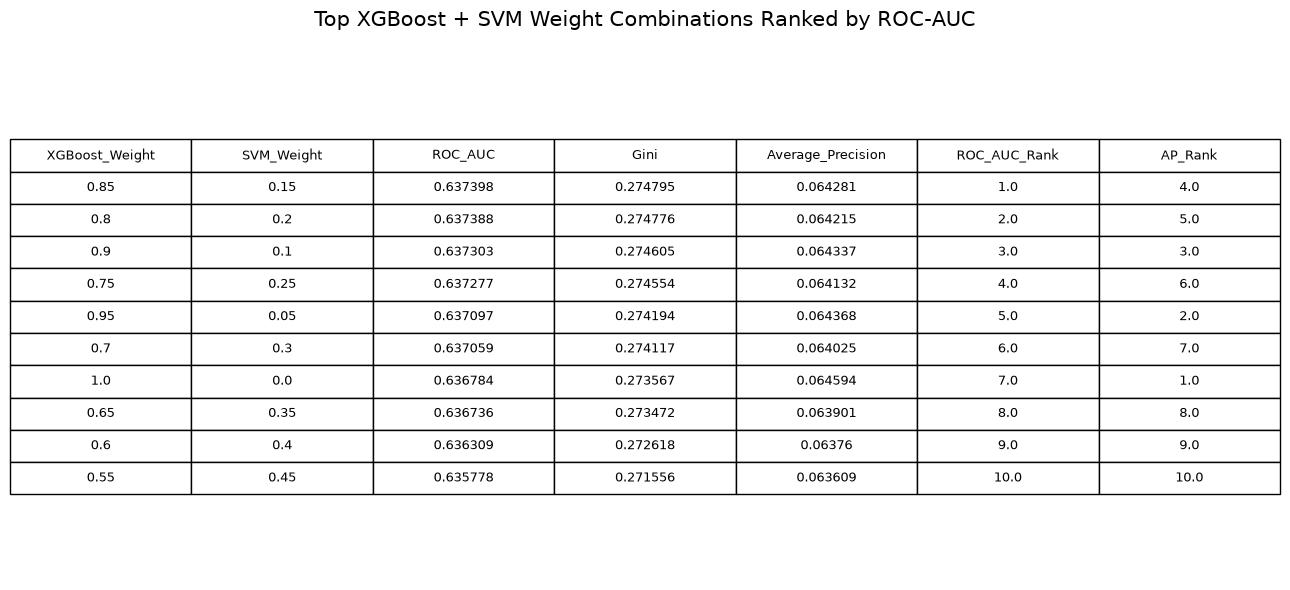

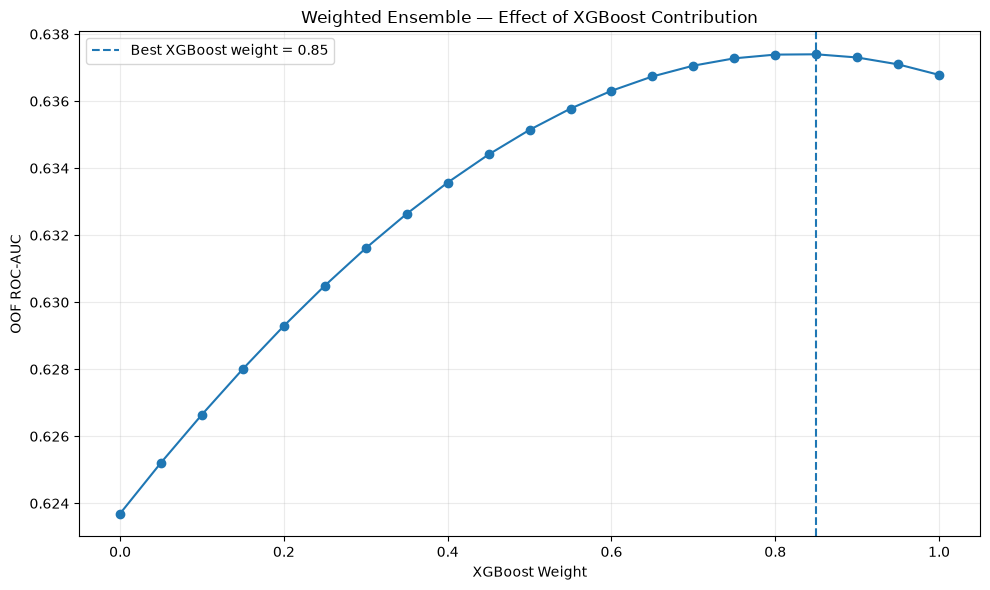


SIMPLE + WEIGHTED AVERAGING COMPLETED

✓ No base model retraining
✓ 21 weight combinations evaluated
✓ Ranking based primarily on ROC-AUC
✓ Gini and AP also stored

Results saved in:
c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\Ensemble_XGBoost_SVM


In [19]:
# ============================================================
# ENSEMBLE STEP 1
# XGBOOST + SVM
# SIMPLE AVERAGE + WEIGHTED AVERAGE SEARCH
# ============================================================
#
# Selected base models:
#
# XGBoost:
#   Best NON-WEIGHTED XGBoost according to CV ROC-AUC/Gini.
#
# SVM:
#   Best tuned Linear SVM according to CV ROC-AUC.
#
# IMPORTANT:
# - No XGBoost retraining
# - No SVM retraining
# - Uses previously saved OOF predictions
# - Test set is NOT used
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import QuantileTransformer

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)


# ============================================================
# 1. OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = "Ensemble_XGBoost_SVM"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("=" * 80)
print("XGBOOST + SVM ENSEMBLE")
print("SIMPLE AND WEIGHTED AVERAGING")
print("=" * 80)


# ============================================================
# 2. LOAD BEST NON-WEIGHTED XGBOOST OOF PREDICTIONS
# ============================================================

xgb_oof_path = os.path.join(
    "XGBoost_NonWeighted_Best_ROC_AUC_OOF",
    "best_nonweighted_xgboost_OOF_predictions.csv"
)

if not os.path.exists(xgb_oof_path):

    raise FileNotFoundError(
        "Best non-weighted XGBoost OOF predictions were not found."
    )


xgb_oof_df = pd.read_csv(
    xgb_oof_path
)


y_xgb = (
    xgb_oof_df[
        "y_true"
    ]
    .to_numpy()
    .astype(int)
)


xgb_raw_score = (
    xgb_oof_df[
        "xgb_oof_probability"
    ]
    .to_numpy()
)


print(
    "\nBest non-weighted XGBoost OOF predictions loaded."
)


# ============================================================
# 3. LOAD SVM TUNING RESULTS
# ============================================================

svm_results_path = os.path.join(
    "SVM_Linear_Tuning",
    "02_SVM_all_tuning_results.csv"
)

svm_scores_path = os.path.join(
    "SVM_Linear_Tuning",
    "08_SVM_all_OOF_scores.csv"
)


if not os.path.exists(svm_results_path):

    raise FileNotFoundError(
        "SVM tuning results were not found."
    )


if not os.path.exists(svm_scores_path):

    raise FileNotFoundError(
        "SVM OOF scores were not found."
    )


svm_results = pd.read_csv(
    svm_results_path
)


svm_oof_df = pd.read_csv(
    svm_scores_path
)


# ============================================================
# 4. IDENTIFY BEST SVM ACCORDING TO ROC-AUC
# ============================================================

best_svm_row = (
    svm_results
    .sort_values(
        "CV_ROC_AUC",
        ascending=False
    )
    .iloc[0]
)


best_C = float(
    best_svm_row[
        "C"
    ]
)


class_weight_value = (
    best_svm_row[
        "class_weight"
    ]
)


if (
    pd.isna(class_weight_value)
    or str(class_weight_value).lower() == "none"
):

    best_class_weight = "None"

else:

    best_class_weight = "balanced"


print(
    f"\nBest SVM:"
)

print(
    f"C = {best_C}"
)

print(
    f"class_weight = {best_class_weight}"
)

print(
    f"CV ROC-AUC = "
    f"{best_svm_row['CV_ROC_AUC']:.6f}"
)


# ============================================================
# 5. IDENTIFY THE CORRECT SVM OOF COLUMN
# ============================================================

possible_columns = [
    column
    for column in svm_oof_df.columns
    if column != "y_true"
]


expected_column = (
    f"C_{best_C}_"
    f"weight_{best_class_weight}"
)


if expected_column in possible_columns:

    svm_score_column = expected_column

else:

    # More tolerant fallback in case float formatting differs
    matching_columns = [

        column
        for column in possible_columns

        if (
            f"weight_{best_class_weight}"
            in column
        )
    ]


    # Try matching the C value numerically
    numerical_matches = []

    for column in matching_columns:

        try:

            c_part = (
                column
                .split("_weight_")[0]
                .replace("C_", "")
            )

            if np.isclose(
                float(c_part),
                best_C
            ):

                numerical_matches.append(
                    column
                )

        except Exception:

            pass


    if len(numerical_matches) != 1:

        print(
            "\nAvailable SVM score columns:"
        )

        print(
            possible_columns
        )

        raise ValueError(
            "Could not uniquely identify "
            "the best SVM OOF score column."
        )


    svm_score_column = (
        numerical_matches[0]
    )


print(
    f"\nSVM OOF score column:"
)

print(
    svm_score_column
)


svm_raw_score = (
    svm_oof_df[
        svm_score_column
    ]
    .to_numpy()
)


y_svm = (
    svm_oof_df[
        "y_true"
    ]
    .to_numpy()
    .astype(int)
)


# ============================================================
# 6. VERIFY ALIGNMENT
# ============================================================

if len(y_xgb) != len(y_svm):

    raise ValueError(
        "XGBoost and SVM OOF predictions have different lengths."
    )


if not np.array_equal(
    y_xgb,
    y_svm
):

    raise ValueError(
        "XGBoost and SVM OOF labels are not aligned."
    )


y_true = y_xgb


print(
    f"\nOOF observations: {len(y_true):,}"
)

print(
    "✓ XGBoost and SVM predictions are aligned."
)


# ============================================================
# 7. TRANSFORM SCORES TO A COMPARABLE SCALE
# ============================================================
#
# XGBoost gives probabilities.
# LinearSVC gives decision-function values.
#
# A QuantileTransformer maps both score distributions to
# approximately [0, 1] while preserving their ordering.
#
# The transformers are saved because they will be needed later
# when the final ensemble is applied to the test set.
# ============================================================

n_quantiles = min(
    1000,
    len(y_true)
)


xgb_transformer = QuantileTransformer(

    n_quantiles=n_quantiles,

    output_distribution="uniform",

    random_state=42
)


svm_transformer = QuantileTransformer(

    n_quantiles=n_quantiles,

    output_distribution="uniform",

    random_state=42
)


xgb_score = (
    xgb_transformer
    .fit_transform(
        xgb_raw_score.reshape(-1, 1)
    )
    .ravel()
)


svm_score = (
    svm_transformer
    .fit_transform(
        svm_raw_score.reshape(-1, 1)
    )
    .ravel()
)


joblib.dump(

    xgb_transformer,

    os.path.join(
        OUTPUT_DIR,
        "xgb_score_transformer.joblib"
    )
)


joblib.dump(

    svm_transformer,

    os.path.join(
        OUTPUT_DIR,
        "svm_score_transformer.joblib"
    )
)


# ============================================================
# 8. BASE MODEL REFERENCE METRICS
# ============================================================

xgb_auc = roc_auc_score(
    y_true,
    xgb_score
)

xgb_gini = (
    2 * xgb_auc - 1
)

xgb_ap = average_precision_score(
    y_true,
    xgb_score
)


svm_auc = roc_auc_score(
    y_true,
    svm_score
)

svm_gini = (
    2 * svm_auc - 1
)

svm_ap = average_precision_score(
    y_true,
    svm_score
)


print("\nBase model OOF performance:")

print(
    f"XGBoost — AUC={xgb_auc:.6f}, "
    f"Gini={xgb_gini:.6f}, "
    f"AP={xgb_ap:.6f}"
)

print(
    f"SVM     — AUC={svm_auc:.6f}, "
    f"Gini={svm_gini:.6f}, "
    f"AP={svm_ap:.6f}"
)


# ============================================================
# 9. SIMPLE AVERAGE — 50/50
# ============================================================

simple_average_score = (

    0.50 * xgb_score

    +

    0.50 * svm_score
)


simple_auc = roc_auc_score(
    y_true,
    simple_average_score
)

simple_gini = (
    2 * simple_auc - 1
)

simple_ap = average_precision_score(
    y_true,
    simple_average_score
)


print("\nSimple Average 50/50:")

print(
    f"ROC-AUC = {simple_auc:.6f}"
)

print(
    f"Gini    = {simple_gini:.6f}"
)

print(
    f"AP      = {simple_ap:.6f}"
)


# ============================================================
# 10. SEARCH WEIGHTS
# ============================================================
#
# 0.00 means 100% SVM
# 1.00 means 100% XGBoost
#
# Step = 0.05
#
# Only 21 combinations are evaluated.
# No model is retrained.
# ============================================================

weight_results = []


for xgb_weight in np.arange(
    0.0,
    1.0001,
    0.05
):

    svm_weight = (
        1.0
        -
        xgb_weight
    )


    ensemble_score = (

        xgb_weight
        * xgb_score

        +

        svm_weight
        * svm_score
    )


    auc = roc_auc_score(
        y_true,
        ensemble_score
    )


    gini = (
        2 * auc - 1
    )


    ap = average_precision_score(
        y_true,
        ensemble_score
    )


    weight_results.append({

        "XGBoost_Weight":
            round(
                float(xgb_weight),
                2
            ),

        "SVM_Weight":
            round(
                float(svm_weight),
                2
            ),

        "ROC_AUC":
            auc,

        "Gini":
            gini,

        "Average_Precision":
            ap
    })


weights_df = pd.DataFrame(
    weight_results
)


# ============================================================
# 11. CREATE ROC-AUC AND AP RANKINGS
# ============================================================

weights_df[
    "ROC_AUC_Rank"
] = (
    weights_df[
        "ROC_AUC"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)


weights_df[
    "AP_Rank"
] = (
    weights_df[
        "Average_Precision"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)


weights_df = (
    weights_df
    .sort_values(
        "ROC_AUC_Rank"
    )
    .reset_index(drop=True)
)


# ============================================================
# 12. BEST WEIGHT COMBINATION
# ============================================================

best_weight_row = (
    weights_df.iloc[0]
)


best_xgb_weight = float(
    best_weight_row[
        "XGBoost_Weight"
    ]
)


best_svm_weight = float(
    best_weight_row[
        "SVM_Weight"
    ]
)


best_weighted_average_score = (

    best_xgb_weight
    * xgb_score

    +

    best_svm_weight
    * svm_score
)


print("\n" + "=" * 80)
print("BEST WEIGHTED AVERAGE")
print("=" * 80)

print(
    f"XGBoost weight : "
    f"{best_xgb_weight:.2f}"
)

print(
    f"SVM weight     : "
    f"{best_svm_weight:.2f}"
)

print(
    f"ROC-AUC        : "
    f"{best_weight_row['ROC_AUC']:.6f}"
)

print(
    f"Gini           : "
    f"{best_weight_row['Gini']:.6f}"
)

print(
    f"AP             : "
    f"{best_weight_row['Average_Precision']:.6f}"
)


# ============================================================
# 13. SAVE ALL WEIGHT RESULTS
# ============================================================

weights_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "01_weight_search_results.csv"
    ),

    index=False
)


# ============================================================
# 14. SAVE TOP 10 WEIGHTS AS IMAGE
# ============================================================

top10 = (
    weights_df
    .head(10)
    .copy()
)


fig, ax = plt.subplots(
    figsize=(13, 6)
)

ax.axis("off")


table = ax.table(

    cellText=top10.round(6).values,

    colLabels=top10.columns,

    cellLoc="center",

    loc="center"
)


table.auto_set_font_size(False)

table.set_fontsize(9)

table.scale(
    1,
    1.7
)


ax.set_title(

    "Top XGBoost + SVM Weight Combinations "
    "Ranked by ROC-AUC",

    fontsize=15,

    pad=20
)


plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "02_weight_search_top10.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ============================================================
# 15. WEIGHT VS ROC-AUC GRAPH
# ============================================================

weight_plot_df = (
    weights_df
    .sort_values(
        "XGBoost_Weight"
    )
)


plt.figure(
    figsize=(10, 6)
)


plt.plot(

    weight_plot_df[
        "XGBoost_Weight"
    ],

    weight_plot_df[
        "ROC_AUC"
    ],

    marker="o"
)


plt.axvline(

    best_xgb_weight,

    linestyle="--",

    label=(
        f"Best XGBoost weight = "
        f"{best_xgb_weight:.2f}"
    )
)


plt.xlabel(
    "XGBoost Weight"
)

plt.ylabel(
    "OOF ROC-AUC"
)

plt.title(
    "Weighted Ensemble — "
    "Effect of XGBoost Contribution"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "03_weight_vs_ROC_AUC.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ============================================================
# 16. SAVE SCORES FOR NEXT STEPS
# ============================================================

base_scores_df = pd.DataFrame({

    "y_true":
        y_true,

    "xgb_score":
        xgb_score,

    "svm_score":
        svm_score,

    "simple_average_score":
        simple_average_score,

    "best_weighted_average_score":
        best_weighted_average_score
})


base_scores_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "04_base_and_average_OOF_scores.csv"
    ),

    index=False
)


# ============================================================
# 17. SAVE BEST WEIGHT INFORMATION
# ============================================================

best_weight_info = {

    "xgboost_weight":
        best_xgb_weight,

    "svm_weight":
        best_svm_weight,

    "roc_auc":
        float(
            best_weight_row[
                "ROC_AUC"
            ]
        ),

    "gini":
        float(
            best_weight_row[
                "Gini"
            ]
        ),

    "average_precision":
        float(
            best_weight_row[
                "Average_Precision"
            ]
        )
}


with open(

    os.path.join(
        OUTPUT_DIR,
        "05_best_weight_information.json"
    ),

    "w"
) as f:

    json.dump(
        best_weight_info,
        f,
        indent=4
    )


print("\n" + "=" * 80)

print(
    "SIMPLE + WEIGHTED AVERAGING COMPLETED"
)

print("=" * 80)

print(
    "\n✓ No base model retraining"
)

print(
    "✓ 21 weight combinations evaluated"
)

print(
    "✓ Ranking based primarily on ROC-AUC"
)

print(
    "✓ Gini and AP also stored"
)

print(
    f"\nResults saved in:\n"
    f"{os.path.abspath(OUTPUT_DIR)}"
)

In [ ]:
#Stacking SVM+XGBoost

XGBOOST + SVM STACKING

Meta-dataset shape: (476169, 2)

Meta-model fold 1/3
ROC-AUC = 0.638466
Gini    = 0.276933
AP      = 0.065539

Meta-model fold 2/3
ROC-AUC = 0.635075
Gini    = 0.270149
AP      = 0.063747

Meta-model fold 3/3
ROC-AUC = 0.638548
Gini    = 0.277096
AP      = 0.063710

STACKING OOF PERFORMANCE
ROC-AUC = 0.637304
Gini    = 0.274607
AP      = 0.063846

Stacking coefficients:


,Base_Model,Meta_Coefficient
0,XGBoost,1.402139
1,SVM,0.379041


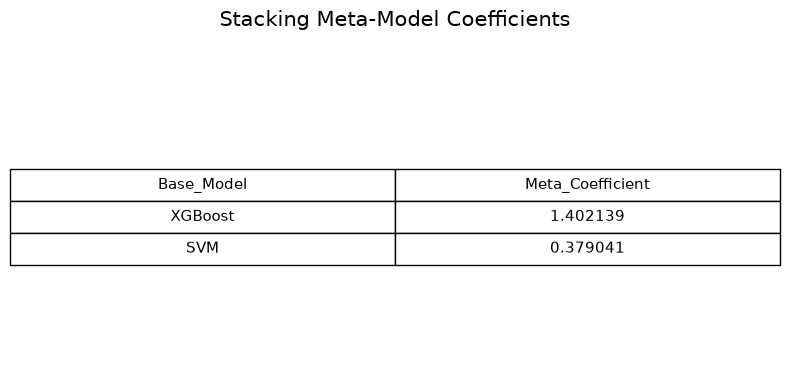

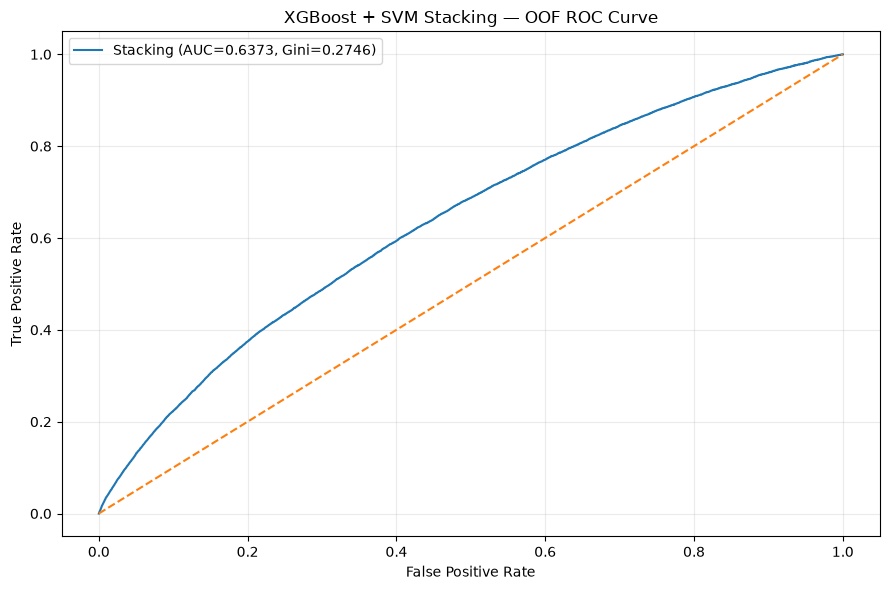

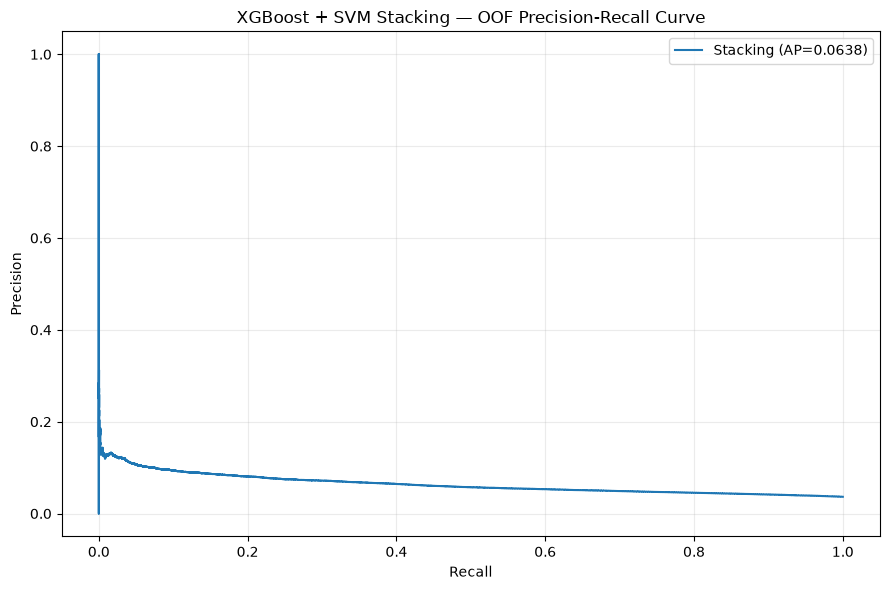


STACKING COMPLETED

✓ XGBoost not retrained
✓ SVM not retrained
✓ Only Logistic Regression meta-model trained
✓ Test set not used


In [20]:
# ============================================================
# ENSEMBLE STEP 2
# STACKING XGBOOST + SVM
# ============================================================
#
# Base models are NOT retrained.
#
# Inputs to the meta-model:
#   1. XGBoost normalized OOF score
#   2. SVM normalized OOF score
#
# Meta-model:
#   Logistic Regression
#
# IMPORTANT:
# The final untouched test set will later provide the definitive
# comparison. This stage evaluates the meta-model using CV on
# the OOF-level features.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import pickle
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)


OUTPUT_DIR = "Ensemble_XGBoost_SVM"


print("=" * 80)

print(
    "XGBOOST + SVM STACKING"
)

print("=" * 80)


# ============================================================
# 1. LOAD BASE OOF SCORES
# ============================================================

base_scores_path = os.path.join(

    OUTPUT_DIR,

    "04_base_and_average_OOF_scores.csv"
)


if not os.path.exists(
    base_scores_path
):

    raise FileNotFoundError(
        "Run Ensemble Step 1 first."
    )


base_scores_df = pd.read_csv(
    base_scores_path
)


y_true = (

    base_scores_df[
        "y_true"
    ]

    .to_numpy()

    .astype(int)
)


X_meta = (

    base_scores_df[
        [
            "xgb_score",
            "svm_score"
        ]
    ]

    .to_numpy()
)


print(
    f"\nMeta-dataset shape: "
    f"{X_meta.shape}"
)


# ============================================================
# 2. LOAD THE SAME 3 SAVED FOLDS
# ============================================================

candidate_directories = [

    "XGBoost_RandomizedSearch_OpenML_42742",

    "XGBoost_RandomizedSearch"
]


folds_path = None


for directory in candidate_directories:

    candidate = os.path.join(

        directory,

        "cv_folds.pkl"
    )


    if os.path.exists(
        candidate
    ):

        folds_path = candidate

        break


if folds_path is None:

    raise FileNotFoundError(
        "Saved CV folds could not be found."
    )


with open(
    folds_path,
    "rb"
) as f:

    cv_splits = pickle.load(f)


if len(cv_splits) != 3:

    raise ValueError(
        f"Expected 3 folds, "
        f"found {len(cv_splits)}."
    )


# ============================================================
# 3. META-MODEL CROSS-VALIDATION
# ============================================================

stacking_oof_score = np.zeros(
    len(y_true),
    dtype=float
)


fold_results = []


for fold_number, (
    train_idx,
    valid_idx
) in enumerate(
    cv_splits,
    start=1
):


    print(
        f"\nMeta-model fold "
        f"{fold_number}/3"
    )


    meta_model = LogisticRegression(

        max_iter=2000,

        random_state=42
    )


    meta_model.fit(

        X_meta[
            train_idx
        ],

        y_true[
            train_idx
        ]
    )


    valid_proba = (

        meta_model

        .predict_proba(

            X_meta[
                valid_idx
            ]
        )

        [:, 1]
    )


    stacking_oof_score[
        valid_idx
    ] = valid_proba


    auc = roc_auc_score(

        y_true[
            valid_idx
        ],

        valid_proba
    )


    gini = (
        2 * auc - 1
    )


    ap = average_precision_score(

        y_true[
            valid_idx
        ],

        valid_proba
    )


    fold_results.append({

        "Fold":
            fold_number,

        "ROC_AUC":
            auc,

        "Gini":
            gini,

        "Average_Precision":
            ap
    })


    print(
        f"ROC-AUC = {auc:.6f}"
    )

    print(
        f"Gini    = {gini:.6f}"
    )

    print(
        f"AP      = {ap:.6f}"
    )


# ============================================================
# 4. GLOBAL STACKING OOF METRICS
# ============================================================

stacking_auc = roc_auc_score(

    y_true,

    stacking_oof_score
)


stacking_gini = (
    2 * stacking_auc - 1
)


stacking_ap = average_precision_score(

    y_true,

    stacking_oof_score
)


print("\n" + "=" * 80)

print(
    "STACKING OOF PERFORMANCE"
)

print("=" * 80)


print(
    f"ROC-AUC = "
    f"{stacking_auc:.6f}"
)

print(
    f"Gini    = "
    f"{stacking_gini:.6f}"
)

print(
    f"AP      = "
    f"{stacking_ap:.6f}"
)


# ============================================================
# 5. TRAIN FINAL META-MODEL
# ============================================================
#
# This DOES NOT evaluate the test set.
#
# The model is simply saved so that later it can combine
# XGBoost and SVM test predictions.
# ============================================================

final_meta_model = LogisticRegression(

    max_iter=2000,

    random_state=42
)


final_meta_model.fit(

    X_meta,

    y_true
)


joblib.dump(

    final_meta_model,

    os.path.join(
        OUTPUT_DIR,
        "06_stacking_meta_model.joblib"
    )
)


# ============================================================
# 6. SAVE STACKING OOF SCORES
# ============================================================

stacking_scores_df = pd.DataFrame({

    "y_true":
        y_true,

    "stacking_score":
        stacking_oof_score
})


stacking_scores_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "07_stacking_OOF_scores.csv"
    ),

    index=False
)


# ============================================================
# 7. SAVE FOLD METRICS
# ============================================================

fold_results_df = pd.DataFrame(
    fold_results
)


fold_results_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "08_stacking_fold_metrics.csv"
    ),

    index=False
)


# ============================================================
# 8. META-MODEL COEFFICIENTS
# ============================================================

coefficients_df = pd.DataFrame({

    "Base_Model": [
        "XGBoost",
        "SVM"
    ],

    "Meta_Coefficient":
        final_meta_model.coef_[0]
})


print(
    "\nStacking coefficients:"
)

display(
    coefficients_df.round(6)
)


fig, ax = plt.subplots(
    figsize=(8, 4)
)

ax.axis("off")


table = ax.table(

    cellText=
        coefficients_df
        .round(6)
        .values,

    colLabels=
        coefficients_df
        .columns,

    cellLoc="center",

    loc="center"
)


table.auto_set_font_size(
    False
)

table.set_fontsize(
    11
)

table.scale(
    1,
    1.8
)


ax.set_title(

    "Stacking Meta-Model Coefficients",

    fontsize=15,

    pad=20
)


plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "09_stacking_coefficients.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ============================================================
# 9. STACKING ROC CURVE
# ============================================================

fpr, tpr, _ = roc_curve(

    y_true,

    stacking_oof_score
)


plt.figure(
    figsize=(9, 6)
)


plt.plot(

    fpr,

    tpr,

    label=(
        f"Stacking "
        f"(AUC={stacking_auc:.4f}, "
        f"Gini={stacking_gini:.4f})"
    )
)


plt.plot(

    [0, 1],

    [0, 1],

    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "XGBoost + SVM Stacking — OOF ROC Curve"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "10_stacking_ROC_curve.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ============================================================
# 10. STACKING PRECISION-RECALL CURVE
# ============================================================

precision_curve, recall_curve, _ = (

    precision_recall_curve(

        y_true,

        stacking_oof_score
    )
)


plt.figure(
    figsize=(9, 6)
)


plt.plot(

    recall_curve,

    precision_curve,

    label=(
        f"Stacking "
        f"(AP={stacking_ap:.4f})"
    )
)


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "XGBoost + SVM Stacking — OOF Precision-Recall Curve"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "11_stacking_precision_recall_curve.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


print("\n" + "=" * 80)

print(
    "STACKING COMPLETED"
)

print("=" * 80)

print(
    "\n✓ XGBoost not retrained"
)

print(
    "✓ SVM not retrained"
)

print(
    "✓ Only Logistic Regression meta-model trained"
)

print(
    "✓ Test set not used"
)

FINAL ENSEMBLE COMPARISON

Comparison:


,Method,ROC_AUC,Gini,Average_Precision,ROC_AUC_Rank,AP_Rank
0,Best Weighted Average,0.637398,0.274795,0.064281,1,2
1,Stacking,0.637304,0.274607,0.063846,2,3
2,XGBoost only,0.636784,0.273567,0.064594,3,1
3,Simple Average (50/50),0.635143,0.270287,0.063436,4,4
4,SVM only,0.623695,0.247390,0.060352,5,5


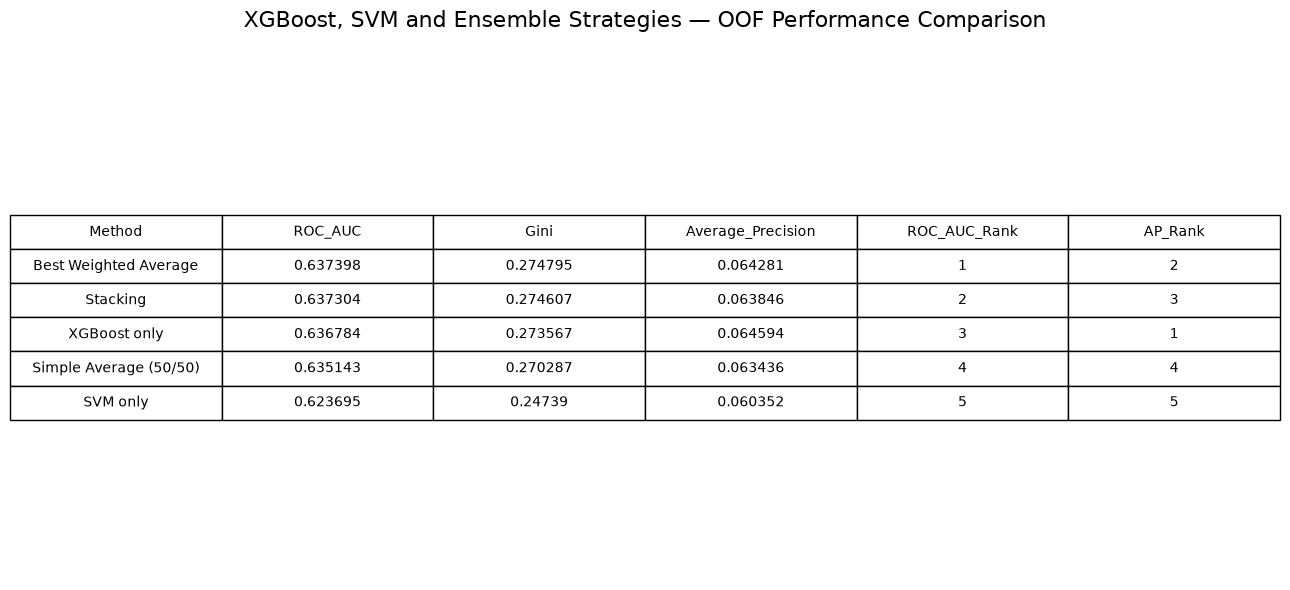

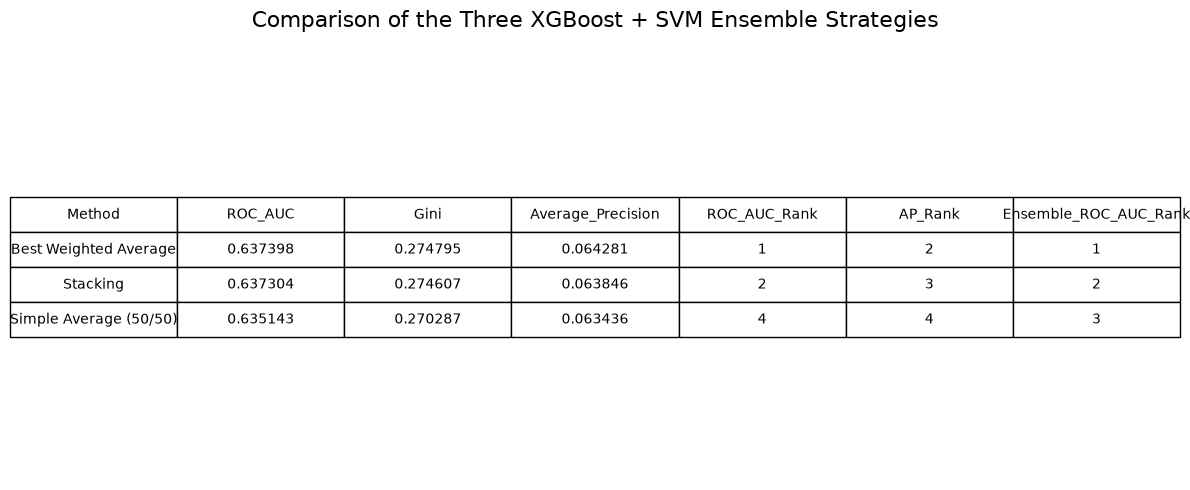

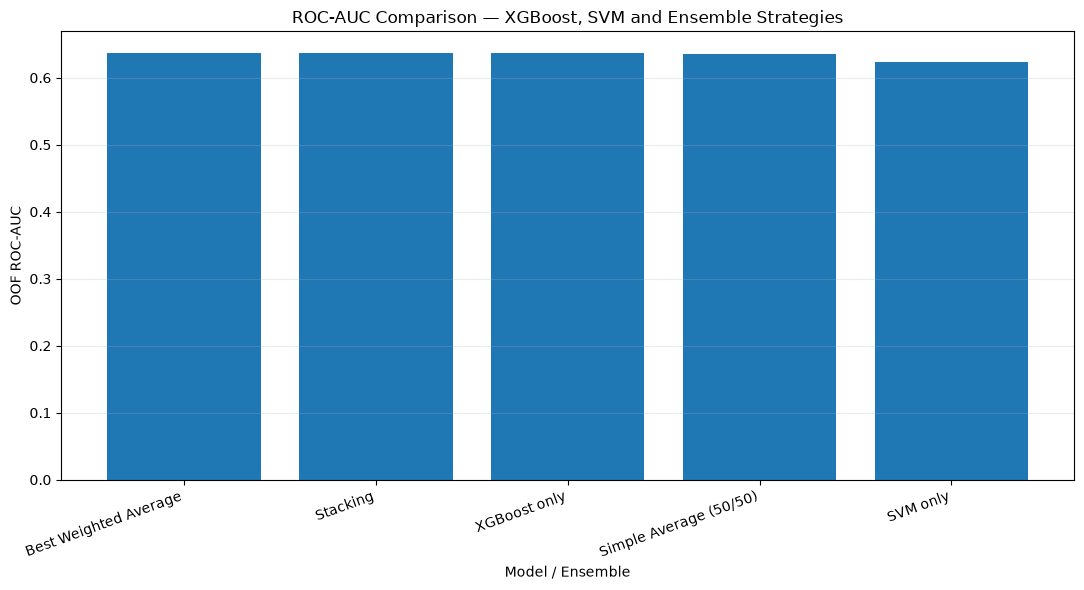

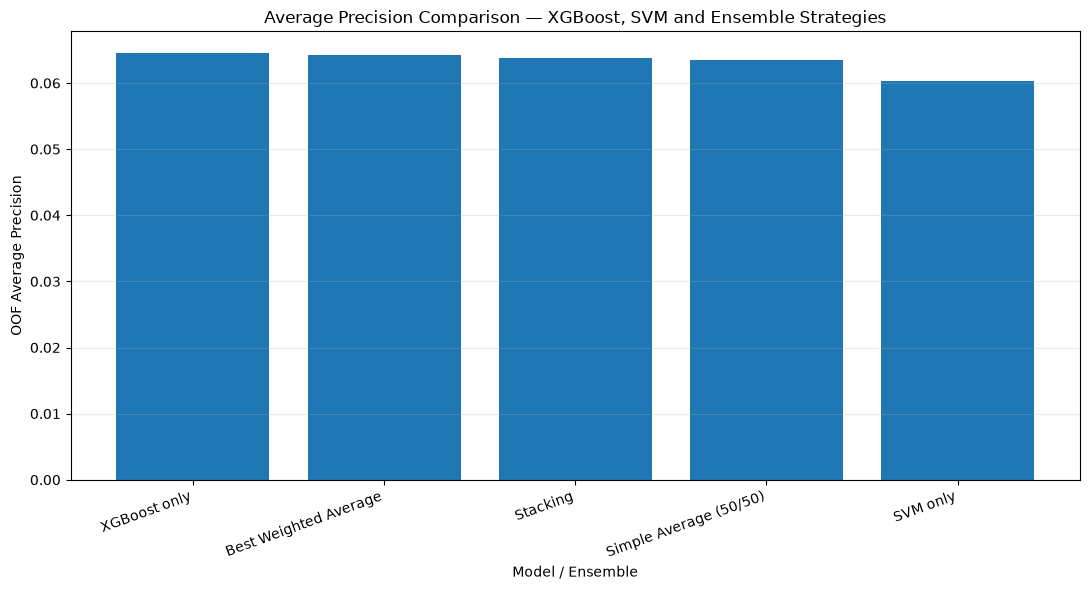


BEST DEVELOPMENT METHOD BY ROC-AUC

Method: Best Weighted Average
ROC-AUC: 0.637398
Gini: 0.274795
Average Precision: 0.064281

FINAL DEVELOPMENT COMPARISON COMPLETED

✓ XGBoost reference included
✓ SVM reference included
✓ Simple Average included
✓ Weighted Average included
✓ Stacking included
✓ ROC-AUC used as primary ranking metric
✓ Gini and Average Precision retained
✓ No test-set evaluation performed

Results saved in:
c:\Users\User\Documents\SoSe26\Advanced Data Analytics\ADA Projekt\Ensemble_XGBoost_SVM


In [21]:
# ============================================================
# ENSEMBLE STEP 3
# FINAL DEVELOPMENT COMPARISON
#
# XGBOOST vs SVM vs
# SIMPLE AVERAGE vs WEIGHTED AVERAGE vs STACKING
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)


OUTPUT_DIR = "Ensemble_XGBoost_SVM"


print("=" * 80)

print(
    "FINAL ENSEMBLE COMPARISON"
)

print("=" * 80)


# ============================================================
# 1. LOAD SCORES
# ============================================================

base_scores_df = pd.read_csv(

    os.path.join(
        OUTPUT_DIR,
        "04_base_and_average_OOF_scores.csv"
    )
)


stacking_scores_df = pd.read_csv(

    os.path.join(
        OUTPUT_DIR,
        "07_stacking_OOF_scores.csv"
    )
)


# ============================================================
# 2. VERIFY LABEL ALIGNMENT
# ============================================================

y_true = (

    base_scores_df[
        "y_true"
    ]

    .to_numpy()

    .astype(int)
)


stack_y = (

    stacking_scores_df[
        "y_true"
    ]

    .to_numpy()

    .astype(int)
)


if not np.array_equal(
    y_true,
    stack_y
):

    raise ValueError(
        "Stacking and averaging labels are not aligned."
    )


# ============================================================
# 3. DEFINE ALL SCORES
# ============================================================

scores = {

    "XGBoost only":
        base_scores_df[
            "xgb_score"
        ].to_numpy(),

    "SVM only":
        base_scores_df[
            "svm_score"
        ].to_numpy(),

    "Simple Average (50/50)":
        base_scores_df[
            "simple_average_score"
        ].to_numpy(),

    "Best Weighted Average":
        base_scores_df[
            "best_weighted_average_score"
        ].to_numpy(),

    "Stacking":
        stacking_scores_df[
            "stacking_score"
        ].to_numpy()
}


# ============================================================
# 4. CALCULATE METRICS
# ============================================================

comparison_results = []


for method, score in scores.items():


    auc = roc_auc_score(

        y_true,

        score
    )


    gini = (
        2 * auc - 1
    )


    ap = average_precision_score(

        y_true,

        score
    )


    comparison_results.append({

        "Method":
            method,

        "ROC_AUC":
            auc,

        "Gini":
            gini,

        "Average_Precision":
            ap
    })


comparison_df = pd.DataFrame(
    comparison_results
)


# ============================================================
# 5. ADD RANKINGS
# ============================================================

comparison_df[
    "ROC_AUC_Rank"
] = (

    comparison_df[
        "ROC_AUC"
    ]

    .rank(
        method="min",
        ascending=False
    )

    .astype(int)
)


comparison_df[
    "AP_Rank"
] = (

    comparison_df[
        "Average_Precision"
    ]

    .rank(
        method="min",
        ascending=False
    )

    .astype(int)
)


comparison_df = (

    comparison_df

    .sort_values(
        "ROC_AUC_Rank"
    )

    .reset_index(
        drop=True
    )
)


print("\nComparison:")

display(
    comparison_df.round(6)
)


# ============================================================
# 6. SAVE COMPLETE TABLE
# ============================================================

comparison_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "12_final_model_and_ensemble_comparison.csv"
    ),

    index=False
)


# ============================================================
# 7. SAVE TABLE AS IMAGE
# ============================================================

fig, ax = plt.subplots(
    figsize=(13, 6)
)

ax.axis("off")


table = ax.table(

    cellText=
        comparison_df
        .round(6)
        .values,

    colLabels=
        comparison_df
        .columns,

    cellLoc="center",

    loc="center"
)


table.auto_set_font_size(
    False
)

table.set_fontsize(
    10
)

table.scale(
    1,
    1.8
)


ax.set_title(

    "XGBoost, SVM and Ensemble Strategies — "
    "OOF Performance Comparison",

    fontsize=16,

    pad=20
)


plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "13_final_model_and_ensemble_comparison.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ============================================================
# 8. ENSEMBLES ONLY TABLE
# ============================================================

ensemble_only = (

    comparison_df[

        comparison_df[
            "Method"
        ].isin(
            [
                "Simple Average (50/50)",
                "Best Weighted Average",
                "Stacking"
            ]
        )
    ]

    .copy()
)


ensemble_only[
    "Ensemble_ROC_AUC_Rank"
] = (

    ensemble_only[
        "ROC_AUC"
    ]

    .rank(
        method="min",
        ascending=False
    )

    .astype(int)
)


ensemble_only = (

    ensemble_only

    .sort_values(
        "Ensemble_ROC_AUC_Rank"
    )
)


fig, ax = plt.subplots(
    figsize=(12, 5)
)

ax.axis("off")


table = ax.table(

    cellText=
        ensemble_only
        .round(6)
        .values,

    colLabels=
        ensemble_only
        .columns,

    cellLoc="center",

    loc="center"
)


table.auto_set_font_size(
    False
)

table.set_fontsize(
    10
)

table.scale(
    1,
    1.9
)


ax.set_title(

    "Comparison of the Three "
    "XGBoost + SVM Ensemble Strategies",

    fontsize=16,

    pad=20
)


plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "14_three_ensemble_strategies.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ============================================================
# 9. ROC-AUC COMPARISON GRAPH
# ============================================================

plot_df = (

    comparison_df

    .sort_values(
        "ROC_AUC",
        ascending=False
    )
)


plt.figure(
    figsize=(11, 6)
)


plt.bar(

    plot_df[
        "Method"
    ],

    plot_df[
        "ROC_AUC"
    ]
)


plt.ylabel(
    "OOF ROC-AUC"
)

plt.xlabel(
    "Model / Ensemble"
)

plt.title(
    "ROC-AUC Comparison — "
    "XGBoost, SVM and Ensemble Strategies"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "15_ROC_AUC_comparison.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ============================================================
# 10. AP COMPARISON GRAPH
# ============================================================

plot_ap_df = (

    comparison_df

    .sort_values(
        "Average_Precision",
        ascending=False
    )
)


plt.figure(
    figsize=(11, 6)
)


plt.bar(

    plot_ap_df[
        "Method"
    ],

    plot_ap_df[
        "Average_Precision"
    ]
)


plt.ylabel(
    "OOF Average Precision"
)

plt.xlabel(
    "Model / Ensemble"
)

plt.title(
    "Average Precision Comparison — "
    "XGBoost, SVM and Ensemble Strategies"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "16_AP_comparison.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ============================================================
# 11. IDENTIFY BEST DEVELOPMENT METHOD
# ============================================================

best_method = (
    comparison_df.iloc[0]
)


print("\n" + "=" * 80)

print(
    "BEST DEVELOPMENT METHOD BY ROC-AUC"
)

print("=" * 80)


print(
    f"\nMethod: "
    f"{best_method['Method']}"
)

print(
    f"ROC-AUC: "
    f"{best_method['ROC_AUC']:.6f}"
)

print(
    f"Gini: "
    f"{best_method['Gini']:.6f}"
)

print(
    f"Average Precision: "
    f"{best_method['Average_Precision']:.6f}"
)


# ============================================================
# 12. SAVE BEST METHOD INFORMATION
# ============================================================

best_method_info = {

    "selection_metric":
        "ROC-AUC",

    "method":
        best_method[
            "Method"
        ],

    "roc_auc":
        float(
            best_method[
                "ROC_AUC"
            ]
        ),

    "gini":
        float(
            best_method[
                "Gini"
            ]
        ),

    "average_precision":
        float(
            best_method[
                "Average_Precision"
            ]
        )
}


with open(

    os.path.join(
        OUTPUT_DIR,
        "17_best_development_method.json"
    ),

    "w"
) as f:

    json.dump(
        best_method_info,
        f,
        indent=4
    )


print("\n" + "=" * 80)

print(
    "FINAL DEVELOPMENT COMPARISON COMPLETED"
)

print("=" * 80)

print(
    "\n✓ XGBoost reference included"
)

print(
    "✓ SVM reference included"
)

print(
    "✓ Simple Average included"
)

print(
    "✓ Weighted Average included"
)

print(
    "✓ Stacking included"
)

print(
    "✓ ROC-AUC used as primary ranking metric"
)

print(
    "✓ Gini and Average Precision retained"
)

print(
    "✓ No test-set evaluation performed"
)

print(
    f"\nResults saved in:\n"
    f"{os.path.abspath(OUTPUT_DIR)}"
)

In [ ]:
import json
from pathlib import Path
import pandas as pd

# Directory where the common comparison notebook reads the results
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ID of Gilles' notebook
NOTEBOOK_ID = "04"

# ============================================================
# SAVE MODEL RESULTS
# Replace the placeholder values below with your actual results
# ============================================================

all_results = [
    {
        "model": "Best Weighted Average SVM+XGBoost",        # e.g. "Logistic Regression", "XGBoost"
        "auc": 0.637398,                # roc_auc_score(y_test, proba)
        "gini": 0.274795,               # 2 * auc - 1
        "ap": None,                   # average_precision_score(y_test, proba)
        "base_rate": 0.0364,          # y_test.mean()
        "params": {
            # Hyperparameters actually used
            # e.g. "max_depth": 4,
            #      "learning_rate": 0.05
            "param_name": "value",
        },
        "notes": "With or without CALC ?",
    },

    # --- Second model: copy/edit this block if needed ---
    {
        "model": "MODEL NAME",
        "auc": 0.0000,
        "gini": 0.0000,
        "ap": None,
        "base_rate": 0.0364,
        "params": {
            "param_name": "value",
        },
        "notes": "With or without CALC ?",
    },
]

# ============================================================
# EXPORT RESULTS
# ============================================================

path = RESULTS_DIR / f"{NOTEBOOK_ID}_models.json"

with open(path, "w") as f:
    json.dump(all_results, f, indent=2)

print(f"Results saved in {path}")

print(
    pd.DataFrame(all_results)[
        ["model", "notes", "gini", "ap"]
    ].to_string(index=False)
)